# Исследование коров для молочного хозяйства

Исследовательский проект проводится для фермера, владельца молочного хозяйства «Вольный луг», который планирует расширить поголовье стада коров и закупить новых буренок у ассоциации пастбищ «ЭкоФерма». 

**Цель проекта:** Разработать модель машинного обучения для оценки удоя коровы и вероятности получения вкусного молока, чтобы помочь фермеру принять обоснованное решение о покупке коров.

Для достижения поставленной цели необходимо решить две задачи:

1. Спрогнозировать возможный удой у коровы (целевой признак `Удой`);
2. Рассчитывать вероятность получить вкусное молоко от коровы (целевой признак `Вкус молока`).

В результате работы моделей, нужно отобрать коров строго соответствующих двум критериям:

- Средний удой за год — не менее 6000 килограммов,
- Молоко должно быть вкусным.

Вероятность покупки коров, не соответствующих указанным критериям, должна быть сведена к минимуму.

Результаты исследования призваны помочь владельцу молочного хозяйства «Вольный луг» в управлении рисками и принятии объективного решения о покупке коров.

**Описание данных для анализа**

Данные для анализа представлены в виде 3 CSV-файлов:

**1. Файл [ferma_main.csv](https://code.s3.yandex.net/datasets/ferma_main.csv)** содержит данные о стаде фермера на текущий момент. Описание таблицы:

- *Параметры корма коровы:*
 - `ЭКЕ (Энергетическая кормовая единица)` — измерение питательности корма коровы;
 - `Сырой протеин` — содержание сырого протеина в корме, в граммах;
 - `СПО (Сахаро-протеиновое соотношение)` — отношение сахара к протеину в корме коровы.
- *Где паслась корова:*
 - `Тип пастбища` — ландшафт лугов, на которых паслась корова.
- *Особенности коровы:*
 - `id` — номер коровы;
 - `Порода` — порода коровы;
 - `Возраст` — бинарный признак (`менее_2_лет`, `более_2_лет`);
 - `Имя Папы` — порода папы коровы.
- *Характеристики молока:*
 - `Жирность` — содержание жиров в молоке, в процентах;
 - `Белок` — содержание белков в молоке, в процентах;
 - `Вкус молока` — оценка вкуса по личным критериям фермера;
 - `Удой` — масса молока, которую корова даёт в год, в килограммах.

**2. Файл [ferma_dad.csv](https://code.s3.yandex.net/datasets/ferma_dad.csv)** хранит имя папы каждой коровы в стаде фермера.

**3. Файл [cow_buy.csv](https://code.s3.yandex.net/datasets/cow_buy.csv)** — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Структура таблицы почти аналогична `ferma_main.csv`, кроме нескольких особенностей:

- `Белок` и `Жирность` молока указаны на момент покупки — когда «ЭкоФерма» давала им свой корм.
- Параметры кормления `ЭКЕ`, `Сырой протеин`, `СПО` отсутствуют. Недавно технологи заказчика пересмотрели параметры корма и планируют их внедрить после расширения стада. Именно новые параметры нужно использовать, когда вы будете применять предсказательные модели к бурёнкам «ЭкоФермы». По новой схеме фермер планирует увеличить средние значения `ЭКЕ`, `Сырой протеин`, `СПО` на 5%.
- `Удой` и `Вкус молока` неизвестны — именно их и предстоит предсказать!


<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Название-колонок" data-toc-modified-id="Название-колонок-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Название колонок</a></span></li><li><span><a href="#Обработка-пропусков" data-toc-modified-id="Обработка-пропусков-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Обработка пропусков</a></span></li><li><span><a href="#Приведение-типов-данных" data-toc-modified-id="Приведение-типов-данных-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Приведение типов данных</a></span></li><li><span><a href="#Обработка-дубликатов" data-toc-modified-id="Обработка-дубликатов-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Обработка дубликатов</a></span><ul class="toc-item"><li><span><a href="#Полные-дубликаты" data-toc-modified-id="Полные-дубликаты-2.4.1"><span class="toc-item-num">2.4.1&nbsp;&nbsp;</span>Полные дубликаты</a></span></li><li><span><a href="#Неявные-дубликаты" data-toc-modified-id="Неявные-дубликаты-2.4.2"><span class="toc-item-num">2.4.2&nbsp;&nbsp;</span>Неявные дубликаты</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Распределение-данных-и-выбросы" data-toc-modified-id="Распределение-данных-и-выбросы-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Распределение данных и выбросы</a></span><ul class="toc-item"><li><span><a href="#Количественные-признаки" data-toc-modified-id="Количественные-признаки-3.1.1"><span class="toc-item-num">3.1.1&nbsp;&nbsp;</span>Количественные признаки</a></span></li><li><span><a href="#Категориальные-признаки" data-toc-modified-id="Категориальные-признаки-3.1.2"><span class="toc-item-num">3.1.2&nbsp;&nbsp;</span>Категориальные признаки</a></span></li></ul></li><li><span><a href="#Вкус-молока" data-toc-modified-id="Вкус-молока-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Вкус молока</a></span><ul class="toc-item"><li><span><a href="#Влияние-особенностей-коровы-на-вкус-молока" data-toc-modified-id="Влияние-особенностей-коровы-на-вкус-молока-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Влияние особенностей коровы на вкус молока</a></span></li><li><span><a href="#Влияние-места-выпаса-на-вкус-молока" data-toc-modified-id="Влияние-места-выпаса-на-вкус-молока-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>Влияние места выпаса на вкус молока</a></span></li><li><span><a href="#Влияние-особенностей-корма-на-вкус-молока" data-toc-modified-id="Влияние-особенностей-корма-на-вкус-молока-3.2.3"><span class="toc-item-num">3.2.3&nbsp;&nbsp;</span>Влияние особенностей корма на вкус молока</a></span></li><li><span><a href="#Влияние-параметров-молока-не-его-вкус" data-toc-modified-id="Влияние-параметров-молока-не-его-вкус-3.2.4"><span class="toc-item-num">3.2.4&nbsp;&nbsp;</span>Влияние параметров молока не его вкус</a></span></li></ul></li><li><span><a href="#Удой-коровы" data-toc-modified-id="Удой-коровы-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Удой коровы</a></span><ul class="toc-item"><li><span><a href="#Влияние-особенностей-коровы-на-удой" data-toc-modified-id="Влияние-особенностей-коровы-на-удой-3.3.1"><span class="toc-item-num">3.3.1&nbsp;&nbsp;</span>Влияние особенностей коровы на удой</a></span></li><li><span><a href="#Влияние-места-выпаса-на-удой" data-toc-modified-id="Влияние-места-выпаса-на-удой-3.3.2"><span class="toc-item-num">3.3.2&nbsp;&nbsp;</span>Влияние места выпаса на удой</a></span></li><li><span><a href="#Влияние-особенностей-корма-на-удой" data-toc-modified-id="Влияние-особенностей-корма-на-удой-3.3.3"><span class="toc-item-num">3.3.3&nbsp;&nbsp;</span>Влияние особенностей корма на удой</a></span></li></ul></li><li><span><a href="#Сочетание-вкуса-и-высокого-удоя" data-toc-modified-id="Сочетание-вкуса-и-высокого-удоя-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Сочетание вкуса и высокого удоя</a></span><ul class="toc-item"><li><span><a href="#Особенности-коровы" data-toc-modified-id="Особенности-коровы-3.4.1"><span class="toc-item-num">3.4.1&nbsp;&nbsp;</span>Особенности коровы</a></span></li><li><span><a href="#Место-выпаса" data-toc-modified-id="Место-выпаса-3.4.2"><span class="toc-item-num">3.4.2&nbsp;&nbsp;</span>Место выпаса</a></span></li><li><span><a href="#Особенности-корма" data-toc-modified-id="Особенности-корма-3.4.3"><span class="toc-item-num">3.4.3&nbsp;&nbsp;</span>Особенности корма</a></span></li><li><span><a href="#Параметры-молока" data-toc-modified-id="Параметры-молока-3.4.4"><span class="toc-item-num">3.4.4&nbsp;&nbsp;</span>Параметры молока</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Корреляционный-анализ" data-toc-modified-id="Корреляционный-анализ-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Корреляционный анализ</a></span><ul class="toc-item"><li><span><a href="#Выводы" data-toc-modified-id="Выводы-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Обучение-модели-линейной-регрессии" data-toc-modified-id="Обучение-модели-линейной-регрессии-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Обучение модели линейной регрессии</a></span><ul class="toc-item"><li><span><a href="#Факторы-влияющие-на-удой" data-toc-modified-id="Факторы-влияющие-на-удой-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Факторы влияющие на удой</a></span></li><li><span><a href="#Подготовка-данных-и-построение-базовой-модели" data-toc-modified-id="Подготовка-данных-и-построение-базовой-модели-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Подготовка данных и построение базовой модели</a></span></li><li><span><a href="#Модели-линейной-регрессии" data-toc-modified-id="Модели-линейной-регрессии-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Модели линейной регрессии</a></span><ul class="toc-item"><li><span><a href="#Модель-1-(базовая):" data-toc-modified-id="Модель-1-(базовая):-5.3.1"><span class="toc-item-num">5.3.1&nbsp;&nbsp;</span>Модель 1 (базовая):</a></span></li><li><span><a href="#Модель-2-(устранение-нелинейности)" data-toc-modified-id="Модель-2-(устранение-нелинейности)-5.3.2"><span class="toc-item-num">5.3.2&nbsp;&nbsp;</span>Модель 2 (устранение нелинейности)</a></span></li><li><span><a href="#Модель-3-(учет-dad_name)" data-toc-modified-id="Модель-3-(учет-dad_name)-5.3.3"><span class="toc-item-num">5.3.3&nbsp;&nbsp;</span>Модель 3 (учет <code>dad_name</code>)</a></span></li><li><span><a href="#Модель-4-(абсолютный-сахар)" data-toc-modified-id="Модель-4-(абсолютный-сахар)-5.3.4"><span class="toc-item-num">5.3.4&nbsp;&nbsp;</span>Модель 4 (абсолютный сахар)</a></span></li><li><span><a href="#Выбор-лучшей-модели" data-toc-modified-id="Выбор-лучшей-модели-5.3.5"><span class="toc-item-num">5.3.5&nbsp;&nbsp;</span>Выбор лучшей модели</a></span></li><li><span><a href="#Прогноз-удоя-коров-&quot;ЭкоФермы&quot;" data-toc-modified-id="Прогноз-удоя-коров-&quot;ЭкоФермы&quot;-5.3.6"><span class="toc-item-num">5.3.6&nbsp;&nbsp;</span>Прогноз удоя коров "ЭкоФермы"</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Обучение-модели-логистической-регрессии" data-toc-modified-id="Обучение-модели-логистической-регрессии-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Обучение модели логистической регрессии</a></span><ul class="toc-item"><li><span><a href="#Факторы-влияющие-на-вкус-молока" data-toc-modified-id="Факторы-влияющие-на-вкус-молока-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Факторы влияющие на вкус молока</a></span></li><li><span><a href="#Подготовка-данных-и-построение-базовой-модели" data-toc-modified-id="Подготовка-данных-и-построение-базовой-модели-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Подготовка данных и построение базовой модели</a></span></li><li><span><a href="#Выбор-лучшей-модели" data-toc-modified-id="Выбор-лучшей-модели-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Выбор лучшей модели</a></span><ul class="toc-item"><li><span><a href="#Модель-1-(базовая)" data-toc-modified-id="Модель-1-(базовая)-6.3.1"><span class="toc-item-num">6.3.1&nbsp;&nbsp;</span>Модель 1 (базовая)</a></span></li><li><span><a href="#Модель-2-(без-выбросов)" data-toc-modified-id="Модель-2-(без-выбросов)-6.3.2"><span class="toc-item-num">6.3.2&nbsp;&nbsp;</span>Модель 2 (без выбросов)</a></span></li></ul></li><li><span><a href="#Выбор-лучшей-модели" data-toc-modified-id="Выбор-лучшей-модели-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>Выбор лучшей модели</a></span></li><li><span><a href="#Прогноз-вкуса-молока-коров-&quot;ЭкоФермы&quot;" data-toc-modified-id="Прогноз-вкуса-молока-коров-&quot;ЭкоФермы&quot;-6.5"><span class="toc-item-num">6.5&nbsp;&nbsp;</span>Прогноз вкуса молока коров "ЭкоФермы"</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-6.6"><span class="toc-item-num">6.6&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Итоговые-выводы" data-toc-modified-id="Итоговые-выводы-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Итоговые выводы</a></span></li></ul></div>

## Загрузка данных

In [1]:
# установка библиотек
!pip install phik -q

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import scipy.stats as st

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix
)

In [3]:
# Загрузка ferma_main
try:
    ferma_main = pd.read_csv('/datasets/ferma_main.csv', sep=';')
except:
    ferma_main = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv', sep=';')

# Загрузка ferma_dad
try:
    ferma_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
except:
    ferma_dad = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv', sep=';')

# Загрузка cow_buy
try:
    cow_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';')
except:
    cow_buy = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv', sep=';')    

In [4]:
# создадим функцию с выводом общей информации о датасете
def df_info(data):
    print(f'1. Первые 5 строк датасета:')
    display(data.head())
          
    print('\n2. Общая информация о датасете:')
    print(data.info())
    
    print('\n3. Статистика по колонкам:')
    display(data.describe(include='all'))
    
    print('\n4. Доля пропусков в колонках:')
    display(pd.DataFrame(round(data.isna().mean()*100, 4).sort_values()).style.background_gradient('coolwarm'))
    
    print('\n5. Количество полных дубликатов:', data.duplicated().sum())
    

In [5]:
# Информация о ferma_main
df_info(ferma_main)

1. Первые 5 строк датасета:


,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null  

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
count,634.000000,634.000000,634,634.000000,634,634,634,634,634,634,634,634
unique,NaN,NaN,55,NaN,12,2,3,3,50,15,2,2
top,NaN,NaN,"14,7",NaN,"0,94",Вис Бик Айдиал,Холмистое,Соверин,"3,72","3,076",вкусно,более_2_лет
freq,NaN,NaN,27,NaN,172,373,356,316,112,103,371,524
mean,317.460568,6187.025237,NaN,1922.682965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,183.096982,1638.401021,NaN,182.392548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,5204.000000,NaN,1660.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,159.250000,5751.750000,NaN,1772.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,317.500000,6130.500000,NaN,1880.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,475.750000,6501.000000,NaN,2058.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



4. Доля пропусков в колонках:


,0
id,0.000000
"Удой, кг",0.000000
ЭКЕ (Энергетическая кормовая единица),0.000000
"Сырой протеин, г",0.000000
СПО (Сахаро-протеиновое соотношение),0.000000
Порода,0.000000
Тип пастбища,0.000000
порода папы_быка,0.000000
"Жирность,%",0.000000
"Белок,%",0.000000



5. Количество полных дубликатов: 5


In [6]:
# Информация о ferma_dad
df_info(ferma_dad)

1. Первые 5 строк датасета:


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB
None

3. Статистика по колонкам:


,id,Имя Папы
count,629.00000,629
unique,NaN,4
top,NaN,Барин
freq,NaN,240
mean,315.00000,NaN
std,181.72094,NaN
min,1.00000,NaN
25%,158.00000,NaN
50%,315.00000,NaN
75%,472.00000,NaN



4. Доля пропусков в колонках:


,0
id,0.000000
Имя Папы,0.000000



5. Количество полных дубликатов: 0


In [7]:
# Информация о cow_buy
df_info(cow_buy)

1. Первые 5 строк датасета:


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB
None

3. Статистика по колонкам:


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
count,20,20,20,20,20,20,20
unique,2,2,2,4,12,12,2
top,РефлешнСоверинг,равнинное,Соверин,Буйный,"3,59","3,074",более_2_лет
freq,11,11,12,8,3,5,15



4. Доля пропусков в колонках:


,0
Порода,0.000000
Тип пастбища,0.000000
порода папы_быка,0.000000
Имя_папы,0.000000
"Текущая_жирность,%",0.000000
"Текущий_уровень_белок,%",0.000000
Возраст,0.000000



5. Количество полных дубликатов: 4


**По итогам загрузки и ознакомления с исходными данными можно сделать следующие выводы:**

- Явные пропуски в данных отсутствуют.
- Название колонок необходимо привести в snake_case для удобства.
- В качестве разделителя в числовых данных используется запятая, а не точка. Колонки с числовой информацией распознаются как строки (объекты).
- Нечисловые данные лучше привести к нижнему регистру для единообразия. Также проверим наличие пробелов в начале и конце слов
- В данных есть полные дубликаты, их нужно будет обработать

##  Предобработка данных

### Название колонок

Приведем название колонок в удобный для работы вид ("snake_case").

In [8]:
# названия колонок ferma_main
ferma_main.columns

Index(['id', 'Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)',
       'Сырой протеин, г', 'СПО (Сахаро-протеиновое соотношение)', 'Порода',
       'Тип пастбища', 'порода папы_быка', 'Жирность,%', 'Белок,%',
       'Вкус молока', 'Возраст'],
      dtype='object')

In [9]:
 # замена названий колонок
ferma_main = ferma_main.rename(columns={
    'Удой, кг': 'milk_yield_kg',
    'ЭКЕ (Энергетическая кормовая единица)': 'energy_feed_unit',
    'Сырой протеин, г': 'crude_protein_g',
    'СПО (Сахаро-протеиновое соотношение)': 'sugar_protein_ratio',
    'Порода': 'breed',
    'Тип пастбища': 'pasture_type',
    'порода папы_быка': 'dad_breed',
    'Жирность,%': 'fat_percentage',
    'Белок,%': 'protein_percentage',
    'Вкус молока': 'milk_flavor',
    'Возраст': 'age'
    }
)
# новое название колонок
ferma_main.columns

Index(['id', 'milk_yield_kg', 'energy_feed_unit', 'crude_protein_g',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'dad_breed',
       'fat_percentage', 'protein_percentage', 'milk_flavor', 'age'],
      dtype='object')

In [10]:
ferma_main['dad_breed'].unique()

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

In [11]:
# названия колонок ferma_dad
ferma_dad.columns

Index(['id', 'Имя Папы'], dtype='object')

In [12]:
# замена названий колонок
ferma_dad = ferma_dad.rename(columns={
    'Имя Папы': 'dad_name'
    }
)
# новое название колонок
ferma_dad.columns

Index(['id', 'dad_name'], dtype='object')

In [13]:
# названия колонок cow_buy
cow_buy.columns

Index(['Порода', 'Тип пастбища', 'порода папы_быка', 'Имя_папы',
       'Текущая_жирность,%', 'Текущий_уровень_белок,%', 'Возраст'],
      dtype='object')

In [14]:
# замена названий колонок
cow_buy = cow_buy.rename(columns={
    'Порода': 'breed',
    'Тип пастбища': 'pasture_type',
    'порода папы_быка': 'dad_breed',
    'Имя_папы': 'dad_name',
    'Текущая_жирность,%': 'current_fat_percentage',
    'Текущий_уровень_белок,%': 'current_protein_percentage',
    'Возраст': 'age'
    }
)
# новое название колонок
cow_buy.columns

Index(['breed', 'pasture_type', 'dad_breed', 'dad_name',
       'current_fat_percentage', 'current_protein_percentage', 'age'],
      dtype='object')

### Обработка пропусков

Явных пропусков в данных не обнаружено.

### Приведение типов данных

**Типы данных в `ferma_main`:**

In [15]:
ferma_main.dtypes

id                      int64
milk_yield_kg           int64
energy_feed_unit       object
crude_protein_g         int64
sugar_protein_ratio    object
breed                  object
pasture_type           object
dad_breed              object
fat_percentage         object
protein_percentage     object
milk_flavor            object
age                    object
dtype: object

In [16]:
ferma_main.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


- `energy_feed_unit`, `sugar_protein_ratio`, `fat_percentage`, `protein_percentage` необходимо привести к типу float;
- для корректной обработки строковых данных приведем их все к нижнему регистру и избавимся от возможных пробелов и прозрачных символов на концах строк методом strip

In [17]:
# функция для изменения запятых на точки и преобразования данных в тип float
def replace_comma_and_convert_to_float(df, columns):
    for column in columns:
        df[column] = df[column].apply(lambda x: float(str(x).replace(',', '.')))
    return df

In [18]:
# заменим запятые на точки и прообразуем тип данных в float
replace_comma_and_convert_to_float(ferma_main, ['energy_feed_unit', 'sugar_protein_ratio', 'fat_percentage', 'protein_percentage'])

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
629,627,5970,14.4,1837,0.880,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.880,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.880,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.880,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет


In [19]:
# функция для приведения строк к нижнему регистру и очиске концов от пробелов
def clean_strings(df):
    for column in df.columns:
        if df[column].dtype == 'object':
            df[column] = df[column].str.lower().str.strip()
    return df

In [20]:
clean_strings(ferma_main)

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
0,1,5863,14.2,1743,0.890,вис бик айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,вис бик айдиал,равнинные,соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,рефлешнсоверинг,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,вис бик айдиал,равнинные,соверин,3.73,3.073,вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
629,627,5970,14.4,1837,0.880,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.880,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.880,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.880,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет


In [21]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   634 non-null    int64  
 1   milk_yield_kg        634 non-null    int64  
 2   energy_feed_unit     634 non-null    float64
 3   crude_protein_g      634 non-null    int64  
 4   sugar_protein_ratio  634 non-null    float64
 5   breed                634 non-null    object 
 6   pasture_type         634 non-null    object 
 7   dad_breed            634 non-null    object 
 8   fat_percentage       634 non-null    float64
 9   protein_percentage   634 non-null    float64
 10  milk_flavor          634 non-null    object 
 11  age                  634 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.6+ KB


**Типы данных в `ferma_dad`:**

In [22]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   dad_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [23]:
ferma_dad.head()

,id,dad_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


- приведем значения колонки `dad_name` к нижнему регистру и очистим от возможных пробелов на концах.
- типы данных менять не требуется

In [24]:
clean_strings(ferma_dad)

,id,dad_name
0,1,буйный
1,2,соловчик
2,3,барин
3,4,буйный
4,5,барин
...,...,...
624,625,буйный
625,626,барин
626,627,барин
627,628,барин


In [25]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   dad_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


**Типы данных в `cow_buy`:**

In [26]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   breed                       20 non-null     object
 1   pasture_type                20 non-null     object
 2   dad_breed                   20 non-null     object
 3   dad_name                    20 non-null     object
 4   current_fat_percentage      20 non-null     object
 5   current_protein_percentage  20 non-null     object
 6   age                         20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


In [27]:
cow_buy.head()

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


- `current_fat_percentage`,	`current_protein_percentage` приведем к типу float;
-остальные колонки приведем к нижнему регистру и очистим возможные проблы на концах.

In [28]:
replace_comma_and_convert_to_float(cow_buy, ['current_fat_percentage', 'current_protein_percentage'])

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет


In [29]:
clean_strings(cow_buy)

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет
6,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
7,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет
8,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
9,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет


In [30]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   breed                       20 non-null     object 
 1   pasture_type                20 non-null     object 
 2   dad_breed                   20 non-null     object 
 3   dad_name                    20 non-null     object 
 4   current_fat_percentage      20 non-null     float64
 5   current_protein_percentage  20 non-null     float64
 6   age                         20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


### Обработка дубликатов

#### Полные дубликаты

При первоначальном знакомстве с данными были обнаружены полные дубликаты:
- в таблице `ferma_main` (5 штук);
- в таблице `cow_buy` (4 штуки).

In [31]:
ferma_main[ferma_main.duplicated()]

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
629,627,5970,14.4,1837,0.88,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.88,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.88,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.88,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет
633,627,5970,14.4,1837,0.88,рефлешнсоверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет


In [32]:
cow_buy[cow_buy.duplicated()]

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age
6,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
8,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
14,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
19,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет


In [33]:
# удалим полные дубликаты
ferma_main = ferma_main.drop_duplicates().reset_index(drop=True)
cow_buy = cow_buy.drop_duplicates().reset_index(drop=True)

Возможно, что коровы из таблице коров на покупку (cow_buy) в реальности не являются повторами и представляют собой реальных коров с одинаковыми свойствами (количество признаков не велико). Эта таблица не участвует в обучении моделей машинного обучения, поэтому удаление дубликатов не должно повлиять на результаты проводимого исследования. Однако удалив повторы, в новой таблице будем говорить уже не об отдельных коровах, а о уникальных типах (категориях) коров на покупку, обладающих определенными характеристиками. И будем делать наши дальнейшие предсказания и исследования с учетом этого докупщения.

In [34]:
# проверка полных буликатов
print(ferma_main.duplicated().sum())
print(ferma_dad.duplicated().sum())
print(cow_buy.duplicated().sum())

0
0
0


#### Неявные дубликаты

**Дубликаты в ferma_main:**

In [35]:
ferma_main.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
0,1,5863,14.2,1743,0.890,вис бик айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,вис бик айдиал,равнинные,соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,рефлешнсоверинг,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,вис бик айдиал,равнинные,соверин,3.73,3.073,вкусно,менее_2_лет


Каждая запись в таблице `ferma_head` представляет собой отдельную корову в стаде фермера. Поэтому не должно быть коров с одинаковыми `id`, т.к. это ее уникальный идентификатор.

In [36]:
ferma_main['id'].duplicated().sum()

0

Кроме `id` одних и тех же коров можно определить и по другим признакам (особенностям коровы, параметрам ее молока и месту где она паслась).    

In [37]:
# посмотрим повторы по всем колонкам кроме id
ferma_main.drop('id', axis=1).duplicated().sum()

0

In [38]:
# посмотрим повторы по всем колонкам кроме id и параметров корма
ferma_main.drop(['id', 'energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio'], axis=1).duplicated().sum()

0

Посмотрим наличие неявных дубликатов в других колонках с нечисловыми данными.

In [39]:
ferma_main['breed'].value_counts()

вис бик айдиал     373
рефлешнсоверинг    256
Name: breed, dtype: int64

In [40]:
ferma_main['pasture_type'].value_counts()

холмистое    351
равнинное    253
равнинные     25
Name: pasture_type, dtype: int64

In [41]:
# В колонке `pasture_type` есть неявные повторы. Заменим "равнинные" на "равнинное"
ferma_main['pasture_type'] = ferma_main['pasture_type'].replace('равнинные', 'равнинное')

In [42]:
# проверка замены
ferma_main['pasture_type'].value_counts()

холмистое    351
равнинное    278
Name: pasture_type, dtype: int64

In [43]:
ferma_main['dad_breed'].value_counts()

соверин    311
айдиал     240
айдиалл     78
Name: dad_breed, dtype: int64

In [44]:
# в колонке `dad_breed` есть неявные повторы. Выполним замену
ferma_main['dad_breed'] = ferma_main['dad_breed'].replace('айдиалл', 'айдиал')

In [45]:
# проверка замены
ferma_main['pasture_type'].value_counts()

холмистое    351
равнинное    278
Name: pasture_type, dtype: int64

In [46]:
ferma_main['milk_flavor'].value_counts()

вкусно       371
не вкусно    258
Name: milk_flavor, dtype: int64

In [47]:
ferma_main['age'].value_counts()

более_2_лет    519
менее_2_лет    110
Name: age, dtype: int64

**Дубликаты в ferma_dad:**

In [48]:
ferma_dad.head()

,id,dad_name
0,1,буйный
1,2,соловчик
2,3,барин
3,4,буйный
4,5,барин


In [49]:
ferma_dad['id'].duplicated().sum()

0

In [50]:
ferma_dad['dad_name'].value_counts()

барин       240
буйный      215
соловчик    110
геркулес     64
Name: dad_name, dtype: int64

**Дубликаты в cow_buy:**

In [51]:
cow_buy.head()

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет


In [52]:
cow_buy['breed'].value_counts()

вис бик айдиал     8
рефлешнсоверинг    8
Name: breed, dtype: int64

In [53]:
cow_buy['pasture_type'].value_counts()

холмистое    8
равнинное    8
Name: pasture_type, dtype: int64

In [54]:
cow_buy['dad_breed'].value_counts()

соверин    10
айдиал      6
Name: dad_breed, dtype: int64

### Выводы

В ходе предобработки данных было сделано следующее:

**1. Названия колонок:**

Колонки были переименованы и приведены к нижнему регистру (snake_case) для дальнейшей работы с данными следующим образом (старое название указано в скобках):

- Таблица `ferma_main`:
 - `id` ("id"): Уникальный идентификатор (номер) коровы.
 - `milk_yield_kg` ("Удой, кг"): Масса молока, которую корова даёт в год, в килограммах..
 - `energy_feed_unit` ("ЭКЕ (Энергетическая кормовая единица)"):  Измерение питательности корма коровы.
 - `crude_protein_g` ("Сырой протеин, г"): Содержание сырого протеина в корме коровы, в граммах.
 - `sugar_protein_ratio` ("СПО (Сахаро-протеиновое соотношение)"): Отношение сахара к протеину в корме коровы.
 - `breed` ("Порода"): Порода коровы.
 - `pasture_type` ("Тип пастбища"): Ландшафт лугов, на которых паслась корова.
 - `dad_breed` ("порода папы_быка"): Порода папы коровы.
 - `fat_percentage` ("Жирность,%"): Содержание жиров в молоке, в процентах.
 - `protein_percentage` ("Белок,%"): Содержание белков в молоке, в процентах.
 - `milk_flavor` ("Вкус молока"): Оценка вкуса молока по личным критериям фермера.
 - `age` ("Возраст"): Возраст коровы (бинарный признак: "менее\_2\_лет", "более\_2\_лет").

- Таблица `ferma_dad`:

 - `id` ("id"): Уникальный идентификатор (номер) коровы.
 - `dad_name` ("Имя Папы"): Имя папы коровы.

- Таблица `cow_buy`:

 - `breed` ("Порода"): Порода коровы.
 - `pasture_type` ("Тип пастбища"): Ландшафт лугов, на которых паслась корова.
 - `dad_breed` ("порода папы_быка"): Порода папы коровы.
 - `dad_name` ("Имя_папы"): Имя папы коровы.
 - `current_fat_percentage` ("Текущая_жирность,%"): Текущее содержание жиров в молоке, в процентах.
 - `current_protein_percentage` ("Текущий_уровень_белок,%"): Текущее содержание белков в молоке, в процентах.
 - `age` ("Возраст"): Возраст коровы (бинарный признак: "менее\_2\_лет", "более\_2\_лет").
 
**2. Обработка пропусков:**

Явных пропусков в данных не обнаружено.

**3. Приведение типов данных:**

- Колонки с числовой информацией `energy_feed_unit`, `sugar_protein_ratio`, `fat_percentage` (`current_fat_percentage)`, `protein_percentage` (`current_protein_percentage`) были преобразованы в тип данных с плавающей запятой `float`;
- Нечисловые данные были приведены к нижнему регистру для обеспечения единообразия. Также была проведена проверка наличия пробелов в начале и конце слов.

**4. Обработка дубликатов:**

- Полные дубликаты были обнаружены и удалены в таблицах:
 - `ferma_main`: 5 записей;
 - `cow_buy`: 4 записи.
- Неявные дубликаты были обнаружены в колонках:
 - `pasture_type`: "равнинные" и "равнинное" (оставлено только "равнинное");
 - `dad_breed`: "айдиалл" и "айдиал" (оставлено только "айдиал").
 - другие неявные дубликаты обнаружены не были (проверена уникальность значений `id`, различные другие комбинации колонок с параметрами коров).

## Исследовательский анализ данных

### Распределение данных и выбросы

In [55]:
# посмотрим статистику по таблицу ferma_main
ferma_main.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,629.0,NaN,NaN,NaN,315.0,181.72094,1.0,158.0,315.0,472.0,629.0
milk_yield_kg,629.0,NaN,NaN,NaN,6188.750397,1644.795489,5204.0,5751.0,6133.0,6501.0,45616.0
energy_feed_unit,629.0,NaN,NaN,NaN,14.543879,1.306408,10.9,13.5,14.7,15.6,16.8
crude_protein_g,629.0,NaN,NaN,NaN,1923.36407,182.956251,1660.0,1771.0,1888.0,2062.0,2349.0
sugar_protein_ratio,629.0,NaN,NaN,NaN,0.913116,0.032203,0.84,0.89,0.93,0.94,0.96
breed,629,2,вис бик айдиал,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pasture_type,629,2,холмистое,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dad_breed,629,2,айдиал,318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fat_percentage,629.0,NaN,NaN,NaN,3.603657,0.168656,2.99,3.59,3.65,3.72,3.75
protein_percentage,629.0,NaN,NaN,NaN,3.075671,0.002549,3.069,3.074,3.076,3.077,3.085


In [56]:
# посмотрим статистику по таблицу ferma_dad
ferma_dad.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,629.0,NaN,NaN,NaN,315.0,181.72094,1.0,158.0,315.0,472.0,629.0
dad_name,629,4,барин,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Типичная корова в хозястве "Вольный луг" характеризуется следующими параметрами:
- Средний удой (`milk_yield_kg`) составляет около 6189 кг молока в год.
- Средняя энергетическая кормовая единица (`energy_feed_unit`) равна примерно 14.54.
- Среднее содержание сырого протеина в корме коровы (`crude_protein_g`) составляет около 1923 г.
- СПО (`sugar_protein_ratio`) в среднем составляет около 0.91.
- Типичная порода коровы (`breed`) в хозяйстве - "вис бик айдиал".
- Чаще коровы пасутся на холмистых лугах (`pasture_type`).
- Самцы породы "Айдиал" чаще всего являются отцами коров (`dad_breed`).
- Часто встречающимся именем отцов коров в хозяйстве является "барин".
- Средняя жирность молока (`fat_percentage`) составляет около 3.60%.
- Содержание белка в молоке (`protein_percentage`) составляет около 3.08%.
- Вкус молока (`milk_flavor`) чаще оценивается как "вкусно".
- Большинство коров (`age`) в хозяйстве старше 2 лет.

In [57]:
# посмотрим статистику по таблицу cow_buy
cow_buy.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
breed,16,2,вис бик айдиал,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pasture_type,16,2,холмистое,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dad_breed,16,2,соверин,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dad_name,16,4,буйный,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_fat_percentage,16.0,NaN,NaN,NaN,3.571875,0.14162,3.34,3.415,3.585,3.6925,3.77
current_protein_percentage,16.0,NaN,NaN,NaN,3.06825,0.011264,3.046,3.0595,3.0735,3.07675,3.081
age,16,2,более_2_лет,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Типичная корова в ассоциации пастбищ "ЭкоФерма" характеризуется следующими параметрами:

 - Порода коровы, которая чаще всего встречается на пастбище "ЭкоФерма" - "вис бик айдиал".
 - Коровы "ЭкоФермы" чаще всего пасутся на холмистых лугах.
 - Большинство коров на пастбище "ЭкоФерма" имеют возраст "более 2 лет".
 - Среднее значение жирности молока у коров на пастбище "ЭкоФерма" составляет около 3.57%. (практически такое же как на ферме - 3.60%)
 - Среднее значение содержания белков в молоке около 3.07% (практически такое же как на ферме - 3.08%).
 - Порода папы коровы, которая чаще всего встречается на пастбище - "соверин" (на ферме - "айдиал")
 - Самое часто встречаемое имя папы коровы на пастбище - "буйный" (на ферме - "барин").
 
Характеристики типичной коровы в хозяйстве "Вольный луг" практически совпадают с характеристиками типичной коровы в ассоциации пастбищ "ЭкоФерма" (за исключением типичной породы и имени папы коровы).

<u>Дополнительные наблюдения:</u>

- в таблице ferma_main заметно аномально высокое максимальное значение в колонке 'milk_yield_kg' по сравнению с другими значениями, возможно в данной колонке имеются выбросы.
- границы, в которых распределены числовые значения в остальных колонках, не такие широкие, стандартное отклонение небольшое. Данные выглядят адекватно.
- нечисловые колонки в основном содержат по 2 уникальных значения (категории), для визуализации признаков будет удобно использовать piechart для отображения доли каждого признака в выборке в дополнении в barchart. Колонка `dad_name` в обеих таблицах содержит 4 уникальных значения.

#### Количественные признаки

**Таблица `ferma_main`:**

In [58]:
# Функция для построения диаграммы размаха (boxplot) для числовых столбцов DataFrame.
def plot_box_chart(data, x_label=None, y_label=None, title='Диаграмма размаха по колонке', hue=None, palette='crest'):
    # Проверяем, является ли входной `data` объектом pandas Series, и если да, преобразуем его в DataFrame
    if isinstance(data, pd.Series):
        data = pd.DataFrame(data)
        
    # Выбираем только числовые столбцы из DataFrame
    numerical_cols = data.select_dtypes(include=['int', 'float']).columns
    num_plots = len(numerical_cols)
    
    # Проверяем количество числовых столбцов для настройки размещения графиков
    if num_plots == 1:
        # Создаем фигуру и оси для одного графика
        fig, axes = plt.subplots(1, 1, figsize=(6, 2))
        axes = [axes]  # Преобразуем в список с одним элементом для одиночного графика
    else:
        # Создаем фигуру и оси для нескольких графиков
        fig, axes = plt.subplots(num_plots, 1, figsize=(6, 2*num_plots))
    
    # Для каждого числового столбца строим boxplot
    for i, col in enumerate(numerical_cols):
        # Строим boxplot
        sns.boxplot(x=data[col], ax=axes[i], palette=palette)
        axes[i].set_xlabel(x_label)  # Устанавливаем подпись по оси X
        axes[i].set_title(f'{title}: {col}')  # Устанавливаем заголовок

    plt.tight_layout()
    plt.show()

In [59]:
# Функция для построения гистограммы (histplot) для числовых столбцов DataFrame.
def plot_hist_chart(data, xlabel='Значение признака', ylabel='Частота', title=None, palette='crest', bins='auto'):
    # Проверяем, является ли входной `data` объектом pandas Series, и если да, преобразуем его в DataFrame
    if isinstance(data, pd.Series):
        data = pd.DataFrame(data)

    # Выбираем только числовые столбцы из DataFrame
    numerical_cols = data.select_dtypes(include=['int', 'float']).columns
    num_plots = len(numerical_cols)

    # Проверяем количество числовых столбцов для настройки размещения графиков
    if num_plots == 1:
        # Создаем фигуру и оси для одного графика
        fig, axes = plt.subplots(1, 1, figsize=(6, 2))
        axes = [axes]  # Преобразуем в список с одним элементом для одиночного графика
    else:
        # Создаем фигуру и оси для нескольких графиков
        fig, axes = plt.subplots(num_plots, 1, figsize=(6, 2*num_plots))

    # Для каждого числового столбца строим гистограмму
    for i, col in enumerate(numerical_cols):
        sns.histplot(x=data[col], bins=bins, palette=palette, ax=axes[i])
        axes[i].set_xlabel(xlabel)  # Устанавливаем подпись по оси X
        axes[i].set_ylabel(ylabel)  # Устанавливаем подпись по оси Y
        axes[i].set_title(f'Распределение значений в колонке: {col}')  # Устанавливаем заголовок

    plt.tight_layout()  # Автоматически настраиваем расположение графиков для лучшего визуального отображения
    plt.show()  # Отображаем графики

In [60]:
# Функция для одновременного построения диаграммы размаха (boxplot) и гистограммы для числовых признаков из DataFrame.
def plot_box_hist_chart(data, xlabel='Значение признака', ylabel='Частота', title=None, palette='crest', bins='auto'):
    # Проверяем, является ли входной `data` объектом pandas Series, и если да, преобразуем его в DataFrame
    if isinstance(data, pd.Series):
        data = pd.DataFrame(data)

    # Выбираем только числовые столбцы из DataFrame
    numerical_cols = data.select_dtypes(include=['int', 'float']).columns
    num_plots = len(numerical_cols)

    # Проверяем количество числовых столбцов для настройки размещения графиков
    if num_plots == 1:
        # Создаем фигуру и оси для одного графика
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        axes = [axes]  # Преобразуем в список с одним элементом для одиночного графика
    else:
        # Создаем фигуру и оси для нескольких графиков
        fig, axes = plt.subplots(num_plots, 2, figsize=(12, 3*num_plots))

    # Для каждого числового столбца строим boxplot и гистограмму
    for i, col in enumerate(numerical_cols):
        # Строим boxplot
        sns.boxplot(x=data[col], ax=axes[i][0], palette=palette)
        axes[i][0].set_xlabel(xlabel)  # Устанавливаем подпись по оси X
        axes[i][0].set_title(f'Диаграмма размаха по колонке: {col}')  # Устанавливаем заголовок

        # Строим гистограмму
        sns.histplot(x=data[col], bins=bins, palette=palette, ax=axes[i][1])
        axes[i][1].set_xlabel(xlabel)  # Устанавливаем подпись по оси X
        axes[i][1].set_ylabel(ylabel)  # Устанавливаем подпись по оси Y
        axes[i][1].set_title(f'Распределение значений в колонке: {col}')  # Устанавливаем заголовок

    plt.tight_layout()  # Автоматически настраиваем расположение графиков для лучшего визуального отображения
    plt.show()  # Отображаем графики

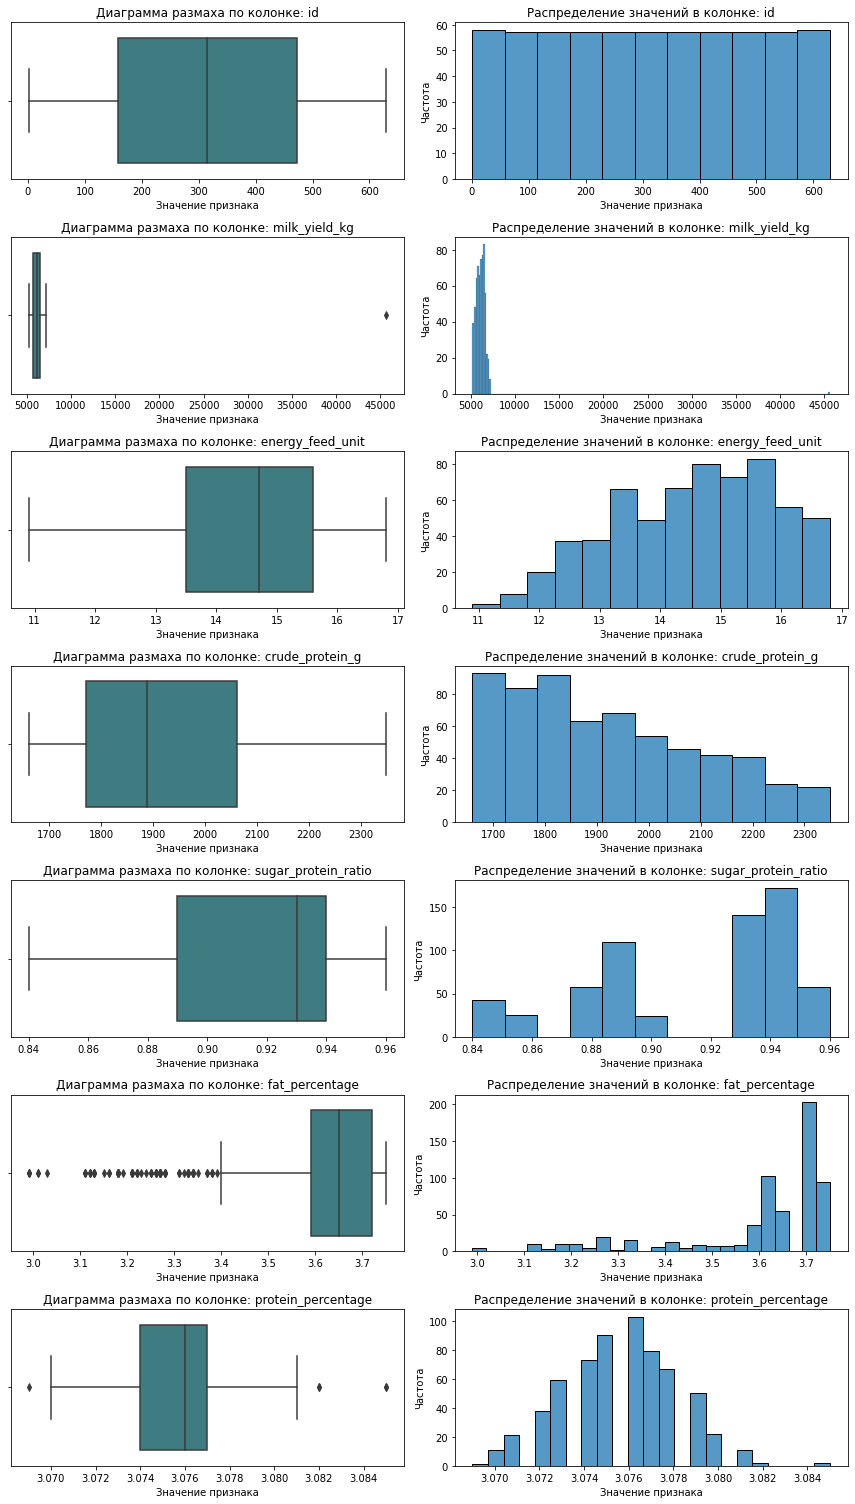

In [61]:
plot_box_hist_chart(ferma_main)


*1. Выбросы:* 

На диаграммах размаха заметны выбросы в следующих колонках:
- `milk_yield_kg` - одно значение существенное выбивается в большую сторону.
- `fat_percentage` - большое количество выбросов в левой части графика.
- `protein_percentage` - небольшие выбросы как слева, так и справа.

*2. Распределение значений:*

- распределение величины `milk_yield_kg` на графике ненаглядно, т.к. выбросы уменьшили масштаб графика. Посмотрим на него позже после обработки аномальных значений.
- распеределение данных в колонке `energy_feed_unit` близко к нормальному, однако правый хвост распределения обрезан. Вероятно, предпочтение отдается кормам со средним и низким ЭКЕ.
- распределение значений `crude_protein_g` тоже близко к нормально, но в данном случае отсутствует левая часть колокола распределения. Вероятно, в хозяйстве используются корма со средним и высоким содержанием сырого протеина
- на графике распределения `sugar_protein_ration` заметны 3 пика, отделенные друг от друга. Возможно такой вид распределения объясняется различными видами корма, который закупается хозяйством (например, это могут быть 3 разных вида корма с разным отношением сахара к протеину в них, и их распределения накладываются на один график).
- на графике `fat_percentage` распределение ассиметрично (смещено вправо), наблюдается длинный левый хвост.  При это разброс по процентам жирности небольшой (3-3.7%). В правой части графика заметны 2 пика в районе 3.6% и на 3.7%.
- значения `protein_percentage` распределены нормально. Есть небольшие выбросы в районе хвостов распределения.

Посмотрим на колонки с выбросами (`milk_yield_kg`, `fat_percentage`, `protein_percentage`) подробней.

In [62]:
# Функция для нахождения границы диаграммы размаха (границы выбросов)
def wiskers(df, columns):
    result = []

    if isinstance(columns, str):
        columns = [columns]

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_whisker = df[column][df[column] >= (Q1 - 1.5 * IQR)].min()
        upper_whisker = df[column][df[column] <= (Q3 + 1.5 * IQR)].max()

        result.append((lower_whisker, upper_whisker))

    return result

In [63]:
# Функция для вывода информации о выбросах в датафрейме
def find_outliers(df, columns, bins='auto'):
    outliers = pd.DataFrame()  # Создаем пустой DataFrame для хранения выбросов

    if isinstance(columns, str):
        columns = [columns]  # Преобразование строки в список, если передано одно значение

    wiskers_values = wiskers(df, columns)

    total_outliers = 0
    total_records = len(df)

    for i, column in enumerate(columns):
        lower_whisker, upper_whisker = wiskers_values[i]
        outliers_df = df[(df[column] < lower_whisker) | (df[column] > upper_whisker)]
        outliers = pd.concat([outliers, outliers_df])  # Объединяем выбросы в один DataFrame
        outliers = outliers.drop_duplicates('id')
        
        print(f"Границы диаграммы размаха по колонке '{column}':")
        print(f"Lower Whisker: {lower_whisker}")
        print(f"Upper Whisker: {upper_whisker}")

        total_outliers += len(outliers_df)

        # Рисуем диаграмму размаха и гистограмму для текущей колонки
        plot_box_hist_chart(df[column], bins=bins)

    outliers_fraction = total_outliers / total_records
    print(f"Доля выбросов: {outliers_fraction:.2%}")

    return outliers

Границы диаграммы размаха по колонке 'milk_yield_kg':
Lower Whisker: 5204
Upper Whisker: 7222


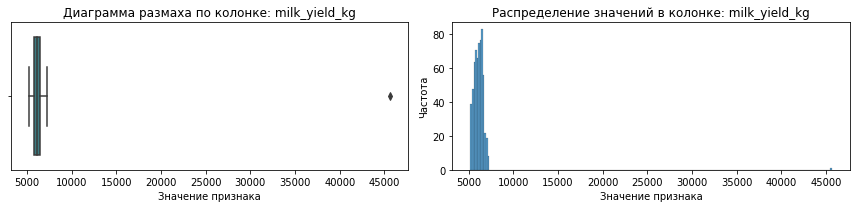

Доля выбросов: 0.16%


,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
16,17,45616,11.5,1675,0.93,вис бик айдиал,холмистое,айдиал,3.22,3.076,вкусно,более_2_лет


In [64]:
# посмотрим выбросы в колонке 'milk_yield_kg'
find_outliers(ferma_main, 'milk_yield_kg')

У коровы (id=17) явно завышенный показатель удоя. Предоположить и устранить причину искажения в данных не представляется возможным. Значение выброса отличается более чем в 6 раз от верхней границы диаграммы размаха, доля в общем датасете небольшая, поэтому удалим запись с аномальным значением.

In [65]:
# удалим аномальное наблюдения из выборки
ferma_main = ferma_main[ferma_main['id'] != 17]

Границы диаграммы размаха по колонке 'milk_yield_kg':
Lower Whisker: 5204
Upper Whisker: 7222


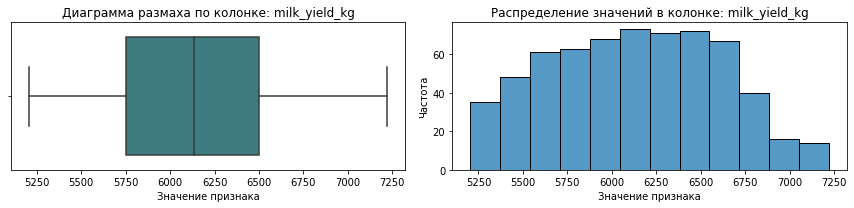

Доля выбросов: 0.00%


,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age


In [66]:
# проверка удаления выбросов
find_outliers(ferma_main, 'milk_yield_kg')

После удаления аномального значения распределение значений в колонке `milk_yield_kg` имеет вид близкий к нормальному.

Границы диаграммы размаха по колонке 'protein_percentage':
Lower Whisker: 3.07
Upper Whisker: 3.081


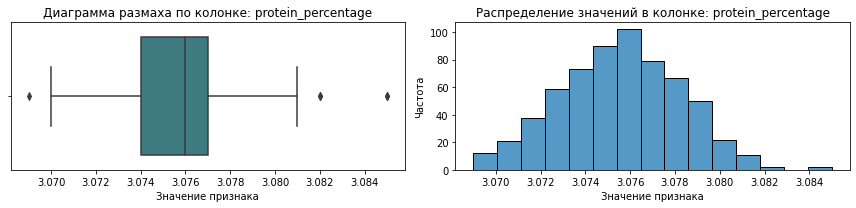

Доля выбросов: 0.80%


,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
77,78,5871,14.7,1795,0.895,вис бик айдиал,равнинное,айдиал,3.61,3.082,вкусно,более_2_лет
240,241,5568,13.4,1733,0.880,вис бик айдиал,равнинное,соверин,3.63,3.069,не вкусно,менее_2_лет
426,427,6701,15.7,2068,0.940,рефлешнсоверинг,холмистое,айдиал,3.72,3.082,вкусно,более_2_лет
471,472,5883,14.9,2159,0.890,вис бик айдиал,равнинное,соверин,3.62,3.085,вкусно,более_2_лет
517,518,5819,13.7,1968,0.840,вис бик айдиал,холмистое,айдиал,3.15,3.085,вкусно,более_2_лет


In [67]:
# посмотрим выбросы в колонке 'protein_percentage'
find_outliers(ferma_main, 'protein_percentage', bins=15)

Количество выбросов небольшое и отклонение от границ диаграммы размаха несущественное. Распределение значений близко к нормальному, на данном этапе оставим выбросы как есть.

Границы диаграммы размаха по колонке 'fat_percentage':
Lower Whisker: 3.4
Upper Whisker: 3.75


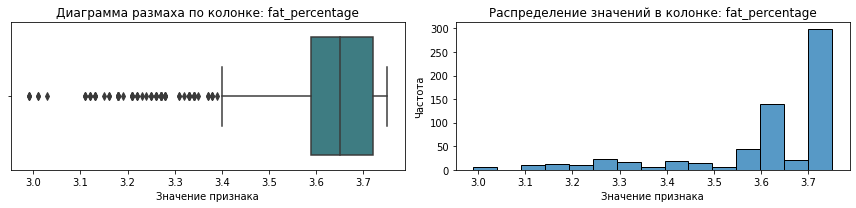

Доля выбросов: 13.69%


,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
5,6,5254,12.7,1806,0.885,рефлешнсоверинг,холмистое,соверин,3.13,3.078,вкусно,менее_2_лет
9,10,5339,13.4,1791,0.895,вис бик айдиал,холмистое,соверин,3.13,3.075,вкусно,менее_2_лет
10,11,5591,13.7,1678,0.895,рефлешнсоверинг,холмистое,айдиал,3.13,3.075,вкусно,менее_2_лет
17,18,5777,12.4,1873,0.895,вис бик айдиал,холмистое,айдиал,3.03,3.080,вкусно,более_2_лет
24,25,5372,13.2,1703,0.895,вис бик айдиал,равнинное,айдиал,3.31,3.078,не вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
587,588,5610,14.7,1671,0.880,вис бик айдиал,равнинное,айдиал,3.18,3.079,не вкусно,более_2_лет
589,590,5213,12.1,2016,0.880,рефлешнсоверинг,равнинное,соверин,3.19,3.076,не вкусно,менее_2_лет
591,592,5520,11.9,1785,0.880,вис бик айдиал,равнинное,соверин,3.12,3.073,не вкусно,менее_2_лет
602,603,5594,12.3,1742,0.880,вис бик айдиал,равнинное,айдиал,3.11,3.077,вкусно,менее_2_лет


In [68]:
# посмотрим выбросы в колонке 'fat_percentage'
find_outliers(ferma_main, 'fat_percentage', bins=15)

Процент выбросов по колонке `fat_percentage` (13.69%) существенный. Все пропуски сосредочены в левой части графика и  соответствуют длинному левому хвосту в распределении молока коров по проценту жирности.

Распределение жирности молока коров является асимметричным с длинным хвостом в сторону более низких значений. В выборке присутствуют выбросы, представляющие коров с очень низким процентом жирности, что влияет на общее распределение. Возможно, такие различия могут быть объяснены генетической предрасположенностью разных пород коров к производству молока с разными жирными составляющими или определенным состоянием здоровья отдельных коров (пожилые или слишком молодые коровы, недавно начавшие давать молоко, болеющие и т.д.). Также на жирность молока могут влиять условия кормления и ухода за животными, пастбище и др.

Доля выбросов достаточно существенная, на данном этапе не будем их удалять, чтобы не искажать результаты дальнейшего исследования. Замена значений медианами, средними либо другими значениями не имеет смысла, т.к. данные показывают реальные наблюдение и их искажения может привести к ошибкам в обучении можели и неверным предсказаниям.

Необходимость удаления аномальных выбросов рассмотрим позже на этапе калибровки, в случае если качество можели окажется неудовлетворительным.

**Таблица `ferma_dad`:**

Количественные признаки отсутсвуют.

**Таблица `cow_buy`:**

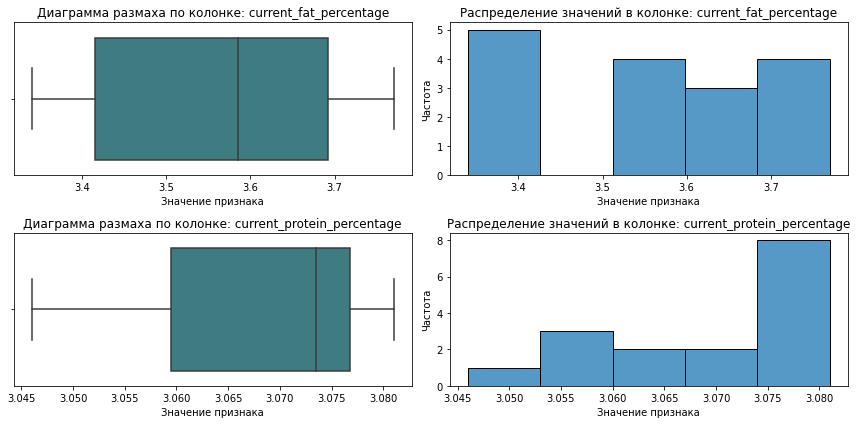

In [69]:
plot_box_hist_chart(cow_buy)

*1. Выбросы:* 

Выбросы значений в таблице `cow_buy` отсутствуют.

*2. Распределение значений:*
- распределение `current_fat_percentage` большое похоже на равномерное, чем на нормальное. Однако такой вид распределение может принимать из-за небольшого числа значений в выборке (всего 16 шт.)
- распределение `current_fat_percentage` имеет ассиметричный вид (смещено вправо) и длинный левый хвост.

#### Категориальные признаки

**Таблица `ferma_main`:**

In [70]:
# Функция для вывода графиков распределения (bar и pie) по категориальным признакам
def plot_bar_pie_chart(data, x_label=None, y_label=None, title=None, palette=None, value_counts=True):
    # Получение списка категориальных столбцов из данных
    categorical_cols = data.select_dtypes(include=['object']).columns
    num_plots = len(categorical_cols)
    
    # Создание субграфиков для столбцов, в зависимости от количества категориальных столбцов
    if num_plots == 1:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    else:
        fig, axes = plt.subplots(nrows=num_plots, ncols=2, figsize=(10, 4*num_plots))
    
    # Перебор по категориальным столбцам для построения графиков
    for i, col in enumerate(categorical_cols):
        # Получение количества значений в столбце
        counts = data[col].value_counts().sort_values() if value_counts else data[col]
        
        # Определение осей для столбчатой и круговой диаграмм
        if num_plots == 1:
            bar_ax = axes[0]
            pie_ax = axes[1]
        else:
            bar_ax = axes[i, 0]
            pie_ax = axes[i, 1]
        
        # Построение столбчатой диаграммы
        sns.barplot(x=counts.index, y=counts.values, palette=palette, ax=bar_ax)
        bar_ax.set_xlabel(x_label)
        bar_ax.set_ylabel(y_label)
        bar_ax.set_title(f'Распределение признаков в колонке: {col}')
        
        # Если установлено, строим круговую диаграмму
        if value_counts:
            pie_ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette(palette), wedgeprops={'edgecolor': 'black'})
            pie_ax.axis('equal')
            pie_ax.set_title(f'Доля каждого признака в колонке: {col}')
    
    # Настройка расстояния между графиками и компактное размещение
    plt.subplots_adjust(wspace=1)
    plt.tight_layout()
    plt.show()

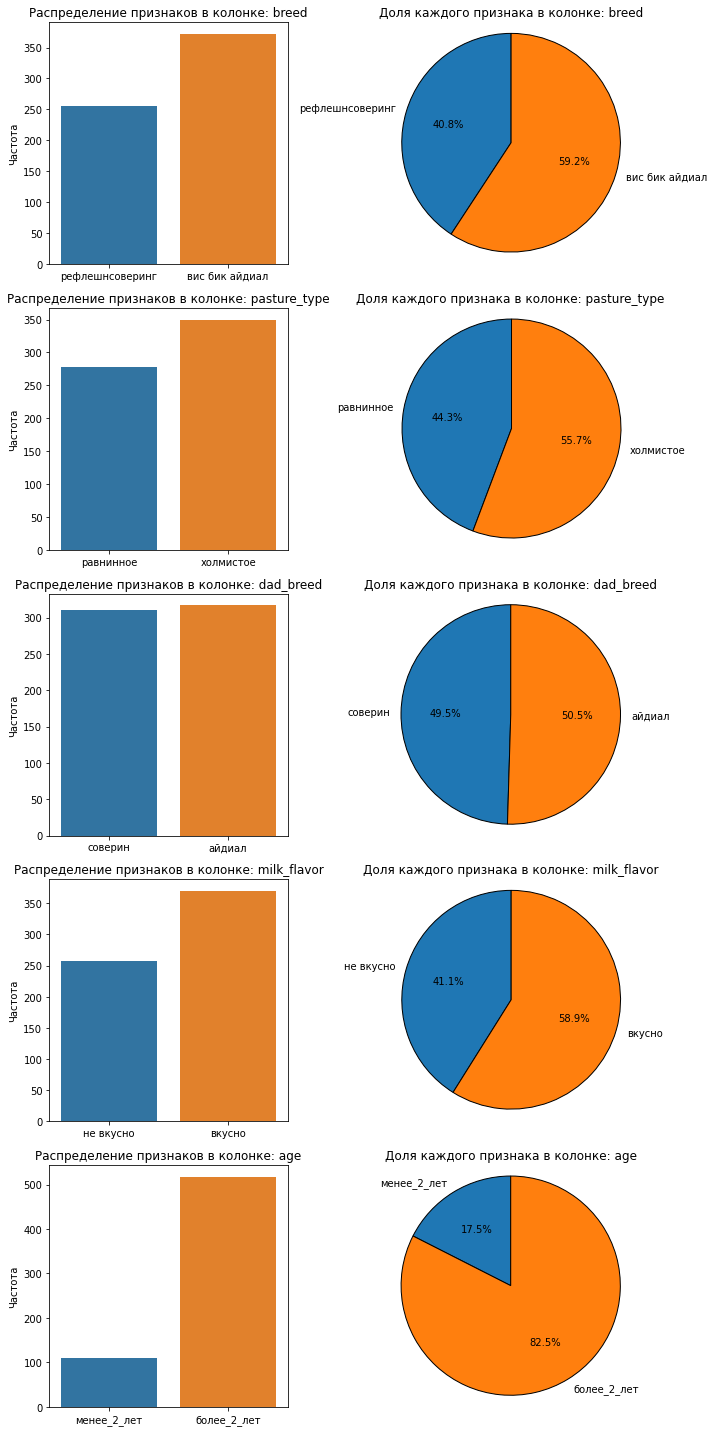

In [71]:
plot_bar_pie_chart(ferma_main, y_label='Частота')

Каждый категориальный признак в таблице `ferma_main` имеет ровно 2 уникальных значения (бинарный признак).

- по породе, типу пастбищ и вкусу молока коровы в стаде делятся в пропорциях близких к 60 на 40.
- половина коров в стаде имеют отца породы "айдиал", другая половина - отца породы "соверин".
- 83% коров в стаде являются взрослыми, т.е. старше 2 лет.

**Таблица `ferma_dad`:**

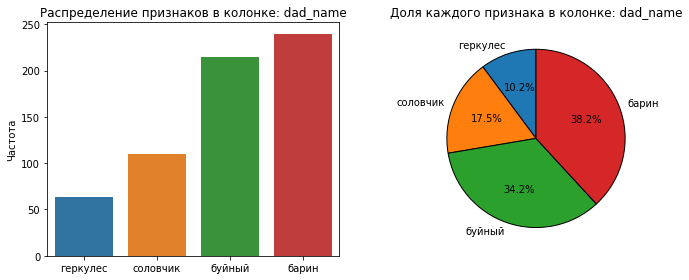

In [72]:
plot_bar_pie_chart(ferma_dad, y_label='Частота')

- "Барин" и "Буйный" являются отцами большинства коров в стаде (38% и 34%, соответственно).
- "Соловчик" и "Геркулес" - отцами оставшихся 18% и 10% коров, соответвенно.

**Таблица `cow_buy`:**

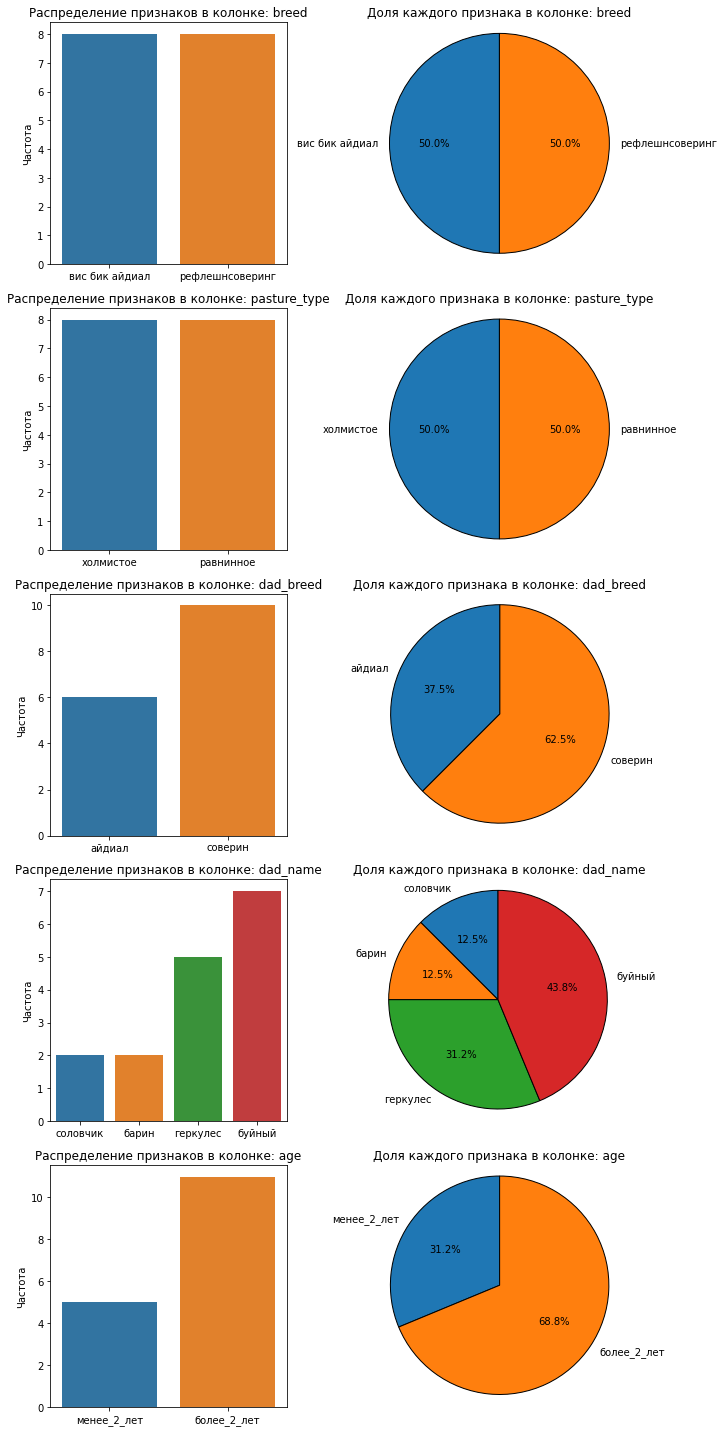

In [73]:
plot_bar_pie_chart(cow_buy, y_label='Частота')

Коровы в ассоциации пастбищ "ЭкоФерма":
- относятся к тем же породам, что и коровы хозяйства "Вольный луг" ("вис бик айдиал" и "рефлешнсоверинг" в пропорции 50:50)
- пасутся на таких же типах пастбищ ("равнинное" и "холмистое" в пропорции 50:50)
- также совпадает и порода отцов коров ("соверин" и "айдиал" в пропорции приблизительно 60:40)
- стадо "Экофермы" немного моложе чем стадо фермы (доля возрастных коров 69% против 83% в "Вольном луге")
- коровы имеют отцов с теми же именами, что и коровы в хозяйстве "Вольный луг", однако их доли отличаются ("Барин", который был лидером в хозяйстве "Вольный луг" с долей 38.2%, занимает последнее место на "Экоферме" с долей 12.5%).

### Вкус молока

Поскольку таблицы ferma_main и ferma_dad характеризуют коров с одной и той же ферме, то их можно объединить в одну для удобства дальнейшего анализа.

In [74]:
print(f'Размер таблицы ferma_main: {ferma_main.shape}')
print(f'Размер таблицы ferma_dad: {ferma_dad.shape}')

# объединим таблицы ferma_main и ferma_dad
ferma = pd.merge(ferma_main, ferma_dad, on='id')
print(f'Размер таблицы ferma: {ferma.shape}')
print(f'Количество пропусков в таблице ferma: {ferma.isna().sum().sum()}')

ferma.head()

Размер таблицы ferma_main: (628, 12)
Размер таблицы ferma_dad: (629, 2)
Размер таблицы ferma: (628, 13)
Количество пропусков в таблице ferma: 0


,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age,dad_name
0,1,5863,14.2,1743,0.890,вис бик айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,буйный
1,2,5529,12.8,2138,0.890,вис бик айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,соловчик
2,3,5810,14.0,1854,0.885,рефлешнсоверинг,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,барин
3,4,5895,12.4,2012,0.885,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,буйный
4,5,5302,12.8,1675,0.885,вис бик айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,барин


ferma_dad изначально содержала на 1 строчку больше, т.к. из ferma_main мы ранее удалили коровы с id=17, которая имела аномальное значение удоя.

Объединение прошло успешно. 

На вкус молока потенциально могут влиять следующие факторы:
- Особенности коровы;
- Где паслась корова;
- Характеристики молока;
- Параметры корма коровы.

Для удобства подсчета доли коров с вкусным молоком сделаем следующую замену в колонке `milk_flavor`:
- "вкусно" заменим на 1;
- "не вкусно" заменим на 0.

In [75]:
# Заменяем значения в колонке milk_flavor
ferma['milk_flavor'] = ferma['milk_flavor'].replace({'вкусно': 1, 'не вкусно': 0})

In [76]:
# доля коров с вкусным молоком
ferma['milk_flavor'].mean()

0.589171974522293

#### Влияние особенностей коровы на вкус молока

К особенностям коровы относятся:

- `id` - номер коровы;
- `breed` - порода коровы;
- `age` - бинарный признак (`менее_2_лет`, `более_2_лет`);
- `dad_breed` - порода папы коровы.
- `dad_name` - имя папы коровы

In [77]:
# вкус молока в зависимости от породы
ferma.groupby('breed')['milk_flavor'].agg(['mean', 'count'])

,mean,count
breed,,
вис бик айдиал,0.586022,372
рефлешнсоверинг,0.593750,256


In [78]:
# вкус молока в зависимости от породы отца
ferma.groupby('dad_breed')['milk_flavor'].agg(['mean', 'count'])

,mean,count
dad_breed,,
айдиал,0.589905,317
соверин,0.588424,311


- Порода и порода отца по отдельности практически не влияют на вкус молока.

In [79]:
# вкус молока в зависимости от возраста коровы
ferma.groupby('age')['milk_flavor'].agg(['mean', 'count'])

,mean,count
age,,
более_2_лет,0.615830,518
менее_2_лет,0.463636,110


- Средняя доля коров с вкусным молоком среди возрастных коров выше (62%), чем среди молодых коров (46%).

In [80]:
ferma.groupby('dad_name')['milk_flavor'].agg(['mean', 'count'])

,mean,count
dad_name,,
барин,0.620833,240
буйный,0.593458,214
геркулес,0.546875,64
соловчик,0.536364,110


- Коровы с именем отца "барин" или "буйный" чаще всего имеют вкусное молоко (в около 60% случаях). Молоко коров от отцов "геркулес" и "соловчик" реже бывает вкусным (в 54% случаях)

In [81]:
(ferma
 .groupby(['dad_breed', 'dad_name'])['milk_flavor']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,dad_breed,dad_name,mean,count
0,айдиал,барин,0.750000,28
4,соверин,барин,0.603774,212
1,айдиал,буйный,0.593458,214
5,соверин,соловчик,0.555556,99
2,айдиал,геркулес,0.546875,64
3,айдиал,соловчик,0.363636,11


- Самое вкусное молоко в среднем у коров, чей отец принадлежит породе "айдиал" или "соверин" и имеет имя "барин". Наименне удачное сочетание породы "айдиал" и имени отца "соловчик".

In [82]:
adult_cow_flavor_rating = (ferma
 .groupby(['breed', 'dad_breed', 'dad_name'])['milk_flavor']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)
# добавление колонки с позицией в рейтинге
adult_cow_flavor_rating['top_flavor'] = range(1, len(adult_cow_flavor_rating) + 1)
adult_cow_flavor_rating

,breed,dad_breed,dad_name,mean,count,top_flavor
0,вис бик айдиал,айдиал,барин,0.900000,10,1
6,рефлешнсоверинг,айдиал,барин,0.666667,18,2
10,рефлешнсоверинг,соверин,барин,0.607143,112,3
4,вис бик айдиал,соверин,барин,0.600000,100,4
8,рефлешнсоверинг,айдиал,геркулес,0.600000,10,5
7,рефлешнсоверинг,айдиал,буйный,0.597701,87,6
1,вис бик айдиал,айдиал,буйный,0.590551,127,7
5,вис бик айдиал,соверин,соловчик,0.575342,73,8
2,вис бик айдиал,айдиал,геркулес,0.537037,54,9
11,рефлешнсоверинг,соверин,соловчик,0.500000,26,10


- Добавление породы коровы в качестве критерия существенно не повлияло на топ коров по вкусу молока. По прежнему самое удачные сочетания: "айдиал" - "барин" и "соверин" - "барин", наименее удачное: "айдиал" - "соловчик".
- В сочетании "айдиал" - "барин" порода коровы "вис бик айдиал" дает существенный прирост вкусу (90% случаев против 67%).
- В сочетании "соверин" - "барин" порода коровы практически не влияет на вкус молока (около 60% случаев). 

Молоко возрастных коров в среднем вкуснее чем у молодых. Молодые коровы достаточно быстро переходят в категорию взрослых (2 года). Выбирая перспективные породы коров, следуюет обратить особое внимание на то, какое молоко будет давать именно взрослая корова.

In [83]:
(ferma
 .query('age == "более_2_лет"')
 .groupby(['breed', 'dad_breed', 'dad_name'])['milk_flavor']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,breed,dad_breed,dad_name,mean,count
0,вис бик айдиал,айдиал,барин,1.000000,6
6,рефлешнсоверинг,айдиал,барин,0.714286,14
8,рефлешнсоверинг,айдиал,геркулес,0.666667,9
10,рефлешнсоверинг,соверин,барин,0.666667,84
4,вис бик айдиал,соверин,барин,0.637681,69
1,вис бик айдиал,айдиал,буйный,0.629310,116
5,вис бик айдиал,соверин,соловчик,0.615385,52
7,рефлешнсоверинг,айдиал,буйный,0.588235,85
2,вис бик айдиал,айдиал,геркулес,0.529412,51
11,рефлешнсоверинг,соверин,соловчик,0.521739,23


Видим, что среди взрослых картина практически не поменялась:

- Молоко коров с отцом в сочетании "айдиал" - "барин", чаще всего оказывалось вкусным. Если в добавок к этом, взрослая корова в таком сочетании принадлежала породе "вис бик айдиал", то ее молоко оказывалось вкусным в 100% случаев.
- Устойчиво приемлемое качество молока (в около 60% случаев) вне зависимости от породы коровы дают сочетания "соверин" - барин" и "айдиал" - "буйный"
- Аутсайдер рейтинга по прежнему сочетание "айдиал" - "соловчик".

#### Влияние места выпаса на вкус молока

In [84]:
(ferma
 .groupby(['pasture_type'])['milk_flavor']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,pasture_type,mean,count
1,холмистое,0.668571,350
0,равнинное,0.489209,278


Коровы, которые паслись в холмистой местности чаще дают вкусное молоко (в 67% случаев, против 49% для равнины)

#### Влияние особенностей корма на вкус молока

Напомним какие колонки определяют параметры корма коровы:
- `energy_feed_unit` ("ЭКЕ (Энергетическая кормовая единица)"): Измерение питательности корма коровы.
- `crude_protein_g` ("Сырой протеин, г"): Содержание сырого протеина в корме коровы, в граммах.
- `sugar_protein_ratio` ("СПО (Сахаро-протеиновое соотношение)"): Отношение сахара к протеину в корме коровы.

In [85]:
# Вкус молока и средние параметры корма:
feed_flavor = ferma.groupby('milk_flavor')[['energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio']].mean()
feed_flavor

,energy_feed_unit,crude_protein_g,sugar_protein_ratio
milk_flavor,,,
0,14.214729,1891.248062,0.905795
1,14.781622,1946.429730,0.918176


Корм коров, дающих вкусное молоко, в среднем был более питательным по всем показателям.

In [86]:
print(f'Разница в ЭКЕ: {round((feed_flavor.loc[1, "energy_feed_unit"] / feed_flavor.loc[0, "energy_feed_unit"] - 1)*100, 2)}%')
print(f'Разница в сыром протеине: {round((feed_flavor.loc[1, "crude_protein_g"] / feed_flavor.loc[0, "crude_protein_g"] - 1)*100, 2)}%')
print(f'Разница в СПО: {round((feed_flavor.loc[1, "sugar_protein_ratio"] / feed_flavor.loc[0, "sugar_protein_ratio"] - 1)*100, 2)}%')


Разница в ЭКЕ: 3.99%
Разница в сыром протеине: 2.92%
Разница в СПО: 1.37%


#### Влияние параметров молока не его вкус

Молоко характеризуется следующими параметрами:
- `fat_percentage` ("Жирность,%"): Содержание жиров в молоке, в процентах.
- `protein_percentage` ("Белок,%"): Содержание белков в молоке, в процентах.

In [87]:
# Вкус молока и средние параметры корма:
milk_flavor = ferma.groupby('milk_flavor')[['fat_percentage', 'protein_percentage']].mean()
milk_flavor

,fat_percentage,protein_percentage
milk_flavor,,
0,3.585310,3.075279
1,3.617486,3.075943


Средние характеристики вкусного и невкусного молока практически не отличаются.

### Удой коровы

Потенциально удой коровы мог зависеть от следующих параметров:
- особенностей коровы;
- где паслась корова;
- параметров корма.

#### Влияние особенностей коровы на удой

In [88]:
# вкус молока в зависимости от породы
ferma.groupby('breed')['milk_yield_kg'].agg(['mean', 'count'])

,mean,count
breed,,
вис бик айдиал,6099.405914,372
рефлешнсоверинг,6164.566406,256


- Обе породы коров имеют примерно одинаковый средний размер удоя.

In [89]:
# вкус молока в зависимости от породы отца
ferma.groupby('dad_breed')['milk_yield_kg'].agg(['mean', 'count'])

,mean,count
dad_breed,,
айдиал,6310.899054,317
соверин,5937.469453,311


- Коровы  с породой отца "айдиал" имеют в среднем более высокий размер удоя, чем коровы с породой отца "соверин"

In [90]:
# вкус молока в зависимости от возраста коровы
ferma.groupby('age')['milk_yield_kg'].agg(['mean', 'count'])

,mean,count
age,,
более_2_лет,6270.735521,518
менее_2_лет,5444.245455,110


- Взрослые коровы в среднем дают существенно больше молока, чем молодые.

In [91]:
(ferma
 .groupby('dad_name')['milk_yield_kg']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,dad_name,mean,count
1,буйный,6364.481308,214
2,геркулес,6360.953125,64
3,соловчик,6023.827273,110
0,барин,5897.445833,240


- Больше всего молока дают коровы, с именем отца "буйный" или "геркулес" (около 6360 кг в среднем).
- Меньше всего молока дают коровы породы "барин" (около 5900 кг в среднем).

In [92]:
(ferma
 .groupby(['dad_breed', 'dad_name'])['milk_yield_kg']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,dad_breed,dad_name,mean,count
1,айдиал,буйный,6364.481308,214
2,айдиал,геркулес,6360.953125,64
5,соверин,соловчик,6027.959596,99
3,айдиал,соловчик,5986.636364,11
0,айдиал,барин,5914.357143,28
4,соверин,барин,5895.212264,212


Если добавить породу к имени отца, то рейтинг не поменяется.

In [93]:
(ferma
 .groupby(['breed', 'dad_breed', 'dad_name'])['milk_yield_kg']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,breed,dad_breed,dad_name,mean,count
7,рефлешнсоверинг,айдиал,буйный,6503.298851,87
2,вис бик айдиал,айдиал,геркулес,6362.500000,54
8,рефлешнсоверинг,айдиал,геркулес,6352.600000,10
1,вис бик айдиал,айдиал,буйный,6269.385827,127
11,рефлешнсоверинг,соверин,соловчик,6228.538462,26
9,рефлешнсоверинг,айдиал,соловчик,6194.333333,3
5,вис бик айдиал,соверин,соловчик,5956.520548,73
0,вис бик айдиал,айдиал,барин,5950.100000,10
10,рефлешнсоверинг,соверин,барин,5912.410714,112
3,вис бик айдиал,айдиал,соловчик,5908.750000,8


С добавление породы коровы рейтинг также не претерпел существенных изменений.

Учитывая, что коровы старше двух лет в среднем дают больший удой и мы выбираем корову на перспективу, есть смысл дополнительно проанализировать средний удой взрослых коров.

In [94]:
adult_cow_yield_rating = (ferma
 .query('age == "более_2_лет"')
 .groupby(['breed', 'dad_breed', 'dad_name'])['milk_yield_kg']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)
# добавление колонки с позицией в рейтинге
adult_cow_yield_rating['top_yield'] = range(1, len(adult_cow_flavor_rating) + 1)
adult_cow_yield_rating

,breed,dad_breed,dad_name,mean,count,top_yield
7,рефлешнсоверинг,айдиал,буйный,6526.423529,85,1
8,рефлешнсоверинг,айдиал,геркулес,6463.111111,9,2
2,вис бик айдиал,айдиал,геркулес,6409.235294,51,3
1,вис бик айдиал,айдиал,буйный,6344.612069,116,4
11,рефлешнсоверинг,соверин,соловчик,6324.608696,23,5
0,вис бик айдиал,айдиал,барин,6297.333333,6,6
9,рефлешнсоверинг,айдиал,соловчик,6194.333333,3,7
5,вис бик айдиал,соверин,соловчик,6154.557692,52,8
10,рефлешнсоверинг,соверин,барин,6093.857143,84,9
3,вис бик айдиал,айдиал,соловчик,6058.166667,6,10


В целом, если смотреть на удой взрослых коров в зависимости от особенностей коровы, то у всех разновидностей коров средний удой превышает минимальную границу 6000 кг, который требуется хозяйству "Вольный луг".

При этом, самые удачные сочетания вне зависимости от породы коровы:
- "айдиал" - "буйный"
- "айдиал" - "геркулес"

Средний результат также имеют сочетания:
- "рефлешнсоверинг" - "соверин" - "соловчик"
- "вис бик айдиал" - "айдиал" - "барин".

#### Влияние места выпаса на удой

In [95]:
(ferma
 .groupby(['pasture_type'])['milk_yield_kg']
 .agg(['mean', 'count'])
 .reset_index()
 .sort_values(by='mean', ascending=False)
)

,pasture_type,mean,count
1,холмистое,6181.314286,350
0,равнинное,6056.287770,278


Коровы, которые паслись в холмистой местности в среднем дают немного больше молока (в 6181 кг., против 6056 кг. для равнины). Разница не существенная

#### Влияние особенностей корма на удой

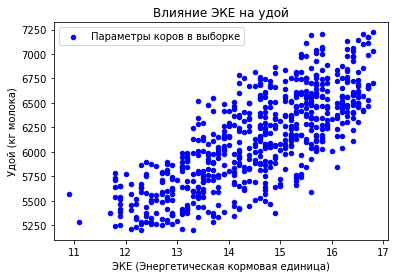

In [96]:
# Влияние ЭКЕ на удой
ferma.plot(kind='scatter', x='energy_feed_unit', y='milk_yield_kg', color='blue', label='Параметры коров в выборке')

plt.xlabel('ЭКЕ (Энергетическая кормовая единица)')
plt.ylabel('Удой (кг молока)')

plt.title('Влияние ЭКЕ на удой')

plt.legend()
plt.show()

На графике видно наличие зависимости между удоем и ЭКЕ корма: чем выше ЭКЕ корма, тем выше удой. 

Характер зависимости представляет собой что-то среднее между линейной и квадратичной зависимостью. Учитывая вводные параметры по проекту, можно предположить что связь все-таки квадратичная, однако на полученном диапазоне области определения функции квадратичность выражено слабо и форма связи близка к линейной.

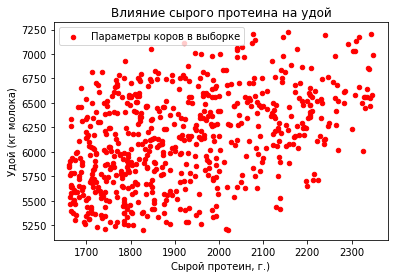

In [97]:
# Влияние сырого протеина на удой
ferma.plot(kind='scatter', x='crude_protein_g', y='milk_yield_kg', color='red', label='Параметры коров в выборке')

plt.xlabel('Сырой протеин, г.)')
plt.ylabel('Удой (кг молока)')

plt.title('Влияние сырого протеина на удой')

plt.legend()
plt.show()

Зависимость удоя от содержание сырого протеина не такая явная.

Однако коровы которые получали корм с очень высоким содержание сырого протеина (>2300 г.) не давали удой меньше 6000 кг.

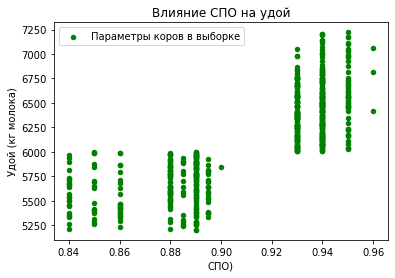

In [98]:
# Влияние СПО на удой
ferma.plot(kind='scatter', x='sugar_protein_ratio', y='milk_yield_kg', color='green', label='Параметры коров в выборке')

plt.xlabel('СПО)')
plt.ylabel('Удой (кг молока)')

plt.title('Влияние СПО на удой')

plt.legend()
plt.show()


Чтобы удой коровы составлял выше 6000кг, показатель СПО должен быть не менее 0.92. Связь нелинейная.

### Сочетание вкуса и высокого удоя

#### Особенности коровы

In [99]:
adult_cow_rating = pd.merge(adult_cow_flavor_rating, adult_cow_yield_rating, on=['breed', 'dad_breed', 'dad_name'], how='outer')

In [100]:
adult_cow_rating.head()

,breed,dad_breed,dad_name,mean_x,count_x,top_flavor,mean_y,count_y,top_yield
0,вис бик айдиал,айдиал,барин,0.900000,10,1,6297.333333,6,6
1,рефлешнсоверинг,айдиал,барин,0.666667,18,2,6040.285714,14,12
2,рефлешнсоверинг,соверин,барин,0.607143,112,3,6093.857143,84,9
3,вис бик айдиал,соверин,барин,0.600000,100,4,6055.275362,69,11
4,рефлешнсоверинг,айдиал,геркулес,0.600000,10,5,6463.111111,9,2


Параметры вкуса и удоя одинаково важны для целей нашего анализа, поэтому присвоим им равные веса и посчитаем итоговый рейтинг.

In [101]:
adult_cow_rating['final_score'] = adult_cow_rating['top_flavor'] * 0.5 + adult_cow_rating['top_yield'] * 0.5

In [102]:
adult_cow_rating = adult_cow_rating.sort_values(by='final_score').reset_index(drop=True)
adult_cow_rating

,breed,dad_breed,dad_name,mean_x,count_x,top_flavor,mean_y,count_y,top_yield,final_score
0,вис бик айдиал,айдиал,барин,0.900000,10,1,6297.333333,6,6,3.5
1,рефлешнсоверинг,айдиал,геркулес,0.600000,10,5,6463.111111,9,2,3.5
2,рефлешнсоверинг,айдиал,буйный,0.597701,87,6,6526.423529,85,1,3.5
3,вис бик айдиал,айдиал,буйный,0.590551,127,7,6344.612069,116,4,5.5
4,рефлешнсоверинг,соверин,барин,0.607143,112,3,6093.857143,84,9,6.0
5,вис бик айдиал,айдиал,геркулес,0.537037,54,9,6409.235294,51,3,6.0
6,рефлешнсоверинг,айдиал,барин,0.666667,18,2,6040.285714,14,12,7.0
7,вис бик айдиал,соверин,барин,0.600000,100,4,6055.275362,69,11,7.5
8,рефлешнсоверинг,соверин,соловчик,0.500000,26,10,6324.608696,23,5,7.5
9,вис бик айдиал,соверин,соловчик,0.575342,73,8,6154.557692,52,8,8.0


Если рассматривать взрослых коров на перспективу, то лучшим сочетанием удоя и вкуса обладают следующие 3 вида коров:

<table>
  <tr>
    <th>Порода</th>
    <th>Порода отца</th>
    <th>Имя отца</th>
    <th>Вероятность вкусного молока</th>
    <th>Средний удой</th>
  </tr>
  <tr>
    <td>Вис бик айдиал</td>
    <td>Айдиал</td>
    <td>Барин</td>
    <td>90.00%</td>
    <td>6297.33</td>
  </tr>
  <tr>
    <td>Рефлешнсоверинг</td>
    <td>Айдиал</td>
    <td>Геркулес</td>
    <td>60.00%</td>
    <td>6463.11</td>
  </tr>
  <tr>
    <td>Рефлешнсоверинг</td>
    <td>Айдиал</td>
    <td>Буйный</td>
    <td>59.77%</td>
    <td>6526.42</td>
  </tr>
</table>

Учитывая, что различие в удое небольшое, а шанс получить вкусное молоко в полтора раза выше у сочетания **"вис бик айдиал"- "айдиал" - "барин"**, то это сочетание явно выглядит перспективней, чем два других.	


#### Место выпаса

- Шанс получить вкусное молоко у коров, которые пасутся в холмистой местности выше (67%), чем у пасущихся на равнине (49%)
- Размер удоя у коров, пасущихся в холмистой местности также немного выше, чем на равнине (в 6181 кг., против 6056 кг.)

Исходя из этого, можно сделать вывод, что предпочтительное место для выпаса коров - **холмистая местность**.

#### Особенности корма

Чем более питательный корм, тем в среднем лучший вкус и больший удой дает корова. При это на вкус молока параметры корма влияют не так сильно, как на размер удоя.

Чтобы размер удоя был больше 6000 кг, параметр корма СПО должен быть не менее 0.92. Размер удоя линейно зависит от ЭКЕ, поэтому чем больше ЭКЕ, тем выше потенциальный удой.

#### Параметры молока

Вкусное и невкусное молоко практически не отличается по своим параметрам (% жира и протеина). Прямая причинно-следственная связь между размером удоя и параметрами молока не наблюдается.

### Выводы

Проведенный исследовательский анализ данных на молочной ферме "Вольный луг" позволяет сделать следующие выводы:

**1. Распределение данных и выбросы:**

*Выбросы были обнаружены в следующих колонках в процессе анализа данных:*
- `milk_yield_kg` - одно значение, существенное выбивающееся в большую сторону, было удалено. Вероятная причина техническая ошибка или человеческий фактор.
- `fat_percentage` - большое количество выбросов в левой части графика. Процент выбросов (13.69%) существенный. Все пропуски сосредочены в левой части графика и соответствуют длинному левому хвосту в распределении молока коров по проценту жирности. Доля выбросов достаточно существенная, на данном этапе не будем их удалять. Выбросы вероятно имеют естественные причины.
- `protein_percentage` - небольшие выбросы как слева, так и справа (все 5 значений - 0.80% выборки, отклонения небольшие). Выбросы скорей всего имеют естественные причины. Выбросы оставлены в выборке.

Необходимость удаления оставшихся аномальных значений рассмотрим позже на этапе калибровки, в случае если качество модели окажется неудовлетворительным.

*Распределение значений:*

- Нормальное:
 - распределение величины `milk_yield_kg` имеет вид близкий к нормальному.
 - распеределение данных в колонке `energy_feed_unit` близко к нормальному, однако правый хвост распределения обрезан. Вероятно, предпочтение отдается кормам со средним и низким ЭКЕ.
 - распределение значений `crude_protein_g` тоже близко к нормально, но в данном случае отсутствует левая часть колокола распределения. Вероятно, в хозяйстве используются корма со средним и высоким содержанием сырого протеина.
 - значения `protein_percentage` распределены нормально. Есть небольшие выбросы в районе хвостов распределения.
 - на графике `fat_percentage` распределение ассиметрично (смещено вправо), наблюдается длинный левый хвост.  При это разброс по  процентам жирности небольшой (3-3.7%). В правой части графика заметны 2 пика в районе 3.6% и на 3.7%.
 
 
- Ненормальное:
 - на графике распределения `sugar_protein_ration` заметны 3 пика, отделенные друг от друга. Возможно такой вид распределения объясняется различными видами корма, который закупается хозяйством (например, это могут быть 3 разных вида корма с разным отношением сахара к протеину в них, и их распределения накладываются на один график).
 
Хозяйства "Вольный луг" и "ЭкоФерма" обладают сходством в распределении категориальных признаков, таких как порода коров и типы пастбищ, которые в обоих случаях делятся практически поровну. Однако, между ними есть и различия, например:
- Например, в "Вольном луге" взрослые коровы составляют 83% стада, в то время как стадо "ЭкоФермы" более молодое - доля взрослых коров 69%.
- Кроме того, распределение отцов коров в "Вольном луге" и "ЭкоФерме" различается: если в первом случае "Барин" и "Буйный" являются основными отцами коров, то во втором "Барин" уступает свою позицию и занимает последнее место с долей 12.5%. 

Такие различия указывают на уникальные особенности каждого хозяйства в контексте структуры стада и генетики его животных.

   
**2. Характеристики типичной коровы в хозяйстве:**

| Параметр типичной коровы             | хозяйство "Вольный луг" | хозяйство "ЭкоФерма" |
|--------------------------------------|-------------------------|----------------------|
| Порода коровы                        | Вис Бик Айдиал          | Рефлешнсоверинг      |
| Порода отца коровы                   | Айдиал                  | Соверин              |
| Имя отца коровы                      | Барин                   | Буйный               |
| Возраст коровы                       | старше 2 лет            | старше 2 лет         |
| Удой (кг)                            | 6189                    | -                    |
|                                      |                         |                      |
| Тип пастбища                         | Холмистое               | Равнинное            |
| ЭКЕ в корме                          | 14.54                   | -                    |
| Сырой протеин в корме (г)            | 1923                    | -                    |
| СПО в корме                          | 0.91                    | -                    |
|                                      |                         |                      |
| Вкус молока                          | Вкусно                  | -                    |
| Средняя жирность молока (%)          | 3.60                    | 3.57                 |
| Содержание белка в молоке (%)        | 3.08                    | 3.07                 |

Характеристики типичной коровы в хозяйстве "Вольный луг" практически совпадают с характеристиками типичной коровы в ассоциации пастбищ "ЭкоФерма" (за исключением типичной породы и имени папы коровы).
 
**3. Факторы, влияющие на вкус молока:**

- Взрослые коровы дают вкусное молоко заметно чаще (62%), чем молодые (46%). Молодые коровы достаточно быстро переходят в категорию взрослых (> 2 лет), поэтому выбирая перспективные породы, следуюет обратить особое внимание на то, какое молоко будет давать взрослая корова.
- По отдельности порода, порода отца и имя отца коровы практически не влияют на вкус молока. Однако их сочетания в среднем показывают очень разные шансы на получения вкусного молока:
 - лучшее сочетания: "вис бик айдиал" - "айдиал" - "барин" (90% шанс получить вкусное молоко, а у взрослых коров 100%!)
 - худшее сочетание: "рефлешнсоверинг" - "айдиал" - "соловчик (33% шанс получить вкусное молоко).	

**4. Факторы, влиющие на удой коровы:**

- Взрослые коровы дают существенно больше молока (6270 кг.), чем молодые (5444 кг.). Как и в случае вкуса, имеет смысл оценивать параметры взрослых коров, т.к. средний удой молодых коров сильно ниже 6000 кг. и коровы быстро становятся взрослыми. 
- Генетика коровы оказывает существенное влияние на размер удоя:
 - Коровы с породой отца "айдиал" имеют в среднем более высокий размер удоя (6310 кг.), чем с породой отца "соверин" (5937 кг.).
 - Коровы с именем отца "буйный" или "геркулес" дают в среднем большего всего молока (около 6360 кг.), меньше всего - "барин" (около 5900 кг.). 
  - Коровы породы "вис бик айдиал" (6100 кг) и "рефлешнсоверинг" (6165 кг.) дают примерно одинаковое количество молока в среднем. 
  - При этом у всех сочетаний взрослых коров средний удой превышает 6000 кг.
  - Среди коров самое успешное сочетание: "рефлешнсоверинг"- "айдиал" - "буйный" (6503 кг, в взрослых - 6526 кг.), наименее успешное: "вис бик айдиал" - "соверин" - "барин" (5875 кг., у взрослых - 6055кг). 
- Средний удой коров, пасущихся на холмистых и равнинных пастбищах практически не отличается.
- Размер удоя напрямую зависит от ЭКЕ корма: чем выше ЭКЕ корма, тем выше удой.
- Связь между содержанием сырого протеина и удоем также прямая, но не так хорошо выражена. Для удоя выше 6000 кг требуется показатель СПО не менее 0.92.

**5. Перспективные кандидаты:**

Если рассматривать взрослых коров, то лучшим потенциальным сочетанием размера удоя и вкуса обладают следующие 3 вида коров:

| Порода          | Порода отца | Имя отца | Вероятность вкусного молока | Средний удой, кг. |
|-----------------|-------------|----------|-----------------------------|-------------------|
| Вис бик айдиал  | Айдиал      | Барин    | 90.00%                      | 6297.33           |
| Рефлешнсоверинг | Айдиал      | Геркулес | 60.00%                      | 6463.11           |
| Рефлешнсоверинг | Айдиал      | Буйный   | 59.77%                      | 6526.42           |

Учитывая, что различие в удое небольшое, а шанс получить вкусное молоко в полтора раза выше у сочетания <u>"вис бик айдиал"- "айдиал" - "барин"</u>, то это сочетание выглядит намного перспективней всех остальных.


## Корреляционный анализ

Построим диаграмму рассеивания по всем признакам в таблице ferma.

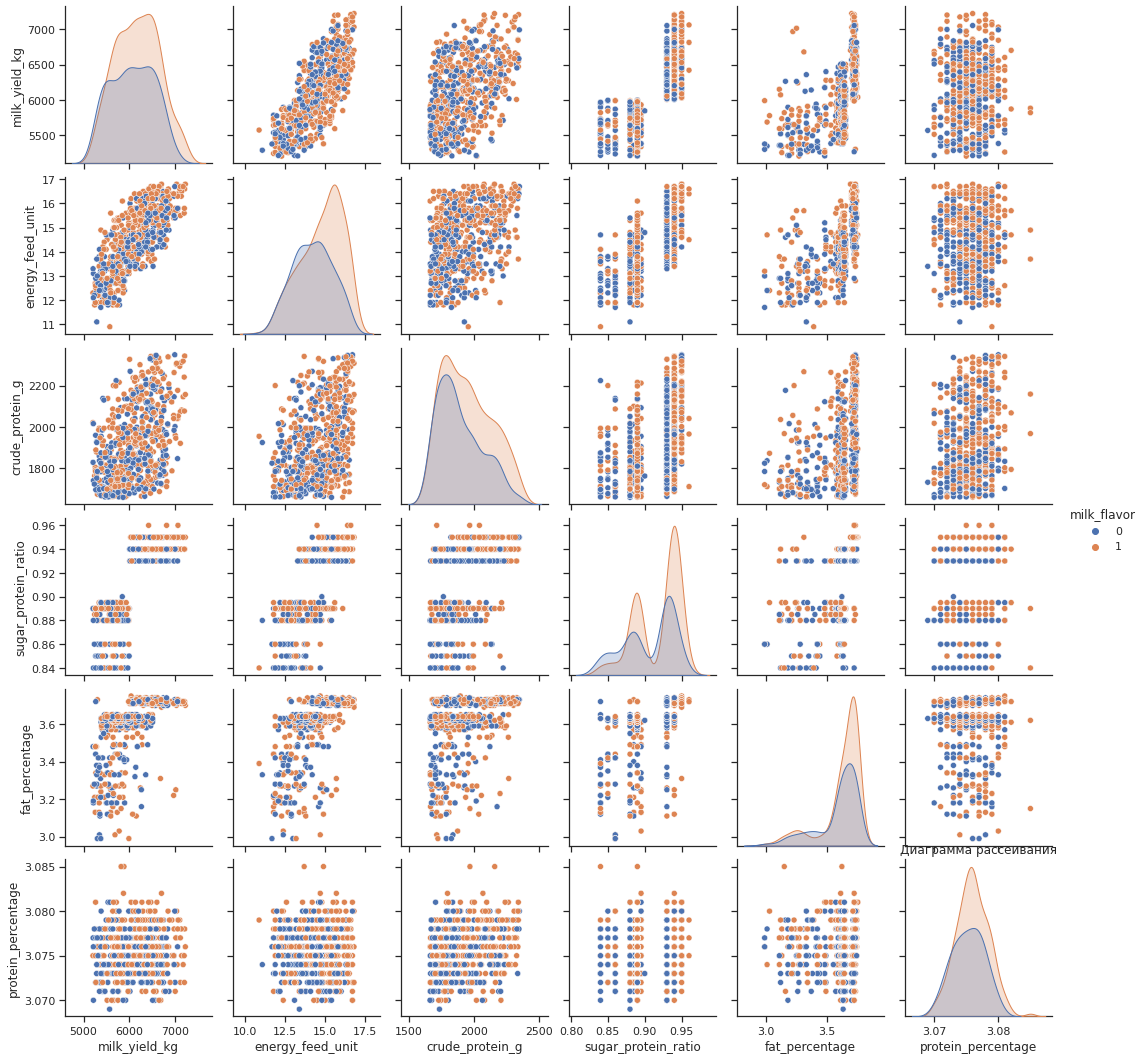

In [103]:
sns.set(style="ticks")
sns.pairplot(ferma.drop('id', axis=1), hue="milk_flavor")
plt.title('Диаграмма рассеивания')
plt.show()

Большинство данных распределено нормально или имеет форму близкую к нормальному распределению (кроме показателя `sugar_protein_ratio`). 

График `sugar_protein_ratio` имеет вид несимметричного мультимодального распределения, т.е. два или три распределения будто накладываются друг на друга. Чтобы избавиться от мультимодальности можно разделить этот признак на два отдельных (содержание сахара и содержание протеина в молоке) либо категоризировать.

Посколько содержание протеина в корме уже дано в таблице (`crude_protein_g`), то чистое содержание сахаров в нем, предположительно (если речь идет об одном и том же протеине), можно восстановить по следующей формуле:

        `sugar_g = crude_protein_g * sugar_protein_ratio`
        
Попробуем это сделать и добавим соответствующую колонку в таблицу `ferma`. Посмотрим как поменялось распределение.

In [104]:
# сохраним измененную таблицу в копию, чтобы потом была возможность проверить качество модели на двух данных 
ferma_sugar = ferma.copy()
ferma_sugar['sugar_g'] = ferma_sugar['crude_protein_g'] * ferma_sugar['sugar_protein_ratio']
# удалим исходный столбец, т.к. по смыслу он дублирует новый
ferma_sugar.drop('sugar_protein_ratio', axis=1, inplace=True)
ferma_sugar.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age,dad_name,sugar_g
0,1,5863,14.2,1743,вис бик айдиал,равнинное,айдиал,3.58,3.076,1,более_2_лет,буйный,1551.270
1,2,5529,12.8,2138,вис бик айдиал,равнинное,соверин,3.54,3.079,1,менее_2_лет,соловчик,1902.820
2,3,5810,14.0,1854,рефлешнсоверинг,холмистое,соверин,3.59,3.074,0,более_2_лет,барин,1640.790
3,4,5895,12.4,2012,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,0,более_2_лет,буйный,1780.620
4,5,5302,12.8,1675,вис бик айдиал,равнинное,соверин,3.73,3.073,1,менее_2_лет,барин,1482.375


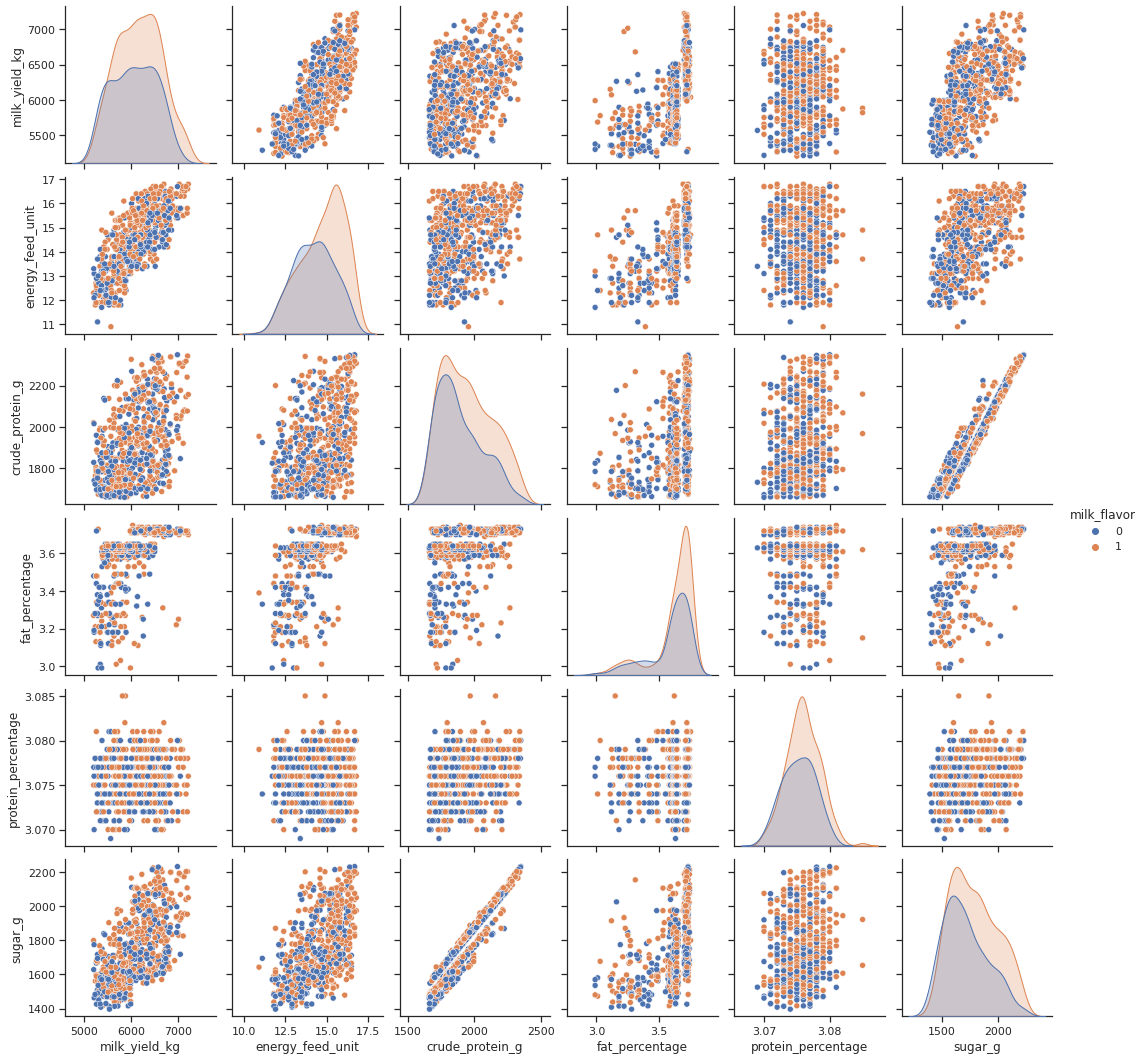

In [105]:
sns.pairplot(ferma_sugar.drop(['id'], axis=1), hue="milk_flavor")
plt.show()

Кажется, такое преобразование  помогло избавиться от мультимодальности в распределении признака. Далее на этапе моделирования проверим поможет ли это улучшить качество получившихся моделей.

Небольшая мультимодальность наблюдается также в распределении значения `fat_percentage`, чтобы избавиться от нее рекомендуется дополнительно проанализировать этот параметр и возможно ввести дополнительные признаки (например, сделать разбивку по различным видам содержащихся жиров или учесть дополнительные параметры, которые влиют на жирность молока). Учитывая, что мультимодальность небольшая и она по сути представлена выбросами в данных (которые возможно придется удалить), то на данный момент оставим этот параметр как есть.

Выведем отдельно (в большем масштабе) графики связи независимых признаков с целевыми параметрами, чтобы определить характер связи.

In [106]:
def scatter_numeric_columns(data, y, hue):
    # Определение числовых столбцов в данных
    numerical_columns = data.select_dtypes(include=[np.number]).columns
    # Выбор столбцов для построения диаграмм рассеяния
    columns_to_plot = numerical_columns.difference([y])

    # Определение количества графиков и строк для макета
    num_plots = len(columns_to_plot)
    num_rows = (num_plots + 1) // 2

    # Создание объектов "fig" и "axes" для графиков
    fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5*num_rows))

    # Построение диаграмм рассеяния для каждой пары столбцов
    for i, column in enumerate(columns_to_plot):
        sns.scatterplot(data=data, x=column, y=y, hue=hue, ax=axes[i // 2, i % 2])
        axes[i // 2, i % 2].set_title(f'Диаграмма рассеяния между {y} и {column}')
        axes[i // 2, i % 2].legend(loc='upper left', bbox_to_anchor=(1, 1), title=column)  # Перемещение легенды за пределы графика

    # Оптимизация макета графиков
    plt.tight_layout()
    # Отображение графиков
    plt.show()

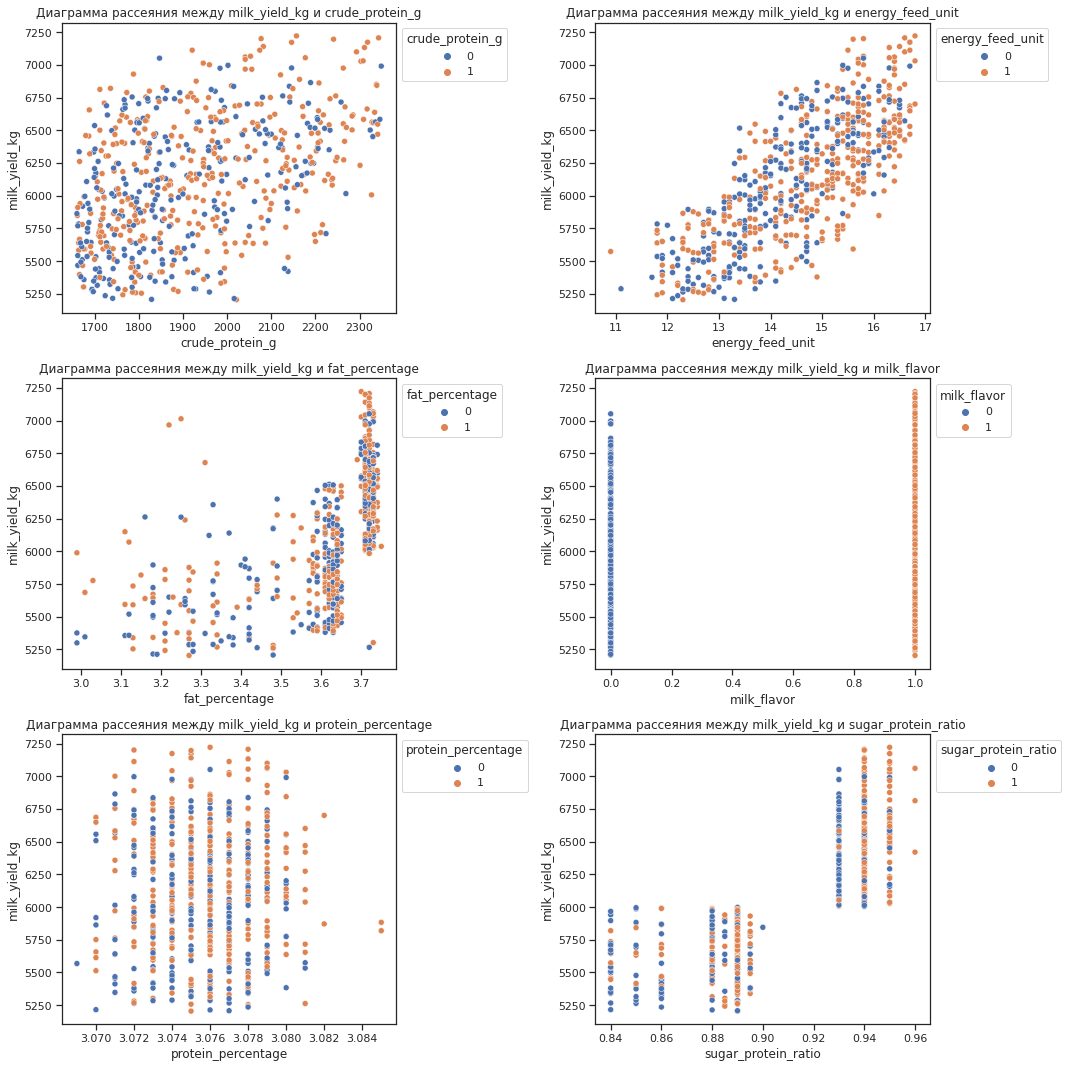

In [107]:
scatter_numeric_columns(ferma.drop('id', axis=1), y='milk_yield_kg', hue='milk_flavor')

- Наблюдаются признаки линейной связи удоя с `crude_protein_g` и `energy_feed_unit`.
- Наблюдаютс признаки нелинейной связи  удоя с `fat_percentage` и `sugar_protein_ratio`. Решим что делать с такой связью позже, когда посмотрим на коэффициенты корреляции.
- Выраженная связь между другими количественными признаками и удоем отсутсвует. 

Построим корреляционную матрицу между всеми признаками в таблице.

In [108]:
# функция для перемещения колонок
def move_columns(data, columns, loc):
    columns_to_move = [data.pop(col) for col in columns]
    for i, col in enumerate(columns):
        data.insert(loc + i, col, columns_to_move[i])
    return data

In [109]:
# для удобства переместим целевые колонки в начало таблицы (после колонки id)
move_columns(ferma, ['milk_flavor'], 2)
move_columns(ferma_sugar, ['milk_flavor'], 2)
ferma.head()

,id,milk_yield_kg,milk_flavor,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,age,dad_name
0,1,5863,1,14.2,1743,0.890,вис бик айдиал,равнинное,айдиал,3.58,3.076,более_2_лет,буйный
1,2,5529,1,12.8,2138,0.890,вис бик айдиал,равнинное,соверин,3.54,3.079,менее_2_лет,соловчик
2,3,5810,0,14.0,1854,0.885,рефлешнсоверинг,холмистое,соверин,3.59,3.074,более_2_лет,барин
3,4,5895,0,12.4,2012,0.885,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,более_2_лет,буйный
4,5,5302,1,12.8,1675,0.885,вис бик айдиал,равнинное,соверин,3.73,3.073,менее_2_лет,барин


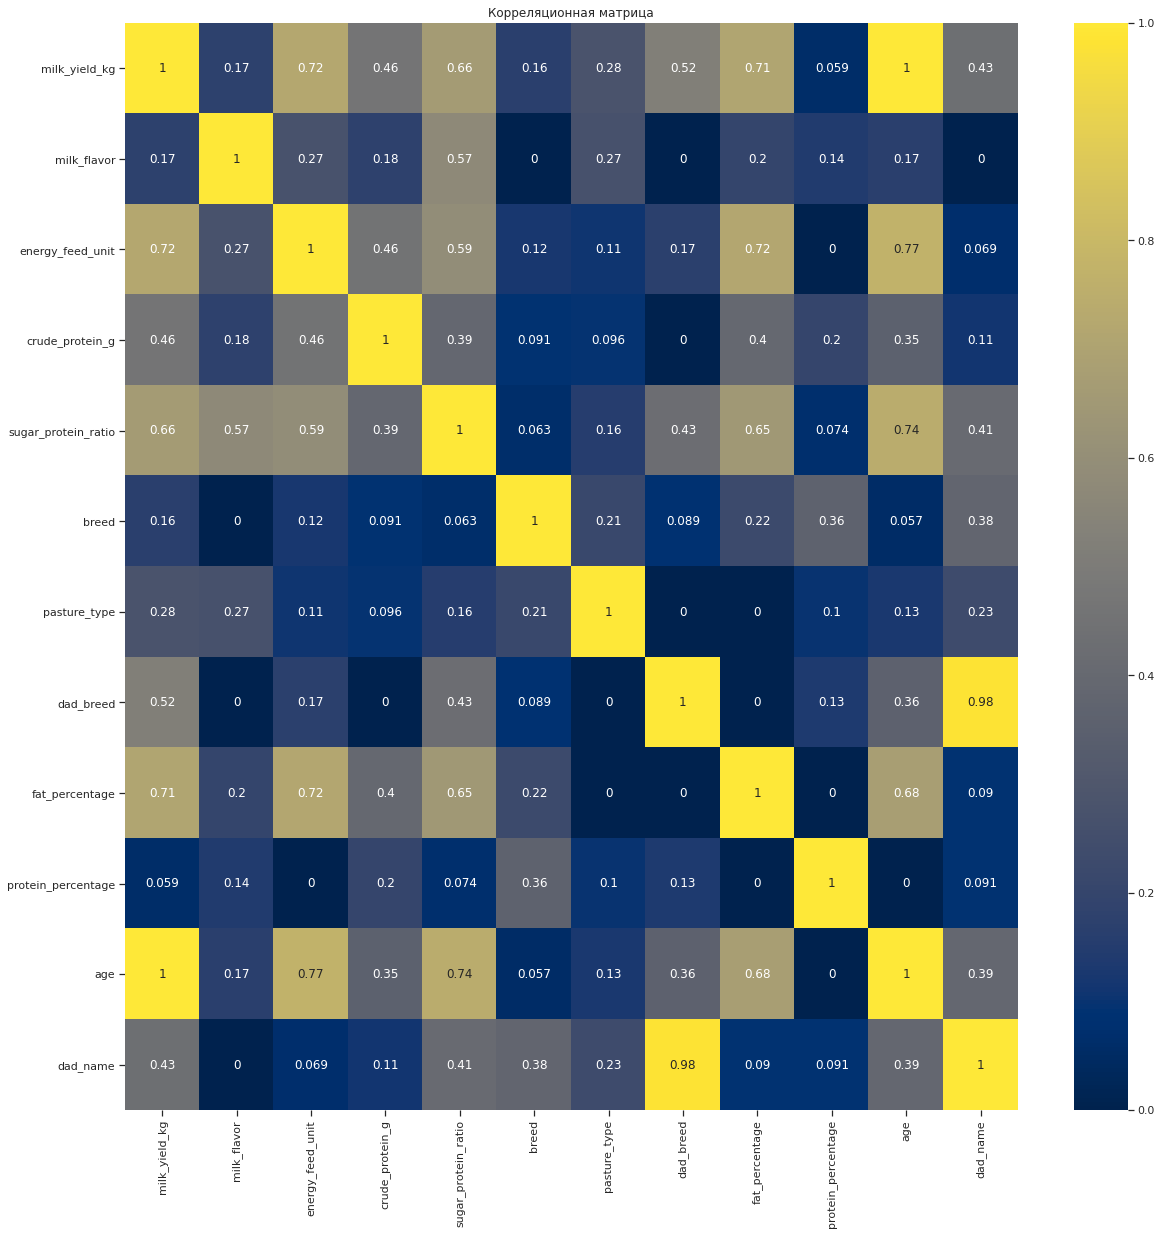

In [110]:
# построим корреляционную матрицу по таблице ferma
plt.figure(figsize=(20, 20)) 
sns.heatmap(ferma
            .drop('id', axis=1)
            .phik_matrix(interval_cols=[
                                        'milk_yield_kg',
                                        'milk_flavor',
                                        'energy_feed_unit',
                                        'crude_protein_g',
                                        'sugar_protein_ratio',
                                        'fat_percentage',
                                        'protein_percentage'
                                       ]
                        ),
            annot=True,
            cmap='cividis'
           )
plt.title("Корреляционная матрица")
plt.show()

**1. Корреляция целевого признака "Удой" (`milk_yield_kg`) с независимыми признаками:**
- *Весьма высокая*: Удой практически на 100% коррелирует с признаком `age`. Взрослые коровы независимо от других характеристик практически всегда дают больше молока чем молодые.
- *Высокая*: Размер удоя имеют сильную положительную связь с `energy_feed_unit` и `fat_percentage`. Связь `fat_percentage` имеет линейный характер, а в связи Удоя с ЭКЕ наблюдаются признаки нелинейности (квадратичной связи).
- *Заметная*: Заметна прямая связь удоя с породой отца коровы (`dad_breed`) и СПО (`sugar_protein_ratio`). 
- *Умеренная* Имеется умеренная прямая корреляция удоя с содержанием сырого протеина (`crude_protein_g`) и именем отца коровы (`dad_name`).

Остальные признаки слабо коррелируют с целевым признаком Удоя.

**2. Корреляция целевого признака "Вкус молока" (`milk_flavor`) с независимыми признаками:**

- *Заметная*: Заметная положительная корреляция наблюдается между вкусом молока и СПО.
Все остальные связи слабые, а связь вкуса молока с породой коровы (`breed`), порододой отца коровы (`dad_breed`) и именем отца коровы (`dad_name`) и вовсе отсутствует.

**3. Мультиколлинеарность независимых признаков:**
- Наблюдается очень сильная мультиколлинеарность признаков `dad_breed` и `dad_name` (коэф=0.98). Для обеспечения лучшей устойчивости модели один из них рекомендуется удалить, чтобы устранить мультиколлинеарность. По таблице корреляции видно, что `dad_breed`(0.52) имеет немного большую связь с целевым признаком `milk_yield_kg`, чем `dad_name` (0.43). Несмотря на это, исследовательский анализ показал, что в рамках одной породы отца, имя отца может достаточно сильно влиять по параметры удоя. К тому же, количество имен отца 4, а количество пород всего 2. Поэтому при выборе потенциальной коровы проще будет восстановить породу по имени отца, чем наоборот. Разница во влиянии на целевой показатель небольшая, поэтому лучше все же оставить в таблице `dad_name` и обучить модель на таких данных.


Наличие прямой связь вкуса молока и удоя с возрастом окровы с возврастом коровы мы предположили на этапе исследовательского анализа. Посмотрим как это отражается на графиках распределения.

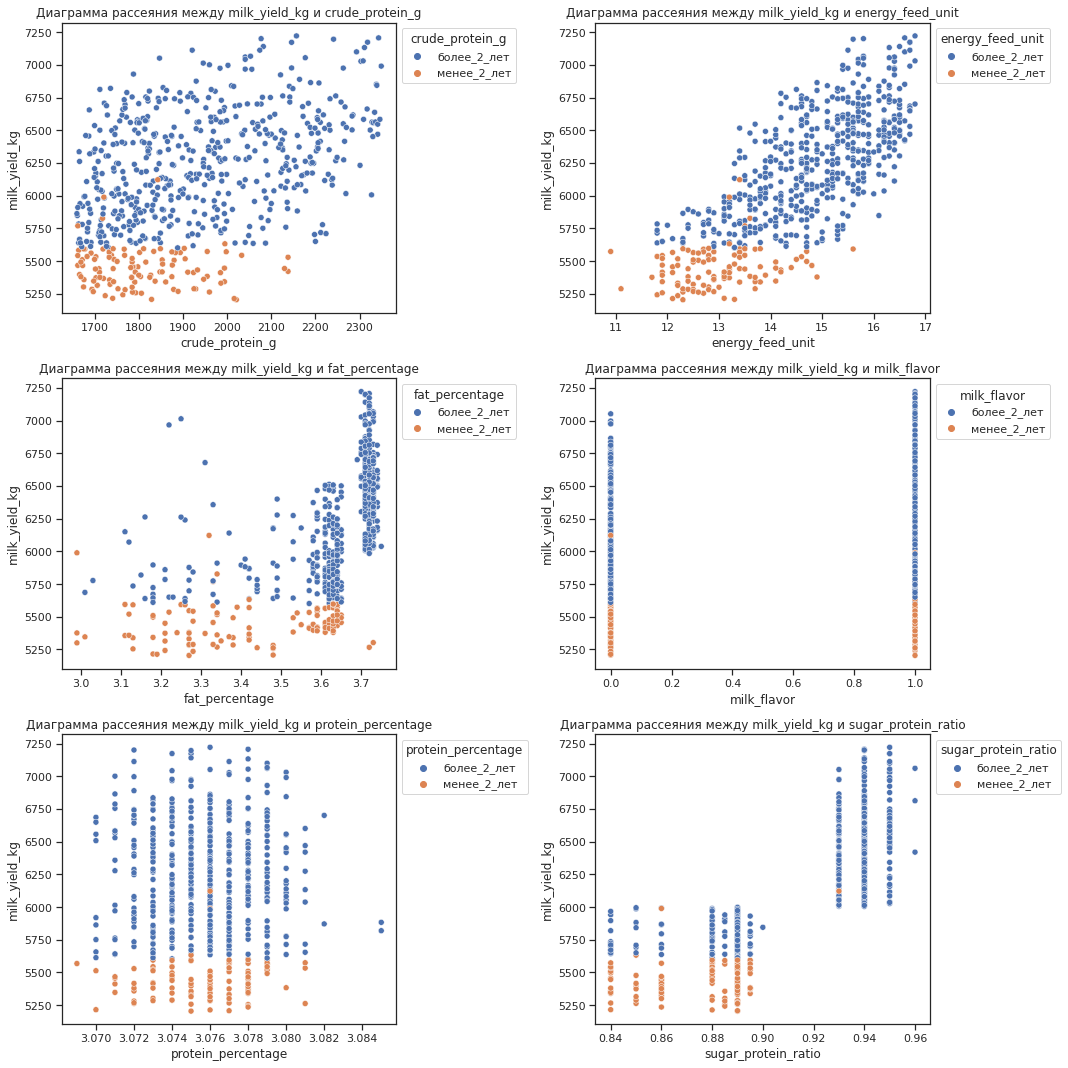

In [111]:
scatter_numeric_columns(ferma.drop('id', axis=1), y='milk_yield_kg', hue='age')

Действительно, на всех графиках заметна четко выраженная граница между количественными показателями молодых и взрослых коров. Очевидно, что добиться целевого показателя удоя в 6000 кг с молодыми коровами сразу после покупки не получится (нужно будет ждать пока они повзрослеют). При этом на вкус молока возраст коровы практически не влияет.

На графике также видно, что молодым коровам не дают корм с высоким СПО, этим также, вероятно, можно объясняться низкий удой. 

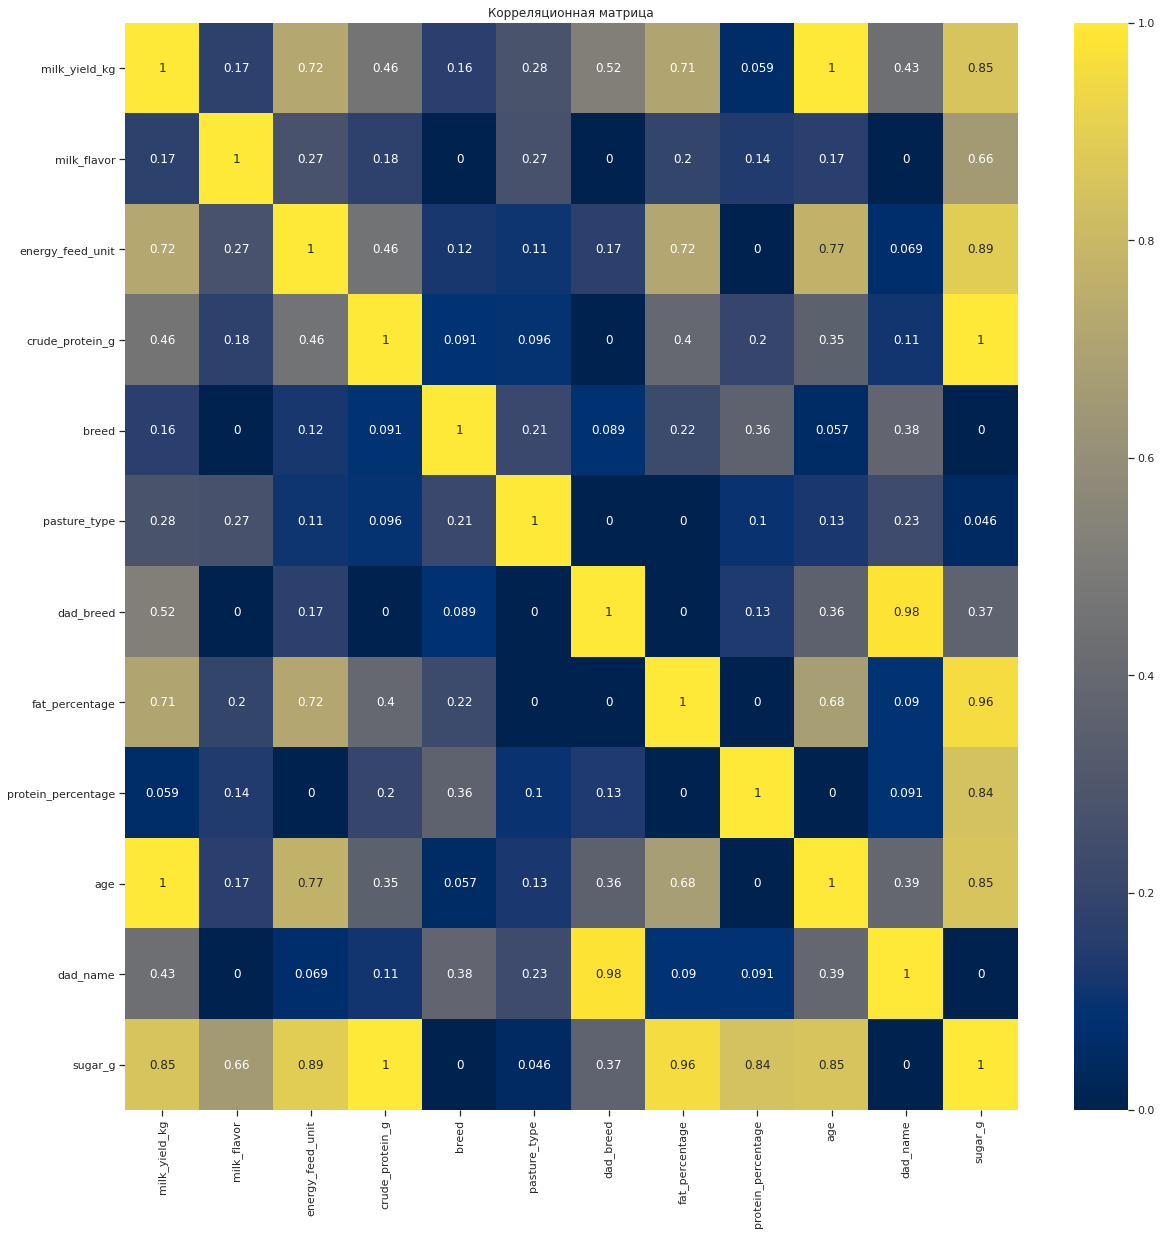

In [112]:
# построим корреляционную матрицу по таблице ferma_sugar
plt.figure(figsize=(20, 20)) 
sns.heatmap(ferma_sugar
            .drop('id', axis=1)
            .phik_matrix(interval_cols=[
                                        'milk_yield_kg',
                                        'milk_flavor',
                                        'energy_feed_unit',
                                        'crude_protein_g',
                                        'sugar_protein_ratio',
                                        'fat_percentage',
                                        'protein_percentage'
                                       ]
                        ),
            annot=True,
            cmap='cividis'
           )
plt.title("Корреляционная матрица")
plt.show()

Корреляция нового признака `sugar_g` на удой практически не поменялась по сравнению с `sugar_protein_ratio`. Все остальные коэффициенты корреляции с удоем также остались практически неизменными. Зато появилась сильная мультиколлинеарность между признаком `sugar_g` и `crude_protein_g`. Причем обе целевые переменные Удой и Вкус молока чуть больше связаны с содержанием сахара в корме, чем с содержание сырого протеина в нем. На диаграмме рассеивания (выше) связи `milk_yield_kg` с `sugar_g` также имеет более выраженный линейный характер, чем аналогичная связь с `crude_protein_g`.

Поэтому для избежания мультиколлинеарности в такой версии модели лучше убрать показатель `crude_protein_g`.

### Выводы

В главе, посвященной корреляционному анализу, были получены следующие выводы:

**1. Распределение данных:**
- Большинство данных в таблице распределено нормально или близко к нормальному, за исключением параметра `sugar_protein_ratio`, который имеет мультимодальное распределение.
- Для устранения мультимодальности параметра `sugar_protein_ratio` предложено разделить его на два отдельных признака или категоризировать. В результате таких преобразований возможно избавиться от нелинейной связи. Посмотрим далее какой из предложенных методов даст лучшее качество модели.

**2. Связь признаков с целевыми показателями:**
- Наблюдаются линейные связи удоя с `crude_protein_g` и `energy_feed_unit`.
- Нелинейные связи удоя с `fat_percentage` и `sugar_protein_ratio` требуют дополнительной обработки данных.
- Влияние других количественных признаков на удой незначительно.
- Вкус молока коррелирует с `sugar_protein_ratio`, остальные связи слабые.

**3. Мультиколлинеарность и удаление признаков:**
- Выявлена сильная мультиколлинеарность между `dad_breed` и `dad_name`, рекомендовано удалить один из них.
- После анализа влияния возраста коровы на удой и вкус молока, выяснено, что возраст влияет на удой, но не на вкус молока.

**4. Новые признаки и модель:**
- Введение нового признака `sugar_g` не привело к значительным изменениям в корреляции с удоем, однако его распределение стало близки к нормальному.
- При этом появилась сильная мультиколлинеарность между новым признаком `sugar_g` и `crude_protein_g`, что подталкивает к удалению `crude_protein_g` из модели.

Итак, в результате анализа выделены ключевые связи между признаками и целевыми переменными, предложены меры по улучшению модели за счет удаления некоторых признаков для избежания мультиколлинеарности.

## Обучение модели линейной регрессии

### Факторы влияющие на удой

Для модели, предсказывающей удой коровы, следует выбрать признаки, которые могут влиять на производительность животного. Из представленных данных можно выделить следующие признаки:

1. Особенности коровы:
- `age` ("Возраст"): Возраст коровы может также влиять на удой, поэтому этот признак следует учитывать при построении модели.
- `breed` ("Порода"), `dad_breed` ("Порода папы коровы"), `dad_name` ("Имя папы коровы"): Генетика играет важную роль в производительности животного, поэтому информация о породе коровы, породе отца и имени отца коровы может быть полезной для модели.

2. Параметры корма коровы:
- `energy_feed_unit` ("ЭКЕ (Энергетическая кормовая единица)"): Питательность корма является важным фактором, который может влиять на удой коровы. Более питательные корма могут способствовать повышению производительности.
- `crude_protein_g` ("Сырой протеин, г"): Содержание протеина в корме также влияет на производительность животного, поскольку протеин необходим для роста и развития.
- `sugar_protein_ratio` ("СПО (Сахаро-протеиновое соотношение)"): Соотношение сахара к протеину в корме может также оказать влияние на удой коровы, поскольку это связано с общим питательным балансом.

3. Тип пастбища:
- `pasture_type` - Различные типы пастбищ могут предоставлять различные качественные и количественные характеристики пищи для коров, климатические особенности, что в свою очередь может отразиться на их производительности.

Между параметрами молока и размером удоя прямые причинно-следственные связи отсутствуют. Жирность и содержание протеинов в молоке могут производными от породы коровы, особенностей ее корма и условий, в которых она паслась, но они никак не влияют на удой.

Таким образом, выбранные признаки имеют потенциальное причинно-следственное влияние на производительность коровы и могут быть полезны для построения модели, предсказывающей удой.

### Подготовка данных и построение базовой модели

In [113]:
# Функция для подготовки данных к машинному обучению
def preprocess_test_data(data, target, variables, scaler=StandardScaler()):
    
    # индекс не влияет на размер удоя, сделаем его индексом таблицы
    try:
        data = data.set_index('id')
    except:
        pass
    
    # создание таблицы, содержащей только ценелевой и входные признаки
    data = data[variables + [target]]
    
    # определение типа каждого столбца и добавление его в соответствующий список
    cat_col_names = [col for col in data.columns if data[col].dtype == 'object' and col != target]
    num_col_names = [col for col in data.columns if data[col].dtype != 'object' and col != target]
        
    # создание константы RANDOM_STATE
    RANDOM_STATE = 42
    
    # разделение данных на обучающую и тестовую выборки
    X = data.drop(target, axis=1)
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=RANDOM_STATE
    )
        
    # масштабирование выборки
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])
    
    # кодирование категориальных признаков
    encoder = OneHotEncoder(drop='first', sparse=False)
    
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])
    encoder_col_names = encoder.get_feature_names()
    
    # создание тренировочного и тестового датафреймов из закодированных и отмасштабированных данных
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)
    
    # объединение всех преобразованных данных в тренировочный и тестовый датафреймы
    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
    return X_train, X_test, y_train, y_test, num_col_names, cat_col_names, target, scaler, encoder

In [114]:
# одновременно добавим функцию для подгоовки реальных данных, которые мы будем предсказывать позже
def preprocess_real_data(X_real, num_col_names, cat_col_names, scaler, encoder):
    try:
        # индекс не влияет на размер удоя, сделаем его индексом таблицы
        X_real = X_real.set_index('id')
    except:
        pass
    
    # масштабирование выборки
    X_real_scaled = scaler.transform(X_real[num_col_names])
    # кодирование категориальных признаков
    X_real_ohe = encoder.transform(X_real[cat_col_names])
    encoder_col_names = encoder.get_feature_names()
    
    # объединение всех преобразованных данных в тренировочный и тестовый датафреймы
    X_real_scaled = pd.DataFrame(X_real_scaled, columns=num_col_names)
    X_real_ohe = pd.DataFrame(X_real_ohe, columns=encoder_col_names)
    X_real = pd.concat([X_real_ohe, X_real_scaled], axis=1)
    
    return X_real

In [115]:
# обработаем тестовые данные с помощью функции и сохраним результаты в соответствующие переменные
X_train, X_test, y_train, y_test, num_col_names, cat_col_names, target, scaler, encoder = preprocess_test_data(
    data=ferma_main,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit',
        'crude_protein_g',
        'sugar_protein_ratio',
        'age',
        'breed',
        'dad_breed',
        'pasture_type'
    ],
)

# проверка подготовленных таблиц
print(f'Количественные признаки: {num_col_names}')
print(f'Категориальные признаки: {cat_col_names}')
print(f'Целевой признак: {target}')

print(f' Форма X_train: {X_train.shape}')
print(f' Форма y_test: {y_test.shape}')
print(f' Форма X_test: {X_test.shape}')
print(f' Форма y_train: {y_train.shape}')


display(X_train.head(), X_test.head(), y_train.head(), y_test.head())

Количественные признаки: ['energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio']
Категориальные признаки: ['age', 'breed', 'dad_breed', 'pasture_type']
Целевой признак: milk_yield_kg
 Форма X_train: (471, 7)
 Форма y_test: (157,)
 Форма X_test: (157, 7)
 Форма y_train: (471,)


,x0_менее_2_лет,x1_рефлешнсоверинг,x2_соверин,x3_холмистое,energy_feed_unit,crude_protein_g,sugar_protein_ratio
0,0.0,1.0,1.0,1.0,1.502378,1.079523,0.837130
1,1.0,1.0,1.0,1.0,-1.557270,-0.196920,-0.703660
2,0.0,0.0,0.0,0.0,0.125537,-1.386085,-1.011818
3,0.0,0.0,0.0,1.0,-0.103937,0.752230,0.837130
4,0.0,0.0,0.0,0.0,-1.098323,0.828598,-0.703660


,x0_менее_2_лет,x1_рефлешнсоверинг,x2_соверин,x3_холмистое,energy_feed_unit,crude_protein_g,sugar_protein_ratio
0,0.0,0.0,0.0,1.0,-0.486393,-0.813322,-1.011818
1,0.0,1.0,1.0,1.0,1.425887,0.026730,0.837130
2,1.0,1.0,1.0,1.0,-0.486393,-0.682405,-1.628134
3,0.0,0.0,1.0,0.0,-0.945340,-1.058792,-1.011818
4,0.0,0.0,1.0,1.0,0.584484,-1.413360,-0.703660


id
509    6498
384    5268
588    5610
198    6343
329    5833
Name: milk_yield_kg, dtype: int64

id
583    5980
593    6512
552    5392
215    5604
487    5667
Name: milk_yield_kg, dtype: int64

Обработка тестовых данных прошла успешно.

In [116]:
# Функция для построения графиков по количественным признакам тренировочного датасета
# гистограмму частотности распределения и ящик с усами.
def plot_num_features_distribution(X_train=X_train, num_col_names=num_col_names, bins=10):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    
    ax_hist = X_train[num_col_names].plot(kind='hist', bins=bins, ax=axes[0])
    ax_hist.set_title('Гистограмма распределения')
    
    ax_box = X_train[num_col_names].plot(kind='box', ax=axes[1], rot=45)
    ax_box.set_title('Разброс значений признаков')
    
    # Перемещаем легенду за пределы графика
    ax_hist.legend().set_visible(False)  # Скрываем легенду на самом графике
    ax_hist.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Помещаем легенду вне графика
    
    plt.tight_layout()  # Автоматическая настройка расположения элементов графика
    
    plt.show()

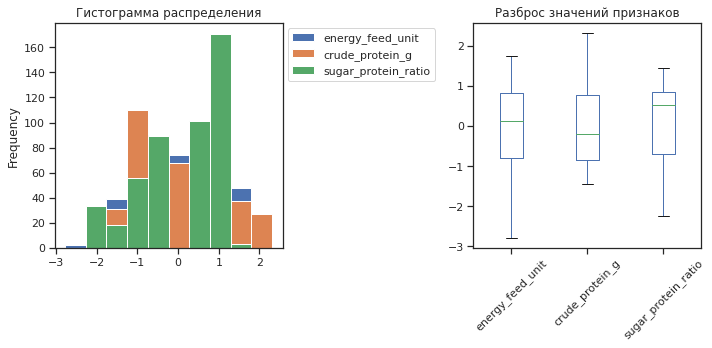

In [117]:
# проверка распределения данных после масштабирования числовых признаков
plot_num_features_distribution(X_train, num_col_names)

Корректность масштабирования также подтверждается графиками распределения получившихся значений. После стандартизации у признаков средние значение находятся в районе 0, а диапазон варьируется на ±3 стандартных отклонения.

In [118]:
# Функция для обучения модели линейной регрессии на подготовленных данных и применение ее к тестовой выборке
# Вывод основных метрик получившейся модели
def linear_model_and_predictions(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, X_real=None, model=LinearRegression()):
    # Обучение модели
    model.fit(X_train, y_train)
    
    # Предсказание на тестовых данных
    test_predictions = model.predict(X_test)
    
    # Оценка на тестовых данных
    r2 = r2_score(y_test, test_predictions)
    mse = mean_squared_error(y_test, test_predictions)
    rmse = mean_squared_error(y_test, test_predictions, squared=False)
    mae = mean_absolute_error(y_test, test_predictions)
    
    # Вывод оценок
    print("R2 LinearRegression =", round(r2, 4))
    print(f'MSE = {mse:.0f}')
    print(f'RMSE = {rmse:.0f}')
    print(f'MAE = {mae:.0f}')
    print()
    
    # Отразим коэффициенты модели линейной регрессии:
    for feature_name, weight in zip(X_train.columns, model.coef_):
        print(f"{feature_name:<20}: {weight:+.6f}")
    
    
    # Предсказание на реальных данных
    real_predictions = model.predict(X_real) if X_real is not None else None
    
    return model, test_predictions, real_predictions, r2, mse, rmse, mae

In [119]:
# обучения выбранной модели машинного обучения и предсказания данных на тестовой выборке,
# сохранение результатов в соответствующие переменные
# вывод основных метрик по результатам работы можели
model, test_predictions, real_predictions, r2, mse, rmse, mae = linear_model_and_predictions()

R2 LinearRegression = 0.7844
MSE = 43887
RMSE = 209
MAE = 164

x0_менее_2_лет      : -237.101221
x1_рефлешнсоверинг  : -1.006906
x2_соверин          : -240.316969
x3_холмистое        : +50.992039
energy_feed_unit    : +156.863493
crude_protein_g     : +50.601347
sugar_protein_ratio : +162.478018


Качество базовой модели:

- **R2 (коэффициент детерминации) = 0.7844:** Этот показатель указывает на то, насколько хорошо модель соответствует данным. Значение 0.7844 означает, что примерно 78.44% изменчивости удоя коровы можно объяснить используемой моделью. Чем ближе значение R2 к 1, тем лучше модель объясняет данные.

- **MSE (среднеквадратичная ошибка) = 43887:** Это мера средней ошибки квадрата между прогнозами модели и фактическими значениями. Чем ниже значение MSE, тем лучше модель соответствует данным. В данном случае ошибка составляет 43887 квадратных килограммов.
- **RMSE (квадратный корень из среднеквадратичной ошибки) = 209:** RMSE представляет собой квадратный корень из MSE и измеряет среднюю ошибку прогнозов в тех же единицах, что и целевая переменная. Значение 209 указывает на то, что средняя ошибка прогнозов составляет 209 кг.

- **MAE (средняя абсолютная ошибка) = 164:** MAE представляет собой среднюю абсолютную разницу между прогнозами модели и фактическими значениями. Значение 164 означает, что модель в среднем ошибается на 164 кг при прогнозировании удоя коровы.

Исходя из этих показателей, модель линейной регрессии, предсказывающая удой коровы в фермерском хозяйстве, имеет относительно высокий коэффициент детерминации (R2), что говорит о том, что она в значительной степени объясняет изменчивость удоя коровы. Однако средняя ошибка прогнозов (MAE и RMSE) в 164 кг и 209 кг соответственно указывает на то, что модель может быть дальше улучшена для более точных прогнозов.

Оценим остатки модели с использованием графиков.

In [120]:
# функция для построения графика остатков
def plot_residuals(y_true=y_test, y_pred=test_predictions):
    residuals = y_true - y_pred
    
    # Рисуем график остатков
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.residplot(x=y_pred, y=residuals, lowess=True, color="b")
    plt.title('График остатков')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.grid(True)
    
    # Рисуем гистограмму остатков
    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True, color="b")
    plt.title('Гистограмма остатков')
    plt.xlabel('Остатки')
    plt.ylabel('Частота')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [121]:
def plot_residuals(y_true=y_test, y_pred=test_predictions):
    residuals = y_true - y_pred
    
    # Рисуем график остатков
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.residplot(x=y_pred, y=residuals, lowess=True, color="b")
    
    # Добавляем вертикальные линии для среднего и медианы остатков
    plt.axhline(y=residuals.mean(), color='r', linestyle='--', label='Среднее остатков')
    plt.axhline(y=residuals.median(), color='r', linestyle='-', label='Медиана остатков')
    
    plt.title('График остатков')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.legend()
    plt.grid(True)
    
    # Рисуем гистограмму остатков
    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True, color="b")
    
    # Добавляем вертикальные линии для среднего и медианы остатков
    plt.axvline(x=residuals.mean(), color='r', linestyle='-', label='Среднее остатков')
    plt.axvline(x=residuals.median(), color='r', linestyle='--', label='Медиана остатков')
    
    plt.title('Гистограмма остатков')
    plt.xlabel('Остатки')
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


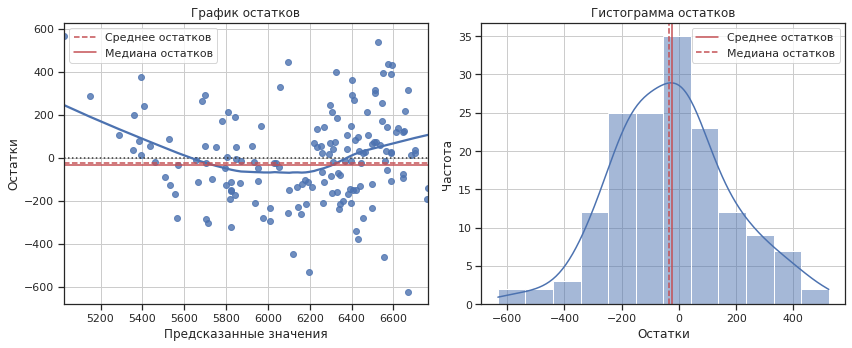

In [122]:
plot_residuals()

Распределение остатков:
- На графике остатков видно, что остатки распределены неравномерно вокруг нуля по предсказанным значениям.
- Существует некоторая кривизна на графике, что может указывать на нелинейную связь между предсказанными и фактическими значениями.
- Гистограмма остатков показывает, что распределение остатка близко к нормальному.
- Однако, есть небольшие асимметрии и выбросы, что может указывать на существование некоторых наблюдений, которые плохо объясняются моделью.

Смещение графика остатков:
- Среднее значение остатков (пунктирная линия) приблизительно равно нулю, что является хорошим признаком. Это говорит о том, что модель в среднем не смещена.
- Однако, синяя линия, представляющая локальное среднее остатков, показывает наличие систематического смещения в зависимости от уровня предсказанных значений. Это может свидетельствовать о том, что модель не полностью захватывает все паттерны в данных.
- Среднее и медиана остатков (обозначены красной и пунктирной линиями соответственно) примерно совпадают и находятся около нуля. Это еще раз подтверждает, что модель в среднем не смещена.

Таким образом, базовая линейная модель в среднем не смещена, но требует улучшений для более точного предсказания удоев коров.

In [123]:
# Полностью собранная вместе модель, включает:
    # обработку тестовых и реальных данные (если есть),
    # обучение модели,
    # получение предсказаний на основе тестовой и реальной выборки, расчет метрик
    # анализ распределения признаков и остатков,
    # добавление реальных предсказаний в первоначальный датасет
def full_linear_model(data, target, variables, X_real=None, model=LinearRegression(), scaler=StandardScaler()):
    
    # Скопируем первоначальную таблицу в отдельную переменную, чтобы потом добавить туда предсказанный целевой признак
    X_real_init = X_real.copy() if X_real is not None else None

    # Предварительная обработка тестовых данных
    # Разделяем данные на тренировочную и тестовую выборки, масштабируем количественные признаки и кодируем категориальные признаки
    X_train, X_test, y_train, y_test, num_col_names, cat_col_names, target, scaler, encoder = preprocess_test_data(data, target, variables, scaler)
    
    # Построение графика распределения количественных признаков
    plot_num_features_distribution(X_train, num_col_names, bins=10)
    
    if X_real is not None:
        # Предварительная обработка реальных данных
        # Масштабируем количественные признаки и кодируем категориальные признаки для реальных данных
        X_real = preprocess_real_data(X_real, num_col_names, cat_col_names, scaler, encoder)
        
    # Обучение модели и оценка результатов
    # Обучаем модель на тренировочных данных и получаем предсказания на тестовых и реальных данных
    # Рассчитываем метрики качества модели (R2, MSE, RMSE, MAE)
    model, test_predictions, real_predictions, r2, mse, rmse, mae = linear_model_and_predictions(X_train, y_train, X_test, y_test, X_real, model=model)
    
    # Построение графика распределения остатков на тестовых данных
    plot_residuals(y_true=y_test, y_pred=test_predictions)
    
    # Преобразуем предсказания на реальных данных в DataFrame
    y_real = pd.DataFrame(real_predictions, columns=[target+'_predicted']) if X_real_init is not None else None
    
    # Объединяем первоначальные реальные данные с предсказанными значениями целевой переменной
    final_real = pd.merge(X_real_init, y_real, left_index=True, right_index=True, how='left') if X_real_init is not None else None
    
    # Возвращаем результаты
    if X_real_init is not None:
        return X_real, y_real, final_real

### Модели линейной регрессии

#### Модель 1 (базовая):

Еще раз построим базовую модель и проверим работу функции.

**Модель 1 (базовая):**
- *Исходные данные*:
`ferma_main`
- *Целевая переменная*: 
`milk_yield_kg`
- *Входные признаки*:
 - `energy_feed_unit`,
 - `crude_protein_g'`,
 - `sugar_protein_ratio`,
 - `age`,
 - `breed`,
 - `dad_breed`,
 - `pasture_type`

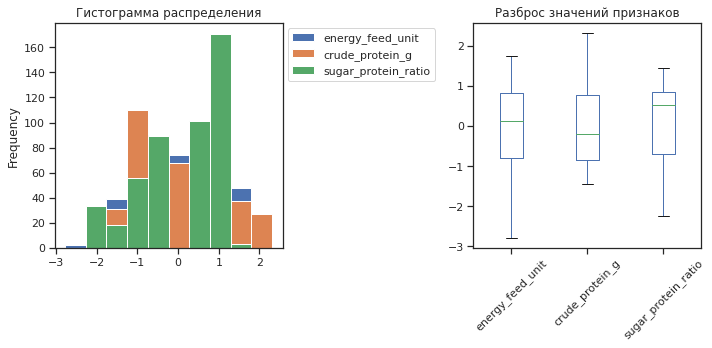

R2 LinearRegression = 0.7844
MSE = 43887
RMSE = 209
MAE = 164

x0_менее_2_лет      : -237.101221
x1_рефлешнсоверинг  : -1.006906
x2_соверин          : -240.316969
x3_холмистое        : +50.992039
energy_feed_unit    : +156.863493
crude_protein_g     : +50.601347
sugar_protein_ratio : +162.478018


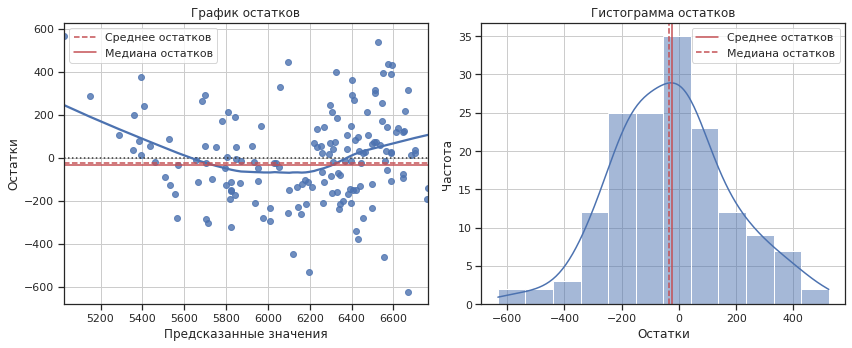

In [124]:
# еще раз построит базовую модель
full_linear_model(
    data=ferma_main,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit',
        'crude_protein_g',
        'sugar_protein_ratio',
        'age',
        'breed',
        'dad_breed',
        'pasture_type'
    ],)

Функция работает корректно.

#### Модель 2 (устранение нелинейности)

Построим модель линейной регрессии с учётом преобразования признаков, нелинейно связанных с целевым признаком.
- Графики показывают, что `СПО` и `Удой` связаны нелинейно. Попробуем исключить нелинейность: переведем `СПО` в категориальный признак, выявив и использовав границу нелинейности.
- `ЭКЕ` и `Удой` также связаны нелинейно. Исключим нелинейность: введим новый признак «ЭКЕ в квадрате».

На этапе исследовательского анализа, мы уже отмечали, что для того чтобы удой коровы составлял выше 6000кг, показатель СПО должен быть не менее 0.92. Еще раз выведем график распределения.

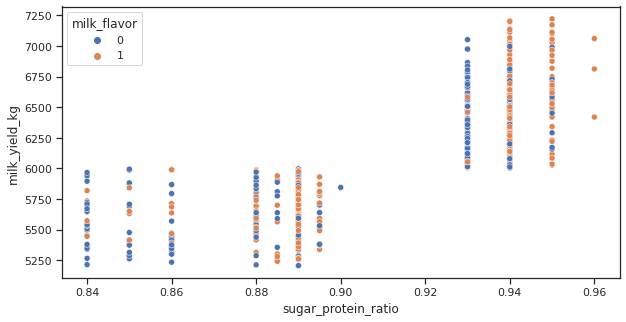

In [125]:
plt.figure(figsize=(10, 5))  # Указываем размер графика
sns.scatterplot(data=ferma, x='sugar_protein_ratio', y='milk_yield_kg', hue='milk_flavor')
plt.legend(title='milk_flavor')
plt.show()

Переведем показатель `sugar_protein_ratio` в категориальный признак, используя пограничное значение 0.92:

- при СПО >= 0.92 проставим значение "высокое";
- при СПО < 0.92 присвоим значение "низкое"

In [126]:
# создадим копию датасета для обучения второй модели
ferma_main_v2 = ferma_main.copy()
# преобразуем показатель СПО
ferma_main_v2['sugar_protein_ratio'] = ferma_main_v2['sugar_protein_ratio'].apply(lambda x: 'высокое' if x >= 0.92 else 'низкое')
ferma_main_v2.sample(5)

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age
77,78,5871,14.7,1795,низкое,вис бик айдиал,равнинное,айдиал,3.61,3.082,вкусно,более_2_лет
440,441,6118,15.1,1920,высокое,вис бик айдиал,холмистое,соверин,3.72,3.078,вкусно,более_2_лет
395,396,6320,15.0,1689,высокое,вис бик айдиал,равнинное,айдиал,3.73,3.074,вкусно,более_2_лет
527,528,6890,15.9,2164,высокое,рефлешнсоверинг,холмистое,айдиал,3.72,3.072,вкусно,более_2_лет
75,76,5281,12.8,1769,низкое,рефлешнсоверинг,холмистое,айдиал,3.48,3.072,вкусно,менее_2_лет


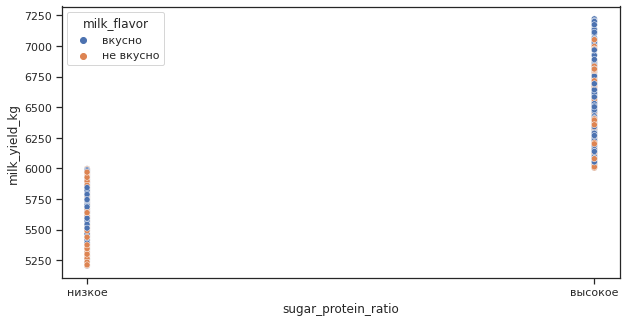

In [127]:
# проверим распределение
plt.figure(figsize=(10, 5))  # Указываем размер графика
sns.scatterplot(data=ferma_main_v2, x='sugar_protein_ratio', y='milk_yield_kg', hue='milk_flavor')
plt.legend(title='milk_flavor')
plt.show()

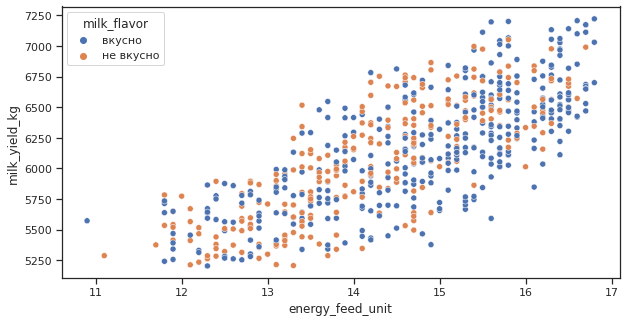

In [128]:
plt.figure(figsize=(10, 5))  # Указываем размер графика
sns.scatterplot(data=ferma_main_v2, x='energy_feed_unit', y='milk_yield_kg', hue='milk_flavor')
plt.legend(title='milk_flavor')
plt.show()

In [129]:
ferma_main_v2.columns

Index(['id', 'milk_yield_kg', 'energy_feed_unit', 'crude_protein_g',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'dad_breed',
       'fat_percentage', 'protein_percentage', 'milk_flavor', 'age'],
      dtype='object')

In [130]:
# преобразуем показатель ЭКЕ
ferma_main_v2['energy_feed_unit_squared'] = ferma_main_v2['energy_feed_unit'] ** 2
ferma_main_v2.sample(5)

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age,energy_feed_unit_squared
180,181,5367,13.1,1720,низкое,вис бик айдиал,равнинное,соверин,3.42,3.072,не вкусно,менее_2_лет,171.61
559,560,5764,13.8,2051,низкое,рефлешнсоверинг,холмистое,соверин,3.63,3.074,не вкусно,более_2_лет,190.44
289,290,5284,12.4,1694,низкое,вис бик айдиал,холмистое,соверин,3.38,3.073,не вкусно,менее_2_лет,153.76
471,472,5883,14.9,2159,низкое,вис бик айдиал,равнинное,соверин,3.62,3.085,вкусно,более_2_лет,222.01
106,107,5417,13.2,1848,низкое,вис бик айдиал,холмистое,соверин,3.57,3.076,вкусно,менее_2_лет,174.24


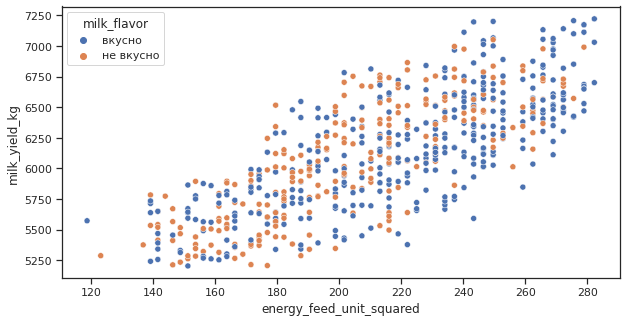

In [131]:
plt.figure(figsize=(10, 5))  # Указываем размер графика
sns.scatterplot(data=ferma_main_v2, x='energy_feed_unit_squared', y='milk_yield_kg', hue='milk_flavor')
plt.legend(title='milk_flavor')
plt.show()

Построим модель 2 с учетом избавления от нелинейности признаков:

**Модель 2 (устранение нелинейности):**
- *Исходные данные*:
`ferma_main_v2` - ЭКЕ возведен в квадрат, а СПО преобразовано в категориальный признак (граница 0.92)
- *Целевая переменная*: 
`milk_yield_kg`
- *Входные признаки*:
 - `energy_feed_unit_squared`, (вместо `energy_feed_unit` в Модели 1)
 - `crude_protein_g'`,
 - `sugar_protein_ratio`, (категориальный признак)
 - `age`,
 - `breed`,
 - `dad_breed`,
 - `pasture_type`

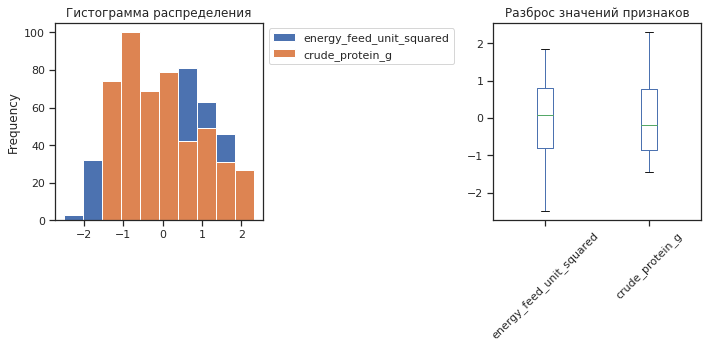

R2 LinearRegression = 0.8181
MSE = 37031
RMSE = 192
MAE = 149

x0_низкое           : -377.120436
x1_менее_2_лет      : -224.709410
x2_рефлешнсоверинг  : +4.399432
x3_соверин          : -211.463067
x4_холмистое        : +32.637849
energy_feed_unit_squared: +154.179906
crude_protein_g     : +49.131219


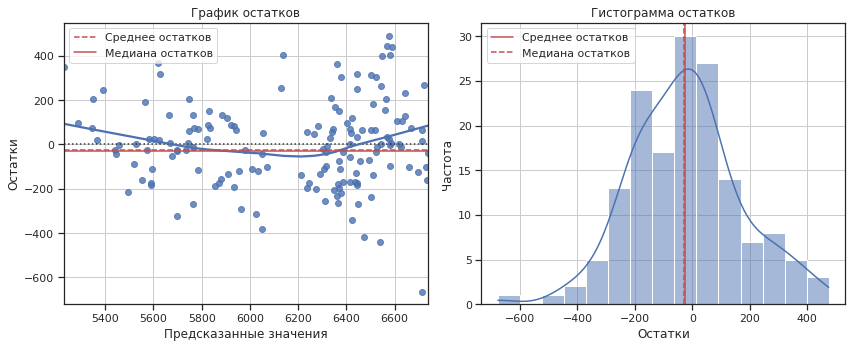

In [132]:
# построим Модель 2 линейной регрессии
full_linear_model(
    data=ferma_main_v2,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'age',
        'breed',
        'dad_breed',
        'pasture_type'
    ],)

Исходя из сравнения метрик, Модель 2 демонстрирует лучшее качество предсказаний по сравнению с Моделью 1:
- Модель 2 имеет более высокий коэффициент детерминации, более низкие значения MSE, RMSE и MAE, что свидетельствует о ее лучшей способности объяснить данные и делать более точные прогнозы.
- Распределение остатков столо более равномерным;
- Медиана стала практически совпадать со средним, однако они по прежнему немного смещены влево, а значит модель в среднем немного завышает покатели удоя.

Попробуем еще улучшить модель.

#### Модель 3 (учет `dad_name`)

Построим модель линейной регрессии с учётом нового признака из таблицы ferma_dad. Учтем преобразование нелинейности в Модели 2 выше.

In [133]:
# объединим таблицы и сохраним их в новую переменную
ferma_main_v3 = pd.merge(ferma_main_v2, ferma_dad, on='id')

In [134]:
ferma_main_v3.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age,energy_feed_unit_squared,dad_name
0,1,5863,14.2,1743,низкое,вис бик айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,201.64,буйный
1,2,5529,12.8,2138,низкое,вис бик айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,163.84,соловчик
2,3,5810,14.0,1854,низкое,рефлешнсоверинг,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,196.00,барин
3,4,5895,12.4,2012,низкое,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,153.76,буйный
4,5,5302,12.8,1675,низкое,вис бик айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,163.84,барин


Построим модель 3 с учетом добавления нового признака.

**Модель 3 (учет `dad_name`):**
- *Исходные данные*:
`ferma_main_v3` - преобразования нелинейности СПО и ЭКЕ сохранены, добавлен признак dad_name из соответствующей таблицы.
- *Целевая переменная*: 
`milk_yield_kg`
- *Входные признаки*:
 - `energy_feed_unit_squared`, (вместо `energy_feed_unit` в Модели 1)
 - `crude_protein_g'`,
 - `sugar_protein_ratio`, (категориальный признак)
 - `age`,
 - `breed`,
 - `dad_breed`,
 - `dad_name`, (новый признак)
 - `pasture_type`

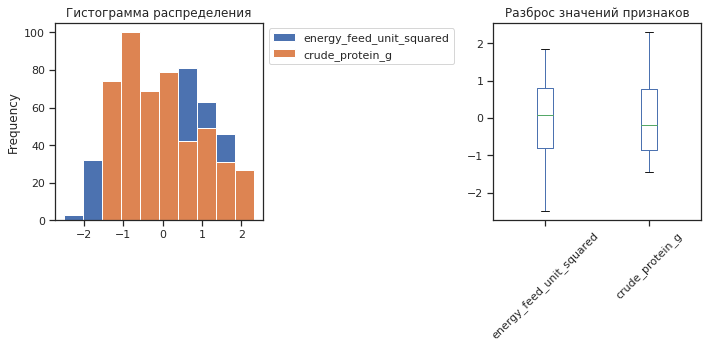

R2 LinearRegression = 0.8248
MSE = 35674
RMSE = 189
MAE = 146

x0_низкое           : -353.779829
x1_менее_2_лет      : -192.548709
x2_рефлешнсоверинг  : +14.919634
x3_соверин          : +44.033305
x4_буйный           : +302.179596
x4_геркулес         : +333.929151
x4_соловчик         : +24.684409
x5_холмистое        : +50.943310
energy_feed_unit_squared: +162.387792
crude_protein_g     : +52.035317


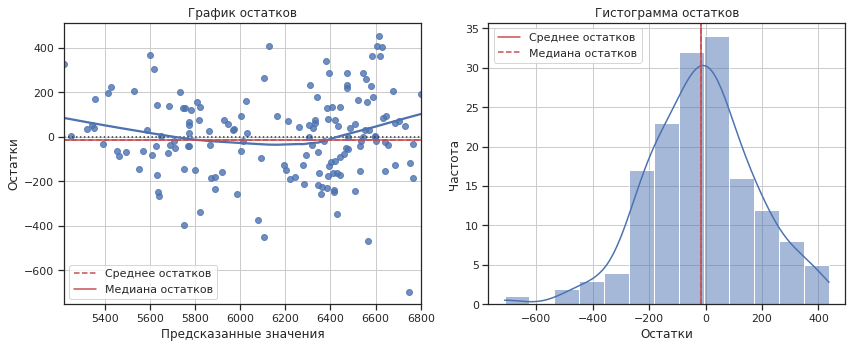

In [135]:
# построим модель линейной регрессии
full_linear_model(
    data=ferma_main_v3,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'age',
        'breed',
        'dad_breed',
        'dad_name', # новый признак
        'pasture_type'
    ],)

Качество модели еще немного улучшилось (выше R2, ниже метрики ошибок). Распределение остатков также стало более равномерным, а их смещение относительно 0 практически устранено. 

Ранее корреляционный анализ показывал мультиколлинеарность между `dad_name` и `dad_breed`. Также ранее мы заключили, что из двух переменных лучше оставить `dad_name`, чем `dad_breed`. Посмотрим, улучшит ли это качество Модели 3.

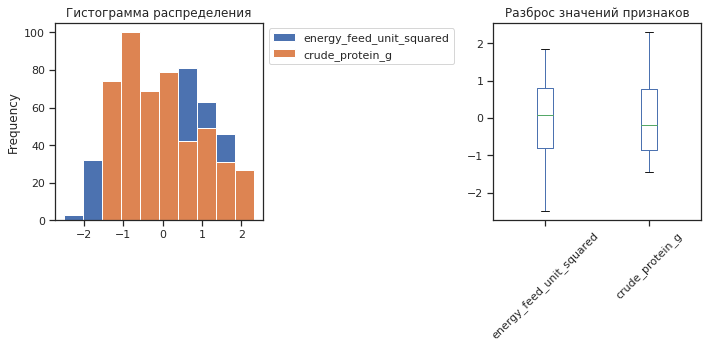

R2 LinearRegression = 0.8265
MSE = 35316
RMSE = 188
MAE = 145

x0_низкое           : -352.575541
x1_менее_2_лет      : -194.015429
x2_рефлешнсоверинг  : +14.738282
x3_буйный           : +261.888581
x3_геркулес         : +293.042604
x3_соловчик         : +23.443140
x4_холмистое        : +48.999099
energy_feed_unit_squared: +162.347321
crude_protein_g     : +52.144918


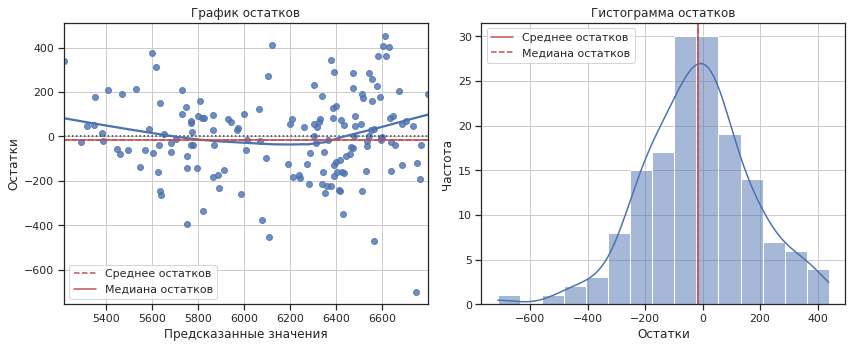

In [136]:
# еще раз выведем основные характеристики базовой модели, построенной в предыдущем пункте
# заодно проверим работу функции
# построим модель линейной регрессии
full_linear_model(
    data=ferma_main_v3,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'age',
        'breed',
        #'dad_breed', - удалили признак
        'dad_name',
        'pasture_type'
    ],)

Улучшение качества несущественное, устранение мультиколлинеарности практически не повлияло на модель.

#### Модель 4 (абсолютный сахар)

Ранее в корреляционном анализе мы попробовали избавить от нелинейности в параметре ЭКЕ путем расчета абсолютного количества сахаров в корме (`sugar_g`), а не преобразованием переменной в категориальный вид.

Попробуем проверить, не улучшит ли это качество нашей модели.

In [137]:
ferma_sugar.head()

,id,milk_yield_kg,milk_flavor,energy_feed_unit,crude_protein_g,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,age,dad_name,sugar_g
0,1,5863,1,14.2,1743,вис бик айдиал,равнинное,айдиал,3.58,3.076,более_2_лет,буйный,1551.270
1,2,5529,1,12.8,2138,вис бик айдиал,равнинное,соверин,3.54,3.079,менее_2_лет,соловчик,1902.820
2,3,5810,0,14.0,1854,рефлешнсоверинг,холмистое,соверин,3.59,3.074,более_2_лет,барин,1640.790
3,4,5895,0,12.4,2012,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,более_2_лет,буйный,1780.620
4,5,5302,1,12.8,1675,вис бик айдиал,равнинное,соверин,3.73,3.073,менее_2_лет,барин,1482.375


- как и ранее преобразуем показатель ЭКЕ, возведем его в квадрат;
- параметр dad_name уже был подтянут ранее в таблицу.

In [138]:
# как и ранее преобразуем показатель ЭКЕ, возведем его в квадрат
ferma_sugar['energy_feed_unit_squared'] = ferma_sugar['energy_feed_unit'] ** 2

Теперь входящие данные готовы к применению модели.

**Модель 4 (абсолютный сахар):**
- *Исходные данные*:
`ferma_sugar` - преобразования нелинейности в СПО, ЭКЕ преобразована в абсолютное содержание сахаров , добавлен признак `dad_name` из соответствующей таблицы.
- *Целевая переменная*: 
`milk_yield_kg`
- *Входные признаки*:
 - `energy_feed_unit_squared`, (вместо `energy_feed_unit` в Модели 1)
 - `crude_protein_g'`,
 - `sugar_g`, (вместо категориального признака `sugar_protein_ratio`)
 - `age`,
 - `breed`,
 - `dad_breed`,
 - `dad_name`
 - `pasture_type`

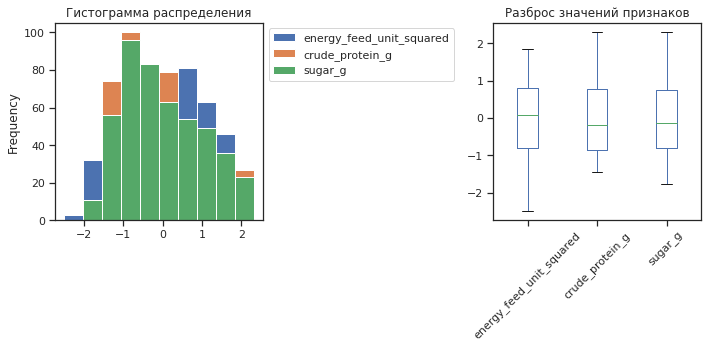

R2 LinearRegression = 0.8064
MSE = 39419
RMSE = 199
MAE = 154

x0_менее_2_лет      : -203.843693
x1_рефлешнсоверинг  : +9.103824
x2_соверин          : +46.720175
x3_буйный           : +342.189837
x3_геркулес         : +369.760480
x3_соловчик         : +37.447735
x4_холмистое        : +69.053093
energy_feed_unit_squared: +160.868514
crude_protein_g     : -396.771664
sugar_g             : +538.926920


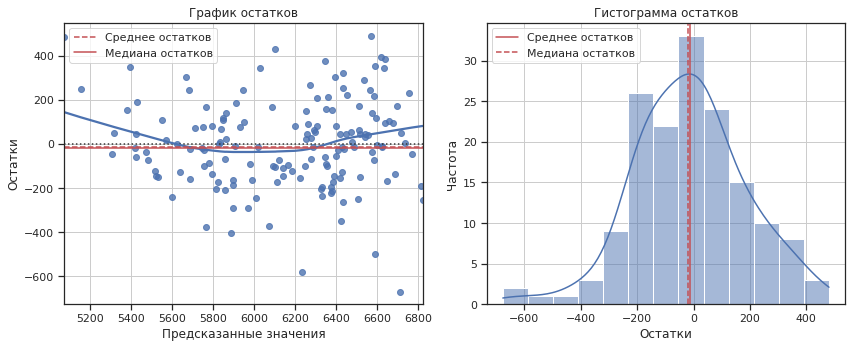

In [139]:
# построим модель линейной регрессии
full_linear_model(
    data=ferma_sugar,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_g',
        'age',
        'breed',
        'dad_breed',
        'dad_name',
        'pasture_type'
    ],)

Модель стала работать хуже (снизился R2 и увеличились ошибки). Возможно дело в мультиколлинеарности признаков `sugar_g` и `crude_protein_g`, а также признаков `dad_breed` и `dad_name`.

Попробуем не учитывать `crude_protein_g` и `dad_breed`.

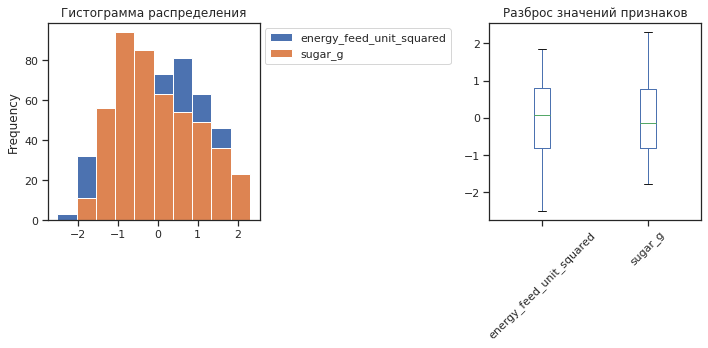

R2 LinearRegression = 0.7493
MSE = 51024
RMSE = 226
MAE = 174

x0_менее_2_лет      : -236.224766
x1_рефлешнсоверинг  : +14.307487
x2_буйный           : +336.414801
x2_геркулес         : +354.053601
x2_соловчик         : +28.766240
x3_холмистое        : +54.708875
energy_feed_unit_squared: +232.302895
sugar_g             : +110.881870


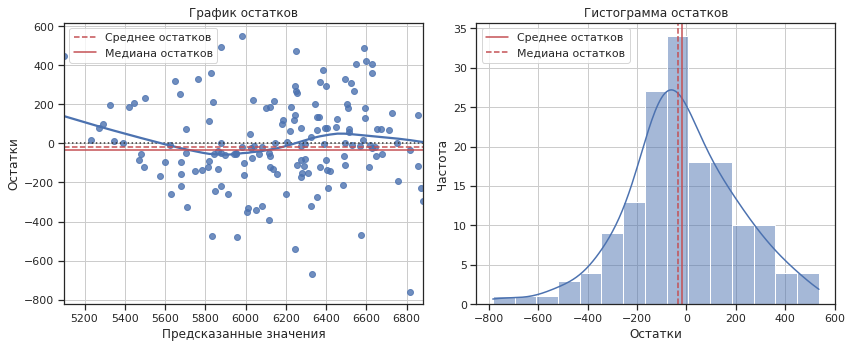

In [140]:
# построим модель линейной регрессии
full_linear_model(
    data=ferma_sugar,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit_squared',
        #'crude_protein_g', - не учитываем
        'sugar_g',
        'age',
        'breed',
        #'dad_breed', - не учитываем
        'dad_name',
        'pasture_type'
    ],)

Модель стала работать еще хуже, значит преобразование и использование абсолютного сахара вместо показателя ЭКЕ не помогло.

#### Выбор лучшей модели

**Модель 1:**
- R2 LinearRegression = 0.7844
- MSE = 43887
- RMSE = 209
- MAE = 164

**Модель 2:**
- R2 LinearRegression = 0.8181
- MSE = 37031
- RMSE = 192
- MAE = 149

**Модель 3:**
- R2 LinearRegression = 0.8248
- MSE = 35674
- RMSE = 189
- MAE = 146

**Модель 4:**
- R2 LinearRegression = 0.8064
- MSE = 39419
- RMSE = 199
- MAE = 154


Исходя из представленных данных, Модель 3 является лучшей среди представленных моделей по следующим причинам:
- Модель 3 имеет наивысший коэффициент детерминации (R2) среди всех представленных моделей, что указывает на лучшую объясняющую способность модели.
- Модель 3 также имеет наименьшее значение MSE, RMSE и MAE, что указывает на более точное предсказание по сравнению с другими моделями.

Определим доверительный интервал прогноза лучшей модели (Модель 3):

In [141]:
# довертельный интервал с уверенностью 95%
print(f'Доверительный интервал с уверенностью 95%: {st.norm.interval(0.95, loc=test_predictions.mean(), scale=st.sem(test_predictions))}')
print(f'Доверительный интервал с уверенностью 99%: {st.norm.interval(0.99, loc=test_predictions.mean(), scale=st.sem(test_predictions))}')


Доверительный интервал с уверенностью 95%: (6106.009965598841, 6228.04870872839)
Доверительный интервал с уверенностью 99%: (6086.83628943393, 6247.222384893301)


Доверительный интервал модели линейной регрессии предоставляет диапазон значений, в пределах которого с некоторой вероятностью (обычно 95%) находится истинное значение параметра, который мы пытаемся оценить с помощью регрессии.

**Доверительный интервал с уверенностью 95%:**
- Нижняя граница: 6106.009965598841
- Верхняя граница: 6228.04870872839

Этот интервал указывает, что с 95% вероятностью истинное среднее значение удоя коров будет находиться в диапазоне от 6106.01 кг до 6228.05 кг.

**Доверительный интервал с уверенностью 99%:**
- Нижняя граница: 6086.83628943393
- Верхняя граница: 6247.222384893301

Этот интервал более широкий, так как уверенность составляет 99%. Он указывает, что с 99% вероятностью истинное среднее значение удоя коров находится в диапазоне от 6086.84 кг до 6247.22 кг.

На основании этих доверительных интервалов можно сделать вывод, что средний удой коров в молочном хозяйстве вероятно превышает 6000 кг, и этот вывод подтверждается с высокой степенью уверенности, как в случае 95%, так и 99% доверительных интервалов.

#### Прогноз удоя коров "ЭкоФермы"

Данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой содержатся в таблице `cow_buy`. Структура таблицы почти аналогична ferma_main, кроме нескольких особенностей:

- Белок и Жирность молока указаны на момент покупки — когда «ЭкоФерма» давала им свой корм.
- Параметры кормления ЭКЕ, Сырой протеин, СПО отсутствуют. Недавно технологи заказчика пересмотрели параметры корма и планируют их внедрить после расширения стада. Именно новые параметры нужно использовать, когда вы будете применять предсказательные модели к бурёнкам «ЭкоФермы». По новой схеме фермер планирует увеличить средние значения ЭКЕ, Сырой протеин, СПО на 5%.

В нашей модели содержание белка и жирность молока не учитываяются и не влияют на удой коровы. Поэтому эта особенность не повлияет на прогноз удоя.

Добавим недостающие признаки с характеристиками корма в `cow_buy`.

In [142]:
cow_buy.head()

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет


In [143]:
# сохраним копию таблицы cow_buy, в которую будем подтягивать параметры еды в новую переменную
cow_buy_adjusted = cow_buy.copy()

In [144]:
# добавим средние параметры корма из таблицы ferma_main, увеличенные на 5%
cow_buy_adjusted[['energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio']] = \
                ferma_main[['energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio']].mean()*1.05

In [145]:
# все параметры корма заполнены средними значениями, увеличенными на 5%
cow_buy_adjusted

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,0.958744
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,0.958744
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,0.958744
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,0.958744
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,0.958744
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,0.958744
7,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.276162,2019.947532,0.958744
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,15.276162,2019.947532,0.958744
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,0.958744


In [146]:
# избавимся от нелинейности факторов по аналогии с данными в ferma_main_v3 
cow_buy_adjusted['sugar_protein_ratio'] = cow_buy_adjusted['sugar_protein_ratio'].apply(lambda x: 'высокое' if x >= 0.92 else 'низкое')
cow_buy_adjusted['energy_feed_unit_squared'] = cow_buy_adjusted['energy_feed_unit'] ** 2

In [147]:
cow_buy_adjusted

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,высокое,233.361138
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,высокое,233.361138
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,высокое,233.361138
7,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.276162,2019.947532,высокое,233.361138
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,15.276162,2019.947532,высокое,233.361138
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,высокое,233.361138


Реальные данные готовы для обработки моделью и построения прогноза.

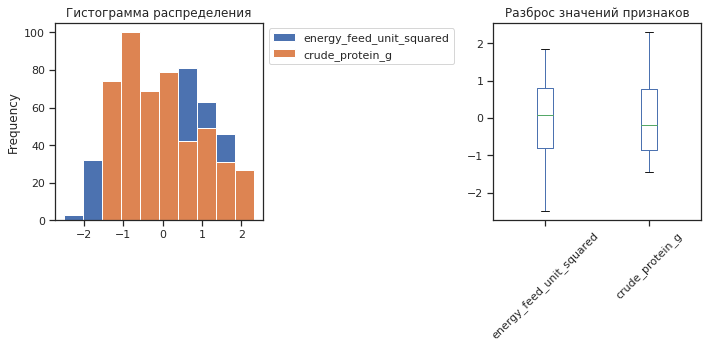

R2 LinearRegression = 0.8248
MSE = 35674
RMSE = 189
MAE = 146

x0_низкое           : -353.779829
x1_менее_2_лет      : -192.548709
x2_рефлешнсоверинг  : +14.919634
x3_соверин          : +44.033305
x4_буйный           : +302.179596
x4_геркулес         : +333.929151
x4_соловчик         : +24.684409
x5_холмистое        : +50.943310
energy_feed_unit_squared: +162.387792
crude_protein_g     : +52.035317


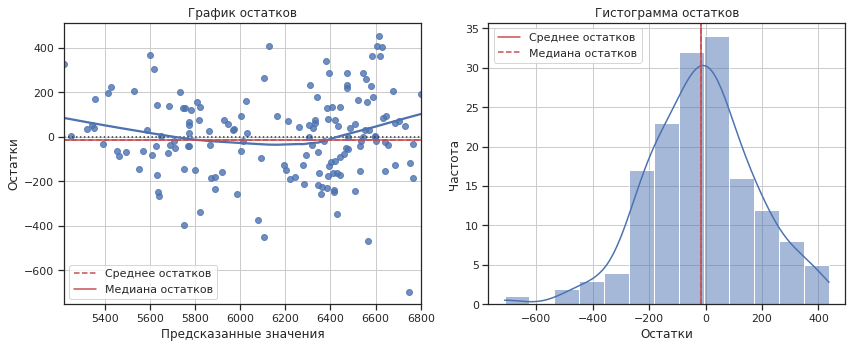

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared,milk_yield_kg_predicted
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6378.711028
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,6283.999775
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,высокое,233.361138,6593.089377
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,6542.146066
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6425.380218
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,высокое,233.361138,6571.259737
7,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6400.540668
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,15.276162,2019.947532,высокое,233.361138,6344.707860
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,высокое,233.361138,6617.928926


In [148]:
# обучим модель также как в Модели 3 и получим предсказания для реальных данных.
X_real, y_real, final_real = full_linear_model(
    data=ferma_main_v3,
    target='milk_yield_kg',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'age',
        'breed',
        'dad_breed',
        'dad_name',
        'pasture_type'
    ],
    X_real=cow_buy_adjusted
)

display(final_real)

In [149]:
# будем созранять итоговые предсказания в переменную cow_buy_predictions
cow_buy_predictions = final_real.sort_values(by='milk_yield_kg_predicted', ascending=False)
cow_buy_predictions

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared,milk_yield_kg_predicted
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,высокое,233.361138,6617.928926
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297
10,вис бик айдиал,холмистое,айдиал,геркулес,3.68,3.046,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,высокое,233.361138,6593.089377
12,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.065,более_2_лет,15.276162,2019.947532,высокое,233.361138,6593.089377
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,высокое,233.361138,6571.259737
15,вис бик айдиал,равнинное,соверин,буйный,3.34,3.069,более_2_лет,15.276162,2019.947532,высокое,233.361138,6571.259737
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,6542.146066
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6425.380218
14,рефлешнсоверинг,равнинное,соверин,геркулес,3.77,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6425.380218


### Выводы

В результате построения модели линейной регресси по прогнозу целевого параметра удоя молока для коров с пастбища "ЭкоФерма" могут быть сделаны следующие выводы:

**1. Определение входящих факторов для прогноза удоя:**

Для построения моделей линейной регрессии были определены следующие входные параметры, имеющие логическую связь с размером удоя коровы:
- age ("Возраст")
- breed ("Порода")
- dad_breed ("Порода папы коровы")
- dad_name ("Имя папы коровы")
- energy_feed_unit ("ЭКЕ (Энергетическая кормовая единица)").
- crude_protein_g ("Сырой протеин, г")
- sugar_protein_ratio ("СПО (Сахаро-протеиновое соотношение)")
- pasture_type ("Тип пастбища")

**2. Подготовка данных и построение модели:**

- Данные были разделены на обучающую и тестовую выборки.
- К ним была применена нормализация категориальных признаков с помощью One-Hot Encoding и масштабирование количественных признаков с помощью StandardScaler.
- Была создана и обучена базовая модель линейной регрессии на основе исходного файла ferma_main.
- Качество базовой модели:
 - R2 (коэффициент детерминации) = 0.7844: Примерно 78.44% изменчивости удоя коровы можно объяснить используемой моделью.
 - MSE (среднеквадратичная ошибка) = 43887: Среднеквадратичная ошибка модели составляет 43887 квадратных килограммов.
 - RMSE (квадратный корень из среднеквадратичной ошибки) = 209: Средняя ошибка прогнозов составляет 209 кг.
 - MAE (средняя абсолютная ошибка) = 164: Модель в среднем ошибается на 164 кг при прогнозировании удоя коровы.
 - График и анализ остатков указывают на то, что модель имеет некоторые ограничения из-за нелинейной связи между предсказанными и фактическими значениями, а также наличия выбросов. Хотя средний остаток близок к нулю, локальное среднее показывает систематическое смещение, требующее улучшений для более точного предсказания.
 
**3. Калибровка и выбор лучшей модели:**

В ходе анализа были построены 4 модели линейной регрессии:
 - Модель 1 (базовая): построена на основании исходных данных в таблице ferma_main.
 - Модель 2 (устранение нелинейности): Для устранения нелинейности в связях между переменными, СПО был преобразован в категориальный признак (с границы нелинейности в размере 0.92) и добавии новый признак "ЭКЕ в квадрате" для улучшения моделирования взаимосвязи между ЭКЕ и Удоем.
 - Модель 3 (учет `dad_name`): С учетом преобразований в Модели 2, в таблицу был добавлен дополнительный признак `dad_name`.
 - Модель 4 (абсолютный сахар): Была проверена дополнительная модель с преобразование СПО не в категориальный, а в количественный признак.
 
Параметры и качество полученных моделей линейной регрессии представлены в таблице ниже:

| Модель           | Исходные данные     | Целевая переменная | Входные признаки                                       | R2 LinearRegression | MSE   | RMSE | MAE |
|:-----------------|:-------------------|:------------------|:-------------------------------------------------------|:---------------------|-----:|-----:|----:|
| Модель 1         | ferma_main         | milk_yield_kg     | energy_feed_unit, crude_protein_g, sugar_protein_ratio, age, breed, dad_breed, pasture_type | 0.7844 | 43887 | 209  | 164 |
| Модель 2         | ferma_main_v2      | milk_yield_kg     | energy_feed_unit_squared, crude_protein_g, sugar_protein_ratio, age, breed, dad_breed, pasture_type | 0.8181 | 37031 | 192  | 149 |
| **Модель 3**     | **ferma_main_v3**  | **milk_yield_kg** | **energy_feed_unit_squared, crude_protein_g, sugar_protein_ratio, age, breed, dad_breed, dad_name, pasture_type** | **0.8248** | **35674** | **189**  | **146** |
| Модель 4         | ferma_sugar        | milk_yield_kg     | energy_feed_unit_squared, crude_protein_g, sugar_g, age, breed, dad_breed, dad_name, pasture_type | 0.8064 | 39419 | 199  | 154 |

- Модель 3 была выбрана как лучшая, так как она обладает самым высоким коэффициентом детерминации (R2) и наименьшими значениями ошибок MSE, RMSE и MAE. 
- Доверительный интервал (99%) для среднего значения удоя коров в молочном хозяйстве указывает, что с вероятностью 99% истинное среднее значение удоя находится между 6086 кг и 6248 кг. Поскольку нижняя граница доверительного интервала (6086 кг) превышает 6000 кг, можно с уверенностью 99% сказать, что прогнозное значение среднего удоя коров в молочном хозяйстве превышает 6000 кг.
- Модель 3 была выбрана для дальнейших предсказаний на основе реальных данных пастбища "ЭкоФерма".

**4. Прогноз удоя коров "Экофермы":**

Данные таблицы cow_buy были подготовлены для использования в модели следующим образом:
- параметры корма были заполнены средними значениями по коровам хозяйства "Вольный луг". Значения были увеличены на 5% в соответствии с планам хозяйства.
 
Результаты прогноза модели на данных хозяйства "ЭкоФерма":
 - прогнозный удой у всех коров оказался выше 6000 кг. 
 - предсказания добавлены в исходную таблицу и сохранены в переменной `cow_buy_predictions`.

## Обучение модели логистической регрессии

### Факторы влияющие на вкус молока

На вкус молока коровы могут влиять следующие факторы:

1. Особенности коровы:
- `age` ("Возраст"): Возможно, что возраст коровы может влиять на состав молока, что, в свою очередь, может отразиться на вкусе молока. Молодые и более зрелые коровы могут иметь различный химический состав молока.
- `breed` ("Порода"): Разные породы коров имеют свои уникальные характеристики, которые могут влиять на вкус молока. Например, молоко некоторых пород может быть более сладким или кремовым.
- `dad_breed` ("Порода папы коровы"): Порода отца также может оказывать влияние на генетические особенности, которые могут сказаться на вкусовых качествах молока.
- `dad_name` ("Имя папы коровы"): Имя отца коровы может быть связано с определенной породной линией, которая известна своими качествами молока.

2. Параметры корма коровы:
- `energy_feed_unit` ("ЭКЕ (Энергетическая кормовая единица)"): Качество и количественный состав корма коровы могут влиять на содержание жиров, белков и других веществ в молоке, что может повлиять на вкус молока.
- `crude_protein_g` ("Сырой протеин, г"):  Содержание сырого протеина в корме коровы напрямую связано с содержанием белка в молоке, что может повлиять на его вкус.
- `sugar_protein_ratio` ("СПО (Сахаро-протеиновое соотношение)"): Это соотношение может также влиять на баланс между сладостью и протеинами в молоке, что может оказать влияние на вкус.

3. Тип пастбища:
- `pasture_type` - Тип пастбища, где пасется корова, может влиять на разнообразие кормовых растений, которые она потребляет, и, следовательно, на химический состав молока и его вкус.

4. Параметры молока:
- `fat_percentage` ("Жирность,%"): Высокое содержание жиров в молоке может придавать ему более насыщенный вкус и текстуру.
- `protein_percentage` ("Белок,%"): Содержание белка в молоке может влиять на его кремовость и вкусовые характеристики.



### Подготовка данных и построение базовой модели

In [150]:
# используем таблицу c устраненными нелинейными зависимостями и подтянутым dad_name
ferma_main_v3.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age,energy_feed_unit_squared,dad_name
0,1,5863,14.2,1743,низкое,вис бик айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,201.64,буйный
1,2,5529,12.8,2138,низкое,вис бик айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,163.84,соловчик
2,3,5810,14.0,1854,низкое,рефлешнсоверинг,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,196.00,барин
3,4,5895,12.4,2012,низкое,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,153.76,буйный
4,5,5302,12.8,1675,низкое,вис бик айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,163.84,барин


Целевой признак `milk_flavor` принимает только два значения:
- вкусно
- не вкусно

Поэтому для предсказания класса объекта подойдет бинарная модель логистической регрессии.

Заменим признак "вкусно" на 1, а "не вкусно" на 0. 

In [151]:
ferma_main_log = ferma_main_v3.copy()
ferma_main_log['milk_flavor'] = ferma_main_log['milk_flavor'].replace({'вкусно': 1, 'не вкусно': 0})
ferma_main_log.head()

,id,milk_yield_kg,energy_feed_unit,crude_protein_g,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_percentage,protein_percentage,milk_flavor,age,energy_feed_unit_squared,dad_name
0,1,5863,14.2,1743,низкое,вис бик айдиал,равнинное,айдиал,3.58,3.076,1,более_2_лет,201.64,буйный
1,2,5529,12.8,2138,низкое,вис бик айдиал,равнинное,соверин,3.54,3.079,1,менее_2_лет,163.84,соловчик
2,3,5810,14.0,1854,низкое,рефлешнсоверинг,холмистое,соверин,3.59,3.074,0,более_2_лет,196.00,барин
3,4,5895,12.4,2012,низкое,рефлешнсоверинг,холмистое,айдиал,3.40,3.075,0,более_2_лет,153.76,буйный
4,5,5302,12.8,1675,низкое,вис бик айдиал,равнинное,соверин,3.73,3.073,1,менее_2_лет,163.84,барин


In [152]:
ferma_main_log.columns

Index(['id', 'milk_yield_kg', 'energy_feed_unit', 'crude_protein_g',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'dad_breed',
       'fat_percentage', 'protein_percentage', 'milk_flavor', 'age',
       'energy_feed_unit_squared', 'dad_name'],
      dtype='object')

In [153]:
# обработка данных с помощью функции и сохранение результатов в соответствующие переменные
X_train, X_test, y_train, y_test, num_col_names, cat_col_names, target, scaler, encoder = preprocess_test_data(
    data=ferma_main_log,
    target='milk_flavor',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'fat_percentage',
        'protein_percentage',
        'age',
        'pasture_type',
        'breed',
        'dad_breed',
        'dad_name'
    ],
)

# проверка подготовленных таблиц
print(f'Количественные признаки: {num_col_names}')
print(f'Категориальные признаки: {cat_col_names}')
print(f'Целевой признак: {target}')

print(f' Форма X_train: {X_train.shape}')
print(f' Форма y_test: {y_test.shape}')
print(f' Форма X_test: {X_test.shape}')
print(f' Форма y_train: {y_train.shape}')


display(X_train.head(), X_test.head(), y_train.head(), y_test.head())

Количественные признаки: ['energy_feed_unit_squared', 'crude_protein_g', 'fat_percentage', 'protein_percentage']
Категориальные признаки: ['sugar_protein_ratio', 'age', 'pasture_type', 'breed', 'dad_breed', 'dad_name']
Целевой признак: milk_flavor
 Форма X_train: (471, 12)
 Форма y_test: (157,)
 Форма X_test: (157, 12)
 Форма y_train: (471,)


,x0_низкое,x1_менее_2_лет,x2_холмистое,x3_рефлешнсоверинг,x4_соверин,x5_буйный,x5_геркулес,x5_соловчик,energy_feed_unit_squared,crude_protein_g,fat_percentage,protein_percentage
0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.577968,1.079523,0.562532,-0.679069
1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-1.511438,-0.196920,-1.601817,-1.452568
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.082269,-1.386085,-2.563750,1.254677
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.150235,0.752230,0.081565,1.254677
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.102358,0.828598,0.201807,0.094429


,x0_низкое,x1_менее_2_лет,x2_холмистое,x3_рефлешнсоверинг,x4_соверин,x5_буйный,x5_геркулес,x5_соловчик,energy_feed_unit_squared,crude_protein_g,fat_percentage,protein_percentage
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.527089,-0.813322,0.201807,0.094429
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.490346,0.026730,0.622652,-1.065819
2,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-0.527089,-0.682405,0.141686,0.094429
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.961737,-1.058792,0.081565,-0.679069
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.561660,-1.413360,0.081565,0.094429


id
509    1
384    1
588    0
198    1
329    1
Name: milk_flavor, dtype: int64

id
583    1
593    1
552    1
215    0
487    1
Name: milk_flavor, dtype: int64

Обработка тестовой выборки прошла корректно.

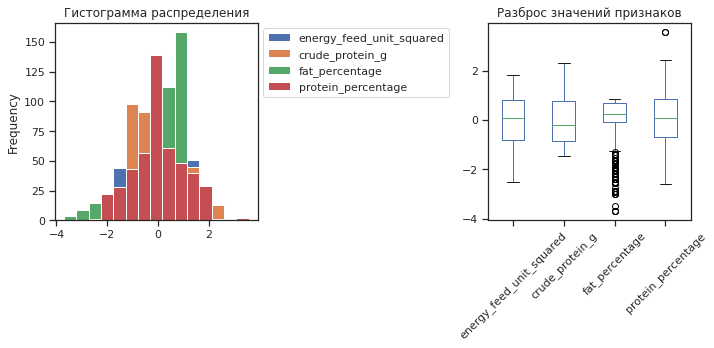

In [154]:
# проверка распределения данных после масштабирования числовых признаков
plot_num_features_distribution(X_train, num_col_names, bins=15)

Масштабировано также выполнено успешно.

In [155]:
def logistic_model_and_predict(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, X_real=None, model=LogisticRegression()):
    # Обучение модели
    model.fit(X_train, y_train)
    
    # Предсказание на тестовых данных
    test_predictions = model.predict(X_test)
    
    for feature_number, feature_name in enumerate(X_train.columns):
        weight = model.coef_[0, feature_number]
        print(f"{feature_name:<20}: {weight:+.6f}")

    y_proba = model.predict_proba(X_test)[:,1]
    probabilities = pd.DataFrame(zip(y_test, y_proba), columns = ['y_valid', 'y_proba']).sort_values(by='y_proba',ascending=False)
    print('\n', probabilities.head())

    # Оценка на тестовых данных
    accuracy = accuracy_score(y_test, test_predictions)
    recall = recall_score(y_test, test_predictions)
    precision = precision_score(y_test, test_predictions)

    # Вывод оценок
    print()
    print('accuracy: ',round(accuracy ,3))
    print('recall: ',round(recall ,3))
    print('precision: ',round(precision,3))
    
    cm = confusion_matrix(y_test, test_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
    plt.ylabel('True label')
    plt.xlabel('Predicted')
    plt.show()
    
    # Предсказание на реальных данных
    real_predictions = model.predict(X_real) if X_real is not None else None    
        
    return model, feature_number, test_predictions, real_predictions, accuracy, recall, precision, probabilities

x0_низкое           : +0.717791
x1_менее_2_лет      : -0.204374
x2_холмистое        : +0.501364
x3_рефлешнсоверинг  : +0.039923
x4_соверин          : -0.037825
x5_буйный           : -0.095495
x5_геркулес         : -0.105027
x5_соловчик         : -0.424116
energy_feed_unit_squared: +0.614456
crude_protein_g     : +0.170151
fat_percentage      : -0.020444
protein_percentage  : +0.261697

      y_valid   y_proba
85         1  0.861355
110        1  0.842792
66         1  0.841488
51         1  0.839668
8          1  0.817304

accuracy:  0.631
recall:  0.864
precision:  0.623


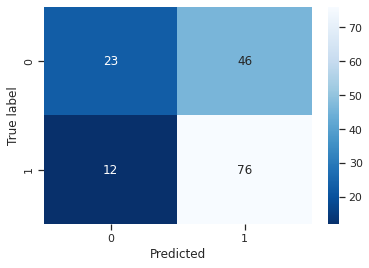

In [156]:
# обучим модель и выведем основные метрики, построим confusion matrix
model, feature_number, test_predictions, real_predictions, accuracy, recall, precision, probabilities = logistic_model_and_predict(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    X_real=None,
    model=LogisticRegression()
)

Взглянув на коэффициенты, приведенные выше, можно сделать следующие выводы:

Положительные коэффициенты:
- x0_низкое: При увеличении этого параметра на единицу вероятность положительного вкуса молока увеличивается на 0.717791.
- energy_feed_unit_squared: Увеличение этого параметра на единицу увеличивает вероятность положительного вкуса молока на 0.614456.
- x2_холмистое: Увеличение этого параметра на единицу увеличивает вероятность положительного вкуса молока на 0.501364.
- protein_percentage: Увеличение содержания белка в корме увеличивает вероятность положительного вкуса молока на 0.261697.
- crude_protein_g: Увеличение этого параметра на единицу увеличивает вероятность положительного вкуса молока на  0.170151
- x3_рефлешнсоверинг: Увеличение этого параметра на единицу увеличивает вероятность положительного вкуса молока на 0.039923

Отрицательные коэффициенты:
- x5_соловчик: Увеличение этого параметра на единицу уменьшает вероятность положительного вкуса молока на 0.424116
- x1_менее_2_лет: Увеличение этого параметра на единицу уменьшает вероятность положительного вкуса молока на 0.204374.
- x5_геркулес: Увеличение этого параметра на единицу уменьшает вероятность положительного вкуса молока на 0.105027
- x5-_буйный: Увеличение этого параметра на единицу уменьшает вероятность положительного вкуса молока на 0.095495
- x4_соверин: Увеличение этого параметра на единицу уменьшает вероятность положительного вкуса молока на 0.037825
- fat_percentage: Увеличение этого параметра на единицу уменьшает вероятность положительного вкуса молока на 0.031218.

Модель показывает неплохие результаты:

- Точность (accuracy): 63.1% Доля правильных прогнозов модели составляет около 63.1%. 
- Полнота (recall): 86.4% Это значит, что модель правильно классифицировала 86.4% всех положительных объектов.
- Точность (precision): 62.3% Это значит, что 62.3% объектов, отмеченных моделью как положительные, действительно являются положительными.

Это означает, что модель способна правильно классифицировать примерно 64% случаев, из которых 86.4% действительно положительные случаи. При этом в 62.3% случаев, где модель предсказывает положительный вкус, она действительно права.

Для хозяйства важно, чтобы купленные коровы гарантированно имели вкусное молоко, а это значит, что количество ложноположительных ошибок необходимо минимизировать.

Следовательно, нужно откалибровать модель таким образом, чтобы **максимизировать** показатель **precision**.

In [157]:
# функция для поиска оптимального трешхолда для максимизации precision
def find_optimal_threshold(model, X_test, y_test, num=100):
    thresholds = np.linspace(0, 1, num)
    best_precision = 0
    best_threshold = 0

    results = []

    for threshold in thresholds:
        y_pred = (model.predict_proba(X_test)[:, 1] > threshold).astype(int)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=1)
        recall = recall_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'Порог': f'y_pred_{threshold:.3f}',
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Количество «правильных единичек»': cm[1, 1],
            'Количество False Positive': cm[0, 1],
            'Количество False Negative': cm[1, 0],
            'Количество "правильный нулей"': cm[0, 0]
        })

        if precision > best_precision:
            best_precision = precision
            best_threshold = threshold

    y_pred_final = (model.predict_proba(X_test)[:, 1] > best_threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred_final)
    recall = recall_score(y_test, y_pred_final)
    
    print("Best threshold:", best_threshold)
    print("Accuracy:", accuracy)
    print("Recall:", recall)
    print("Precision:", best_precision)
    
    # Создание и вывод таблицы
    results_df = pd.DataFrame(results)
    display(results_df)
    
    results_df['Threshold'] = results_df['Порог'].apply(lambda x: float(x.split('_')[-1]))
    
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Threshold'], results_df['Accuracy'], label='Accuracy')
    plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
    plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
    # Добавляем вертикальную линию для best_threshold
    plt.axvline(x=best_threshold, color='r', linestyle='--', label='Best Threshold')
    
    plt.xlabel('Threshold')
    plt.ylabel('Metric Value')
    plt.title('Metrics vs. Threshold')
    plt.legend()
    plt.grid(True)
    
    plt.show()

    return best_threshold, best_precision, results_df

Best threshold: 0.8080808080808082
Accuracy: 0.4840764331210191
Recall: 0.07954545454545454
Precision: 1.0


,Порог,Accuracy,Precision,Recall,Количество «правильных единичек»,Количество False Positive,Количество False Negative,"Количество ""правильный нулей"""
0,y_pred_0.000,0.56051,0.56051,1.0,88,69,0,0
1,y_pred_0.010,0.56051,0.56051,1.0,88,69,0,0
2,y_pred_0.020,0.56051,0.56051,1.0,88,69,0,0
3,y_pred_0.030,0.56051,0.56051,1.0,88,69,0,0
4,y_pred_0.040,0.56051,0.56051,1.0,88,69,0,0
...,...,...,...,...,...,...,...,...
95,y_pred_0.960,0.43949,1.00000,0.0,0,0,88,69
96,y_pred_0.970,0.43949,1.00000,0.0,0,0,88,69
97,y_pred_0.980,0.43949,1.00000,0.0,0,0,88,69
98,y_pred_0.990,0.43949,1.00000,0.0,0,0,88,69


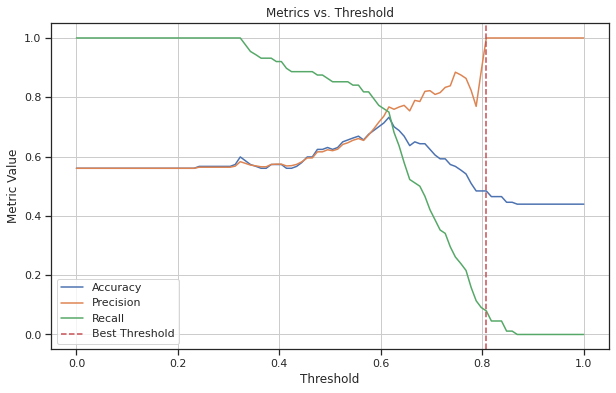

In [158]:
# выведем результаты поиска оптимального трешхолда
best_threshold, best_precision, results_df = find_optimal_threshold(model, X_test, y_test, num=100)

Для того чтобы минимизировать критическую ошибку до нуля, необходимо найти оптимальное значение порога вероятности для классификации, при котором **precision -> max** .

Максимальное значение precision достигается при минимальном пороге вероятности **80,8%.**

Precision=1 говорит о том, что если модели удастся предсказать вкусное молоко, то с вероятностью близкой к 100% это будет именно так. Вероятность ложноположительной ошибки будет сведена к минимуму, что и требуется по условием поставленной задачи.

При этом общий показатель Accuracy модели (процент верных предсказаний) немного снизился с 63.1% до 48.4%.

Recall (полнота предсказания вкусного молока) снизился существенно с 86.4% до 7.95%. Это значит, что почти в 82% случаев фактически вкусное молоко будет распознано моделью как невкусное. Однако учитывая нашу цель (гарантированно выбрать корову с вкусным молоком), это не имеет большого значения.

In [159]:
# соберем полную модель логистической регрессии в одну функцию, включающую:
    # обработку тестовых и реальных данные (если есть),
    # обучение модели логистической регрессии,
    # получение предсказаний на основе тестовой и реальной выборки, расчет метрик accurace, recall, precision с заданным порогом классификации
    # если порог классификации не задан, то поиск оптимального порога для максимизации precision
    # график распределения признаков и остатков
    # поиск реальных предсказаний с заданным порогом классификации и добавление их в первоначальный датасет
    
def full_logistical_model(data, target, variables, X_real=None, model=LogisticRegression(), scaler=StandardScaler(), bins=15, num=100, manual_threshold=None):
     
    # скопируем первоначальную таблицу в отдельную переменную, чтобы потом добавить туда предсказанный целевой признак
    X_real_predicted = X_real.copy() if X_real is not None else None

    # Предварительная обработка тестовых данных
    X_train, X_test, y_train, y_test, num_col_names, cat_col_names, target, scaler, encoder = preprocess_test_data(data, target, variables, scaler)
    
    if X_real is not None:
        # Предварительная обработка реальных данных
        X_real = preprocess_real_data(X_real, num_col_names, cat_col_names, scaler, encoder)
    
    # проверка распределения данных после масштабирования числовых признаков
    plot_num_features_distribution(X_train, num_col_names, bins=bins)
    
    # Обучение модели и оценка результатов
    model, feature_number, test_predictions, real_predictions, accuracy, recall, precision, probabilities = logistic_model_and_predict(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        X_real=X_real,
        model=model)
    
    # поиск лучшего трешхолда precision
    best_threshold, best_precision, results_df = find_optimal_threshold(model, X_test, y_test, num=num)
    
    
    # поиск лучшего трешхолда precision
    if manual_threshold is not None:
        best_threshold = manual_threshold        
        best_precision = precision_score(y_test, model.predict_proba(X_test)[:, 1] > best_threshold)
        y_pred_manual = (model.predict_proba(X_test)[:, 1] > best_threshold).astype(int)
        print(f'Manual Threshold: {manual_threshold}')
        print(f'Manual Accuracy: {accuracy_score(y_test, y_pred_manual)}')
        print(f'Manual Recal: {recall_score(y_test, y_pred_manual)}')
        print(f'Manual Precision: {precision_score(y_test, y_pred_manual)}')
    
    if X_real is not None:
        # Предсказание реальных данных на основе обученной модели и best_threshold
        y_real = (model.predict_proba(X_real)[:, 1] > best_threshold).astype(int)
        X_real_predicted[target+'_predicted'] = y_real
        print(f"Предсказание реальных значений (Порог классификации = {round(best_threshold, 4)}):")
        display(X_real_predicted)
        real_probabilities = model.predict_proba(X_real)[:, 1]
        
    # Возвращаем результаты
    if X_real_predicted is not None:
        return X_real, y_real, X_real_predicted, real_probabilities


### Выбор лучшей модели

#### Модель 1 (базовая)

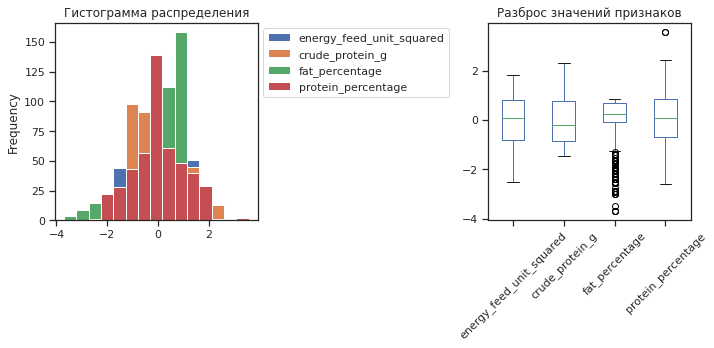

x0_низкое           : +0.717791
x1_менее_2_лет      : -0.204374
x2_холмистое        : +0.501364
x3_рефлешнсоверинг  : +0.039923
x4_соверин          : -0.037825
x5_буйный           : -0.095495
x5_геркулес         : -0.105027
x5_соловчик         : -0.424116
energy_feed_unit_squared: +0.614456
crude_protein_g     : +0.170151
fat_percentage      : -0.020444
protein_percentage  : +0.261697

      y_valid   y_proba
85         1  0.861355
110        1  0.842792
66         1  0.841488
51         1  0.839668
8          1  0.817304

accuracy:  0.631
recall:  0.864
precision:  0.623


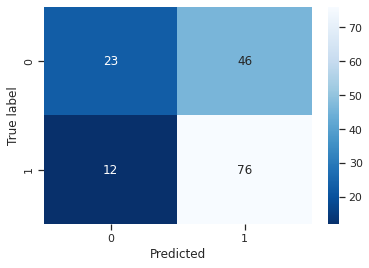

Best threshold: 0.8080808080808082
Accuracy: 0.4840764331210191
Recall: 0.07954545454545454
Precision: 1.0


,Порог,Accuracy,Precision,Recall,Количество «правильных единичек»,Количество False Positive,Количество False Negative,"Количество ""правильный нулей"""
0,y_pred_0.000,0.56051,0.56051,1.0,88,69,0,0
1,y_pred_0.010,0.56051,0.56051,1.0,88,69,0,0
2,y_pred_0.020,0.56051,0.56051,1.0,88,69,0,0
3,y_pred_0.030,0.56051,0.56051,1.0,88,69,0,0
4,y_pred_0.040,0.56051,0.56051,1.0,88,69,0,0
...,...,...,...,...,...,...,...,...
95,y_pred_0.960,0.43949,1.00000,0.0,0,0,88,69
96,y_pred_0.970,0.43949,1.00000,0.0,0,0,88,69
97,y_pred_0.980,0.43949,1.00000,0.0,0,0,88,69
98,y_pred_0.990,0.43949,1.00000,0.0,0,0,88,69


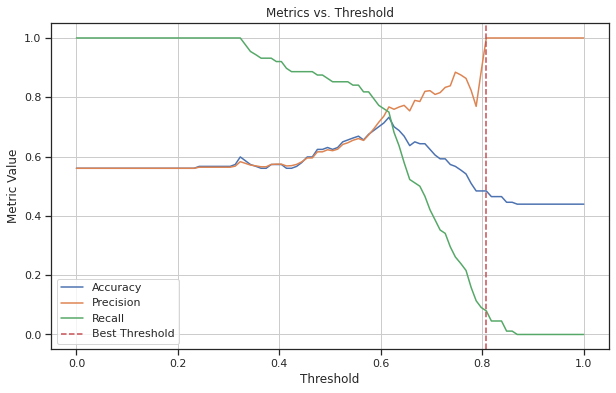

In [160]:
# Сделаем прогноз вкуса молока на реальных данных с оптимальным порогом классификации
full_logistical_model(
    data=ferma_main_log,
    target='milk_flavor',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'fat_percentage',
        'protein_percentage',
        'age',
        'pasture_type',
        'breed',
        'dad_breed',
        'dad_name'
    ],
)

#### Модель 2 (без выбросов)

На этапе исследовательского анализа были обнаружены выбросы в колонках:

 - `fat_percentage` - большое количество выбросов в левой части графика. Процент выбросов (13.69%) существенный. Все пропуски сосредочены в левой части графика и соответствуют длинному левому хвосту в распределении молока коров по проценту жирности. Доля выбросов достаточно существенная, на данном этапе не будем их удалять. Выбросы вероятно имеют естественные причины.
 - `protein_percentage` - небольшие выбросы как слева, так и справа (все 5 значений - 0.80% выборки, отклонения небольшие). Выбросы скорей всего имеют естественные причины. Выбросы оставлены в выборке.

Границы диаграммы размаха по колонке 'protein_percentage':
Lower Whisker: 3.07
Upper Whisker: 3.081


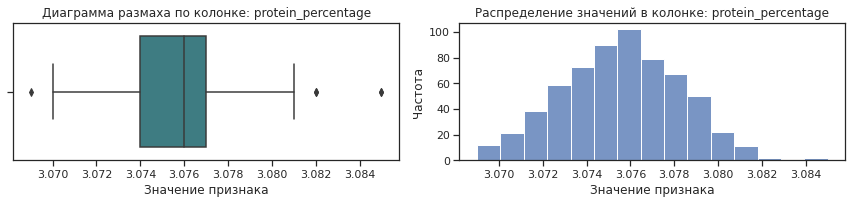

Границы диаграммы размаха по колонке 'fat_percentage':
Lower Whisker: 3.4
Upper Whisker: 3.75


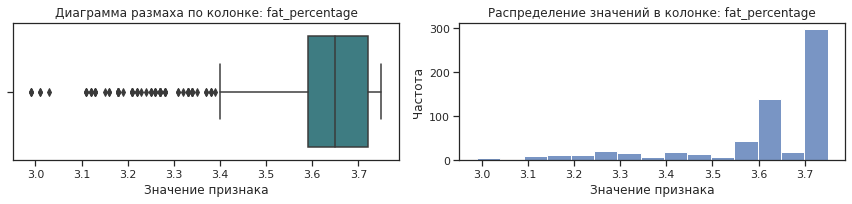

Доля выбросов: 14.49%


In [161]:
# посмотрим выбросы в колонке 'protein_percentage'
outliers = find_outliers(ferma_main_log, ['protein_percentage', 'fat_percentage'], bins=15)

In [162]:
ferma_main_log2 = ferma_main_log.loc[~ferma_main_log['id'].isin(outliers['id'])]

In [163]:
print(ferma_main_log.shape)
print(outliers.shape)
print(ferma_main_log2.shape)

(628, 14)
(90, 14)
(538, 14)


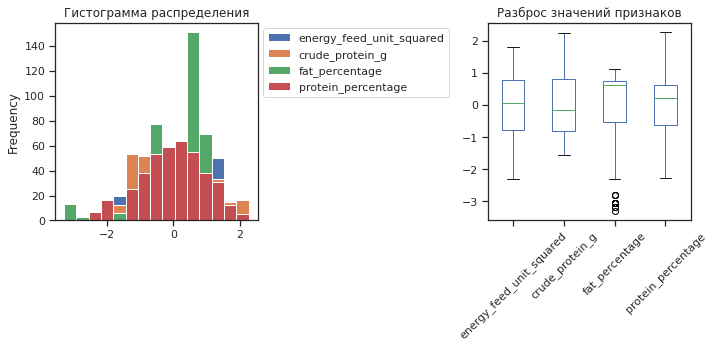

x0_низкое           : +1.023785
x1_менее_2_лет      : -0.033023
x2_холмистое        : +0.426952
x3_рефлешнсоверинг  : -0.004931
x4_соверин          : +0.165441
x5_буйный           : +0.051556
x5_геркулес         : -0.175289
x5_соловчик         : -0.352589
energy_feed_unit_squared: +0.645420
crude_protein_g     : +0.229476
fat_percentage      : +0.157808
protein_percentage  : +0.225477

      y_valid   y_proba
52         1  0.939456
90         1  0.927922
24         1  0.908789
105        1  0.875150
35         1  0.869303

accuracy:  0.615
recall:  0.803
precision:  0.622


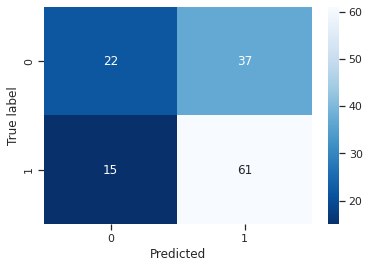

Best threshold: 0.8787878787878789
Accuracy: 0.45925925925925926
Recall: 0.039473684210526314
Precision: 1.0


,Порог,Accuracy,Precision,Recall,Количество «правильных единичек»,Количество False Positive,Количество False Negative,"Количество ""правильный нулей"""
0,y_pred_0.000,0.562963,0.562963,1.0,76,59,0,0
1,y_pred_0.010,0.562963,0.562963,1.0,76,59,0,0
2,y_pred_0.020,0.562963,0.562963,1.0,76,59,0,0
3,y_pred_0.030,0.562963,0.562963,1.0,76,59,0,0
4,y_pred_0.040,0.562963,0.562963,1.0,76,59,0,0
...,...,...,...,...,...,...,...,...
95,y_pred_0.960,0.437037,1.000000,0.0,0,0,76,59
96,y_pred_0.970,0.437037,1.000000,0.0,0,0,76,59
97,y_pred_0.980,0.437037,1.000000,0.0,0,0,76,59
98,y_pred_0.990,0.437037,1.000000,0.0,0,0,76,59


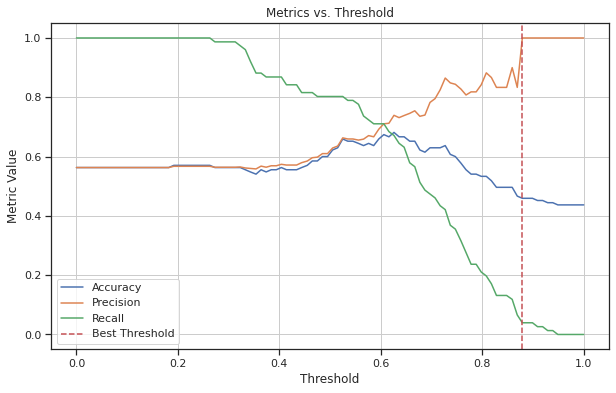

In [164]:
# Сделаем прогноз вкуса молока на реальных данных с оптимальным порогом классификации
full_logistical_model(
    data=ferma_main_log2,
    target='milk_flavor',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'fat_percentage',
        'protein_percentage',
        'age',
        'pasture_type',
        'breed',
        'dad_breed',
        'dad_name'
    ], 
)

### Выбор лучшей модели

**При стандартном пороге классификации (50%):**

*Модель 1 (базовая):*
- Accuracy:  0.631
- Recall:  0.864
- Precision:  0.623
    
*Модель 2 (без выбросов):*
- Accuracy:  0.615
- Recall:  0.803
- Precision:  0.622  

**При оптимальном пороге классификации (80.8% и 87.9%):**

*Модель 1 (базовая):*
- Accuracy:  0.4841
- Recall:  0.07955
- Precision:  1.0
    
*Модель 2 (без выбросов):*
- Accuracy:  0.4593
- Recall:  0.0395
- Precision:  1.0  


При прочих равных условиях Модель 2 справляется хуже с предсказанием вкуса молока и ее точность ниже, чем у Модели 1.

Как и было предположено ранее, выбросы скорей всего объясняются естественными причинами и не являются ошибками. Поэтому в данном случае, наличие более полных данных лучше сказывается на качестве модели.

### Прогноз вкуса молока коров "ЭкоФермы"

In [165]:
# для предсказаний вкуса молока, переименуем колонки с параметрами корма, уберем из них "current_"
cow_buy_adjusted.rename(columns=lambda x: x.replace('current_', ''), inplace=True)
cow_buy_adjusted.head()

,breed,pasture_type,dad_breed,dad_name,fat_percentage,protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,высокое,233.361138
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,высокое,233.361138
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138


In [166]:
cow_buy_adjusted.columns

Index(['breed', 'pasture_type', 'dad_breed', 'dad_name', 'fat_percentage',
       'protein_percentage', 'age', 'energy_feed_unit', 'crude_protein_g',
       'sugar_protein_ratio', 'energy_feed_unit_squared'],
      dtype='object')

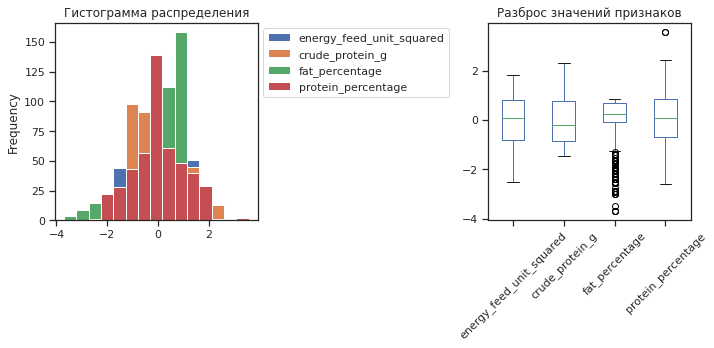

x0_низкое           : +0.717791
x1_менее_2_лет      : -0.204374
x2_холмистое        : +0.501364
x3_рефлешнсоверинг  : +0.039923
x4_соверин          : -0.037825
x5_буйный           : -0.095495
x5_геркулес         : -0.105027
x5_соловчик         : -0.424116
energy_feed_unit_squared: +0.614456
crude_protein_g     : +0.170151
fat_percentage      : -0.020444
protein_percentage  : +0.261697

      y_valid   y_proba
85         1  0.861355
110        1  0.842792
66         1  0.841488
51         1  0.839668
8          1  0.817304

accuracy:  0.631
recall:  0.864
precision:  0.623


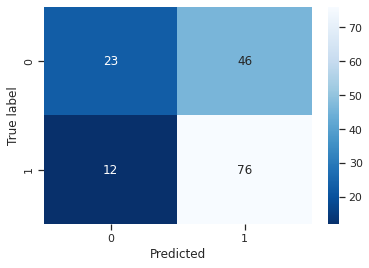

Best threshold: 0.8080808080808082
Accuracy: 0.4840764331210191
Recall: 0.07954545454545454
Precision: 1.0


,Порог,Accuracy,Precision,Recall,Количество «правильных единичек»,Количество False Positive,Количество False Negative,"Количество ""правильный нулей"""
0,y_pred_0.000,0.56051,0.56051,1.0,88,69,0,0
1,y_pred_0.010,0.56051,0.56051,1.0,88,69,0,0
2,y_pred_0.020,0.56051,0.56051,1.0,88,69,0,0
3,y_pred_0.030,0.56051,0.56051,1.0,88,69,0,0
4,y_pred_0.040,0.56051,0.56051,1.0,88,69,0,0
...,...,...,...,...,...,...,...,...
95,y_pred_0.960,0.43949,1.00000,0.0,0,0,88,69
96,y_pred_0.970,0.43949,1.00000,0.0,0,0,88,69
97,y_pred_0.980,0.43949,1.00000,0.0,0,0,88,69
98,y_pred_0.990,0.43949,1.00000,0.0,0,0,88,69


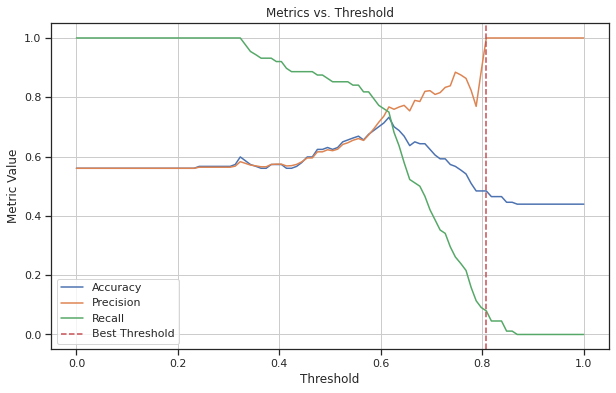

Предсказание реальных значений (Порог классификации = 0.8081):


,breed,pasture_type,dad_breed,dad_name,fat_percentage,protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared,milk_flavor_predicted
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138,0
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,высокое,233.361138,0
2,рефлешнсоверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,0
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,высокое,233.361138,0
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,0
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,0
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,высокое,233.361138,0
7,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.276162,2019.947532,высокое,233.361138,0
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,15.276162,2019.947532,высокое,233.361138,0
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,высокое,233.361138,0


In [167]:
# Сделаем прогноз вкуса молока на реальных данных с оптимальным порогом классификации
X_real, y_real, X_real_predicted, real_probabilities = full_logistical_model(
    data=ferma_main_log,
    target='milk_flavor',
    variables = [
        'energy_feed_unit_squared',
        'crude_protein_g',
        'sugar_protein_ratio',
        'fat_percentage',
        'protein_percentage',
        'age',
        'pasture_type',
        'breed',
        'dad_breed',
        'dad_name'
    ], 
    X_real=cow_buy_adjusted
    
)

In [168]:
# добавим предсказание вкуса молока в нашу сводную таблицу
cow_buy_predictions = pd.merge(cow_buy_predictions, X_real_predicted['milk_flavor_predicted'], how='left', left_index=True, right_index=True, suffixes=('_cow', '_X'))
cow_buy_predictions

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared,milk_yield_kg_predicted,milk_flavor_predicted
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,высокое,233.361138,6617.928926,0
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297,0
10,вис бик айдиал,холмистое,айдиал,геркулес,3.68,3.046,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297,0
3,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,высокое,233.361138,6593.089377,0
12,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.065,более_2_лет,15.276162,2019.947532,высокое,233.361138,6593.089377,0
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,высокое,233.361138,6571.259737,0
15,вис бик айдиал,равнинное,соверин,буйный,3.34,3.069,более_2_лет,15.276162,2019.947532,высокое,233.361138,6571.259737,0
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,6542.146066,0
5,рефлешнсоверинг,равнинное,соверин,геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6425.380218,0
14,рефлешнсоверинг,равнинное,соверин,геркулес,3.77,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6425.380218,0


Определим коров, которые соответствуют сразу двум критериям хозяйства:
- Средний удой за год — не менее 6000 килограммов,
- Молоко должно быть вкусным.

In [169]:
cow_buy_predictions.query('(milk_yield_kg_predicted >= 6000) and (milk_flavor_predicted == 1)')

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared,milk_yield_kg_predicted,milk_flavor_predicted


С учетом получившейся модели, ни одна из коров гарантированно не будет давать вкусное молоко. Тогда как удой всех коров вероятно превысит 6000 кг. 

In [170]:
real_probabilities

array([0.70802812, 0.65988158, 0.57149083, 0.3633716 , 0.5557968 ,
       0.10416201, 0.65949201, 0.74205251, 0.16590165, 0.51611719,
       0.10314161, 0.66085542, 0.46109975, 0.69298422, 0.10256724,
       0.41999125])

In [171]:
# каждой корове в таблице добавим вероятность получения вкусного молока.
cow_buy_predictions['good_milk_flavor_proba'] = real_probabilities
cow_buy_predictions.sort_values(by='good_milk_flavor_proba', ascending=False, inplace=True)
cow_buy_predictions

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,energy_feed_unit,crude_protein_g,sugar_protein_ratio,energy_feed_unit_squared,milk_yield_kg_predicted,milk_flavor_predicted,good_milk_flavor_proba
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,высокое,233.361138,6542.146066,0,0.742053
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.276162,2019.947532,высокое,233.361138,6617.928926,0,0.708028
13,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.079,более_2_лет,15.276162,2019.947532,высокое,233.361138,6344.707860,0,0.692984
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6378.711028,0,0.660855
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297,0,0.659882
15,вис бик айдиал,равнинное,соверин,буйный,3.34,3.069,более_2_лет,15.276162,2019.947532,высокое,233.361138,6571.259737,0,0.659492
10,вис бик айдиал,холмистое,айдиал,геркулес,3.68,3.046,более_2_лет,15.276162,2019.947532,высокое,233.361138,6609.919297,0,0.571491
12,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.065,более_2_лет,15.276162,2019.947532,высокое,233.361138,6593.089377,0,0.555797
14,рефлешнсоверинг,равнинное,соверин,геркулес,3.77,3.053,менее_2_лет,15.276162,2019.947532,высокое,233.361138,6425.380218,0,0.516117
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,15.276162,2019.947532,высокое,233.361138,6344.707860,0,0.461100


Для принятия дальнейших решения о покупке, мы добавили в таблицу вероятности того, что корова будет давать вкусное молоко.

Одна важно учитывать, что ни одна из коров не будет гарантированно давать вкусное молоко, а при снижении порога классификации - становится возможен ложноположительный результат.

### Выводы

Из результатов прогноза вкуса молока коров можно сделать следующие выводы:

**1. Определение входящих факторов для прогноза вкуса молока:**

Для построения моделей логистической регрессии были определены следующие входные параметры, имеющие логическую связь со вкусом молока коровы:
- age ("Возраст")
- energy_feed_unit ("ЭКЕ (Энергетическая кормовая единица)").
- crude_protein_g ("Сырой протеин, г")
- sugar_protein_ratio ("СПО (Сахаро-протеиновое соотношение)")
- pasture_type ("Тип пастбища")
- fat_percentage ("Жирность,%")
- protein_percentage ("Белок,%")

**2. Подготовка данных и построение модели:**

- Данные были разделены на обучающую и тестовую выборки.
- К ним была применена нормализация категориальных признаков с помощью One-Hot Encoding и масштабирование количественных признаков с помощью StandardScaler.
- Была создана и обучена базовая модель логистической регрессии на основе подготовленного файла, для обучения лучшей модели линейной регресси (с устраненной нелинейсность факторов) - ferma_main_v3. В данном файле значения целевой переменной были заменены на булев тип (1 - "вкусно", 0 - "не вкусно")
- Качество базовой модели (при стандартном пороге классификации 50%):
 - Точность модели (Accuracy): 0.631 означает, что модель правильно классифицировала 63.1% всех объектов.
 - Точность (Precision): 0.623 означает, что 62.3% объектов, отнесенных моделью к классу "вкусного" молока, действительно имеют хороший вкус.
 - Полнота (Recall): 0.864 означает, что модель правильно определила 86.4% коров, имеющих действительно вкусное молоко.

**3. Калибровка и выбор лучшей модели:**

В ходе анализа были построены 2 модели логистической регрессии:
 - Модель 1 (базовая): построена на основании исходных данных в таблице ferma_main_log.
 - Модель 2 (без выбросов): Для улучшения качества модели были удалены ранее обнаруженные выбросы в значениях `fat_percentage` и `protein_percentage`.  
 
Параметры и качество полученных моделей логистической регрессии представлены в таблице ниже:

| Параметры модели | **Модель 1** | Модель 2 |
| :--- | :--- | :--- |
| Данные | **ferma_main_log** | ferma_main_log2 |
| Целевая переменная | **milk_flavor** | milk_flavor |
| Переменные | **energy_feed_unit_squared, crude_protein_g, sugar_protein_ratio, fat_percentage, protein_percentage, age, pasture_type, breed, dad_breed, dad_name** | energy_feed_unit_squared, crude_protein_g, sugar_protein_ratio, fat_percentage (без выбросов), protein_percentage (без выбросов), age, pasture_type, breed, dad_breed, dad_name |
| x0_низкое                | **+0.717791**    | +1.023785   |
| x1_менее_2_лет           | **-0.204374**    | -0.033023   |
| x2_холмистое             | **+0.501364**    | +0.426952   |
| x3_рефлешнсоверинг       | **+0.039923**    | -0.004931   |
| x4_соверин               | **-0.037825**    | +0.165441   |
| x5_буйный                | **-0.095495**    | +0.051556   |
| x5_геркулес              | **-0.105027**    | -0.175289   |
| x5_соловчик              | **-0.424116**    | -0.352589   |
| energy_feed_unit_squared | **+0.614456**    | +0.645420   |
| crude_protein_g          | **+0.170151**    | +0.229476   |
| fat_percentage           | **-0.020444**    | +0.157808   |
| protein_percentage       | **+0.261697**    | +0.225477   |
| Оптимальный порог классификации | **0.81** | 0.88 |
| Accuracy | **0.48** | 0.46 |
| Recall | **0.08** | 0.04 |
| Precision | **1.00** | 1.00 |


- Модель 1 была выбрана как лучшая, так как она обладает более высокими метриками по сравнению с Моделью 2. 
- Для улучшения модели и минимизации ложноположительных ошибок мы провели калибровку, оптимизируя показатель Precision. Максимальное значение Precision достигается при минимальном пороге вероятности 80.81%. Это гарантирует, что если модель предсказывает вкусное молоко, то с высокой вероятностью это действительно так.
- После калибровки общий показатель Accuracy модели снизился до 48.4%, но Precision достигает максимального значения, что важно для гарантированного выбора коровы с вкусным молоком. Recall снизился до 7.95%, но в данном контексте это не является критическим, так как главная цель - выбрать корову с вкусным молоком и минимизировать ложноположительные прогнозы. Если модель не найдет достаточно коров с вкусным молоком, вероятно придется снижать порог классификации, однако это может увеличить вероятность ложноположительной ошибки прогноза.

**4. Прогноз вкуса молока коров "Экофермы":**
- Для предсказаний вкуса молока использовались колонки с текущими параметрами молока на "ЭкоФерме". Для корректной работы Модели 1 из названия колонок была убрана приписка "current_".
- В результате прогноза, не удалось  определить ни одной коровы, которая бы гарантированно имела вкусное молоко.

## Итоговые выводы

На основании проведенного исследования были получены следующие прогнозные значения Удоя и Вкуса молока в отношении коров из хозяйства "ЭкоФерма":

In [172]:
cow_buy_result = pd.merge(cow_buy, cow_buy_predictions[['milk_yield_kg_predicted', 'milk_flavor_predicted', 'good_milk_flavor_proba']], how='left', left_index=True, right_index=True)
cow_buy_result.sort_values(by='good_milk_flavor_proba', ascending=False)

,breed,pasture_type,dad_breed,dad_name,current_fat_percentage,current_protein_percentage,age,milk_yield_kg_predicted,milk_flavor_predicted,good_milk_flavor_proba
4,рефлешнсоверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,6542.146066,0,0.742053
9,рефлешнсоверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,6617.928926,0,0.708028
13,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.079,более_2_лет,6344.707860,0,0.692984
1,вис бик айдиал,равнинное,соверин,буйный,3.54,3.081,менее_2_лет,6378.711028,0,0.660855
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,6609.919297,0,0.659882
15,вис бик айдиал,равнинное,соверин,буйный,3.34,3.069,более_2_лет,6571.259737,0,0.659492
10,вис бик айдиал,холмистое,айдиал,геркулес,3.68,3.046,более_2_лет,6609.919297,0,0.571491
12,рефлешнсоверинг,холмистое,айдиал,буйный,3.40,3.065,более_2_лет,6593.089377,0,0.555797
14,рефлешнсоверинг,равнинное,соверин,геркулес,3.77,3.053,менее_2_лет,6425.380218,0,0.516117
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,6344.707860,0,0.461100


Согласно техническому заданию, коровы должны соответствовать следующим критериям:

- Средний удой за год — не менее 6000 килограммов,
- Молоко должно быть вкусным.

При условии минимального риска допустить ошибку одновременно обоим критериям не соответствует ни одна корова.

**Рекомендации хозяйству "Вольный луг"**

- Качество получившейся модели предсказания вкуса молока недостаточно высокое, т.к. в исходных данных, вероятно, не хватает признаков, которые объясняли бы вкус и позволили бы гарантированно определить коров, дающих вкусное молоко. Рекомендуется добавить новые объясняющие признаки в модель с целью улучшения качества предсказаний.
- Если данных добавить дополнительные данные не представляется возможным, в таблицу для каждой коровы были добавлены предсказанные вероятности того, что она будет давать вкусное молоко. Однако важно понимать, что при выборе любой коровы (даже с самой высокой вероятностью вкусного молока) модель не гарантирует, что ее молоко будет вкусным - есть ненулевая вероятность ложноположительного результата.
- Для совершения оптимальной покупки рекомендуется  учитывать стоимость доступных для покупки коров, а также спрос на их молоко. Несмотря на то, что молодые коровы реже дают вкусное молоко и их удой меньше чем у взрослых коров, возможно такая покупка окажется более выгодной, учитывая быстрое взросление коров. Возможно адаптировать текущую мождель под новые требования.
- Исходя их коэффициентов обученных моделей следует:
 - Чтобы улучшить вкус молока коровы, рекомендуется уделить особое внимание следующим параметрам: 
     - ЭКЕ (высокое содержание ЭКЕ существенно улучшает вкус), 
     - СПО (молоко с низким значением СПО как правило вкусней) 
     - Тип пастбища (холмистая местость положительно влияет на вкус).
     - Имя отца коровы (если имя отца "соловчик" это сильно ухудшает вкус молока)
 - Чтобы увеличить удой, рекомендуется уделить особое внимание следующим параметрам: 
     - СПО (чем больше СПО, тем больше удой коровы)
     - Имя отца коровы (если имя отца "буйный" или "геркулес" это дает существенную прибавку к Удою потомка)
     - ЭКЕ (чем выше ЭКЕ, тем больше удой).
     - Возраст (взрослые коровы дают больше молока).